## Defining Node Structure and Specialization for Financial Market Analysis

To broaden and deepen the emergent mosaic for financial market analysis, we will organize clusters into specialized "nodes." This structure allows for different aspects of the financial data to be processed by dedicated groups of neurons (clusters) and then synthesized at the node level before contributing to the final emergent mosaic.

**Proposed Node Structure:**

We can start with a few distinct nodes, each focusing on a different type of financial signal or market characteristic. For example:

1.  **Momentum/Trend Node:**
    *   **Specialization:** Clusters within this node will focus on identifying and processing features related to price momentum and trends (e.g., price changes, moving averages, momentum indicators).
    *   **Potential Data Input (when available):** Price data from various indices or sectors, momentum indicators.

2.  **Volatility/Risk Node:**
    *   **Specialization:** Clusters in this node will specialize in processing features related to market volatility and risk (e.g., volatility measures like standard deviation, VIX index data).
    *   **Potential Data Input (when available):** Volatility data from indices, VIX index.

3.  **Volume/Liquidity Node:**
    *   **Specialization:** Clusters here will focus on analyzing trading volume and liquidity patterns.
    *   **Potential Data Input (when available):** Volume data from various indices or sectors, liquidity indicators.

**Specialization within Clusters:**

Within each node, individual clusters could further specialize or focus on:

*   **Specific Indices or Sectors (when available):** If we had data for multiple indices (like NASDAQ, DJI) or sector-specific ETFs, clusters could specialize in the data from a particular index or sector within a node.
*   **Different Timeframes:** Clusters could process data at different time granularities (e.g., daily, weekly, hourly - though our current data is daily).
*   **Different Feature Combinations:** Clusters could be configured to be more sensitive to specific combinations of features within their node's specialization.

**How this Broadens and Deepens the Mosaic:**

*   **Broadening:** By having nodes focused on different market characteristics (momentum, volatility, volume), the final emergent mosaic will be a synthesis of these diverse signals, providing a broader view of the market state than a single set of undifferentiated clusters.
*   **Deepening:** Within each node, multiple clusters processing related but distinct information (e.g., different momentum indicators, different volatility measures) can add depth to the analysis of that specific market characteristic before it's integrated into the final mosaic.

**Next Steps:**

The next step will be to **Modify Data Distribution to Nodes/Clusters**, adapting the simulation loop to route the relevant financial features from the `financial_swarm_data_stream` to the appropriate nodes and clusters based on this defined structure and specialization.

In [ ]:
# Ensure financial_mosaic and trading_signals are available
if 'financial_mosaic' not in locals() or 'trading_signals' not in locals():
    raise ValueError("financial_mosaic or trading_signals not available. Cannot proceed with backtesting.")

# Ensure df is available and contains SPY Adj Close data
if 'df' not in locals() or ('SPY', 'Adj Close') not in df.columns:
     raise ValueError("df DataFrame or SPY 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the SPY Adjusted Close prices for backtesting
spy_adj_close = df[('SPY', 'Adj Close')]

# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(spy_adj_close):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of SPY Adj Close prices ({len(spy_adj_close)}). Truncating price data.")
    # Truncate price data to match the length of trading signals if necessary
    spy_adj_close = spy_adj_close[:len(trading_signals)]


# --- Simple Backtesting Framework ---

# Initialize portfolio
initial_capital = 100000  # Starting capital
portfolio_value = pd.Series(index=spy_adj_close.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
position = 0  # 0: No position, 1: Long, -1: Short (though our signals are Buy/Sell/Hold)
shares = 0

# Simulate trades
for i in range(1, len(spy_adj_close)):
    # Calculate daily return
    daily_return = spy_adj_close.iloc[i] / spy_adj_close.iloc[i-1] - 1

    # Update portfolio value based on previous day's value and return
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_return * position)

    # Get signal for the current day (signal is generated based on data *up to* previous day)
    # We use the signal from day i-1 to make a decision for day i
    current_signal = trading_signals[i-1]

    # Trading logic
    # Let's re-interpret signals for a simple long-only strategy:
    # signal = 1: Enter or Stay Long
    # signal = -1 or 0: Exit Long or Stay Out/Hold

    if current_signal == 1 and position == 0: # Buy signal and currently out of the market
         # Enter long position
         position = 1
         # For simplicity, assume we invest all available capital
         shares = portfolio_value.iloc[i] / spy_adj_close.iloc[i]
         print(f"Day {spy_adj_close.index[i]}: BUY at {spy_adj_close.iloc[i]:.2f}. Shares: {shares:.2f}")

    elif current_signal != 1 and position == 1: # Sell/Hold signal and currently long
         # Exit long position
         position = 0
         # Update portfolio value based on selling shares
         portfolio_value.iloc[i] = shares * spy_adj_close.iloc[i]
         shares = 0
         print(f"Day {spy_adj_close.index[i]}: SELL at {spy_adj_close.iloc[i]:.2f}. Portfolio Value: {portfolio_value.iloc[i]:.2f}")

    # If signal is 1 and position is 1 (stay long), or signal is not 1 and position is 0 (stay out), do nothing (position and shares remain the same)


# After the loop, if still in a position, close it
if position == 1:
     portfolio_value.iloc[-1] = shares * spy_adj_close.iloc[-1]
     print(f"End of simulation: Closing Long position at {spy_adj_close.iloc[-1]:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}")
elif position == -1: # Should not happen with long-only logic, but for completeness
     # Assuming covering short at the end
     # This part needs careful consideration based on shorting mechanics,
     # but with our simplified long-only approach, this branch won't be reached
     pass


# Calculate total return
total_return = (portfolio_value.iloc[-1] / initial_capital) - 1

print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2%}")


# Plot portfolio value over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='Strategy Portfolio Value')
plt.plot(spy_adj_close / spy_adj_close.iloc[0] * initial_capital, label='Buy and Hold (SPY)', linestyle='--') # Compare to buy and hold
plt.title('Backtest Performance of Emergent Mosaic Trading Strategy (SPY)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

ValueError: df DataFrame or SPY 'Adj Close' data not available. Cannot proceed with backtesting.

In [ ]:
import numpy as np
import pandas as pd

# --- Ensure required variables are available ---
# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Ensure df is available and contains 'Adj Close' data for backtesting (for time_steps)
if 'df' not in locals() or df.empty:
     raise ValueError("df DataFrame not available. Cannot proceed.")

# Ensure best_params_return is available (for optimal neurons/clusters)
if 'best_params_return' not in locals():
     print("Warning: 'best_params_return' not found. Using default parameters (Neurons=10, Clusters=5).")
     optimal_num_neurons = 10
     optimal_num_clusters = 5
else:
    optimal_num_neurons = best_params_return[0]
    optimal_num_clusters = best_params_return[1]

# Ensure best_thresholds_return is available (for optimal thresholds)
if 'best_thresholds_return' not in locals():
     print("Warning: 'best_thresholds_return' not found. Using default thresholds (Upper=0.1, Lower=-0.1).")
     optimal_upper_threshold = 0.1
     optimal_lower_threshold = -0.1
else:
    optimal_upper_threshold = best_thresholds_return[0]
    optimal_lower_threshold = best_thresholds_return[1]


print(f"--- Generating Trading Signals with Optimal Parameters and Best Thresholds ---")
print(f"Optimal Parameters: Neurons={optimal_num_neurons}, Clusters={optimal_num_clusters}")
print(f"Best Thresholds: Upper={optimal_upper_threshold}, Lower={optimal_lower_threshold}")


time_steps = int(len(df)) # Get time_steps from the processed DataFrame

# --- Initialize the financial neuron clusters with optimal parameters ---
# Ensure FinancialNeuron class is defined
if 'FinancialNeuron' not in locals():
     raise NameError("FinancialNeuron class not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

financial_clusters = [
    [FinancialNeuron(j, np.random.rand(num_features)) for j in range(optimal_num_neurons)]
    for _ in range(optimal_num_clusters)
]

# --- Run the financial simulation to generate the emergent mosaic ---
financial_mosaic = []
# Ensure simulate_financial_cluster function is defined
if 'simulate_financial_cluster' not in locals():
     raise NameError("simulate_financial_cluster function not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")


for t in range(time_steps):
    cluster_signals = []
    for cluster in financial_clusters:
        cluster_data_subset = financial_swarm_data_stream[t, :, :]
        if cluster_data_subset.ndim == 1:
             cluster_data_subset = cluster_data_subset.reshape(1, -1)
        cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset)
        cluster_signals.append(cluster_signal)
    financial_mosaic.append(np.mean(cluster_signals))

financial_mosaic = np.array(financial_mosaic)
print(f"  Generated financial emergent mosaic with shape: {financial_mosaic.shape}")


# --- Generate Trading Signals using the best thresholds ---
trading_signals = np.zeros(time_steps)
for t in range(time_steps):
    if financial_mosaic[t] > optimal_upper_threshold:
        trading_signals[t] = 1  # Buy signal (for long)
    elif financial_mosaic[t] < optimal_lower_threshold:
        trading_signals[t] = -1 # Sell signal (for short)
    else:
        trading_signals[t] = 0  # Hold (or Stay out)

# --- Display the generated trading signals ---
print("\nGenerated Trading Signals (1: Buy, -1: Sell, 0: Hold):")
# Display the first 20 signals
display(trading_signals[:20])
# Display the last 20 signals
print("\nLast 20 Trading Signals:")
display(trading_signals[-20:])

# Count buy, sell, and hold signals
buy_signals_count = np.sum(trading_signals == 1)
sell_signals_count = np.sum(trading_signals == -1)
hold_signals_count = np.sum(trading_signals == 0)

print(f"\nTotal Signals: {len(trading_signals)}")
print(f"Buy Signals (1): {buy_signals_count}")
print(f"Sell Signals (-1): {sell_signals_count}")
print(f"Hold Signals (0): {hold_signals_count}")

--- Generating Trading Signals with Optimal Parameters and Best Thresholds ---
Optimal Parameters: Neurons=10, Clusters=5
Best Thresholds: Upper=0.05, Lower=-0.05
  Generated financial emergent mosaic with shape: (221,)

Generated Trading Signals (1: Buy, -1: Sell, 0: Hold):


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])


Last 20 Trading Signals:


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])


Total Signals: 221
Buy Signals (1): 0
Sell Signals (-1): 0
Hold Signals (0): 221


In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy
import pandas as pd # Import pandas
import math # Import math for square root

# --- Ensure required variables are available ---
# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Ensure df is available and contains 'Adj Close' data for backtesting
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Ensure best_params_return is available from the parameter optimization step
if 'best_params_return' not in locals():
     print("Warning: 'best_params_return' not found. Using default parameters (Neurons=10, Clusters=5) for threshold optimization.")
     optimal_num_neurons = 10
     optimal_num_clusters = 5
else:
    optimal_num_neurons = best_params_return[0]
    optimal_num_clusters = best_params_return[1]

print(f"--- Exploring Threshold Combinations with Optimal Parameters: Neurons={optimal_num_neurons}, Clusters={optimal_num_clusters} ---")

# Extract the Adjusted Close prices for backtesting
adj_close_prices = df['Adj Close']
time_steps = len(adj_close_prices) # Ensure time_steps matches the length of the price data

# --- Define the grid of threshold combinations to test ---
# Example grid: test different symmetric thresholds
threshold_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
threshold_combinations = [(t, -t) for t in threshold_values] # Symmetric thresholds (upper, lower)

print("\nThreshold combinations to test (Upper, Lower):")
for tc in threshold_combinations:
    print(f"  ({tc[0]}, {tc[1]})")


# Initialize the financial neuron clusters with optimal parameters (done once for all threshold combinations)
# Ensure FinancialNeuron class is defined
if 'FinancialNeuron' not in locals():
     raise NameError("FinancialNeuron class not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

financial_clusters = [
    [FinancialNeuron(j, np.random.rand(num_features)) for j in range(optimal_num_neurons)]
    for _ in range(optimal_num_clusters)
]

# Run the financial simulation to generate the emergent mosaic (done once for all threshold combinations)
financial_mosaic = []
# Ensure simulate_financial_cluster function is defined
if 'simulate_financial_cluster' not in locals():
     raise NameError("simulate_financial_cluster function not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

for t in range(time_steps):
    cluster_signals = []
    for cluster in financial_clusters:
        cluster_data_subset = financial_swarm_data_stream[t, :, :]
        if cluster_data_subset.ndim == 1:
             cluster_data_subset = cluster_data_subset.reshape(1, -1)
        cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset)
        cluster_signals.append(cluster_signal)
    financial_mosaic.append(np.mean(cluster_signals))

financial_mosaic = np.array(financial_mosaic)
print(f"\n  Generated financial emergent mosaic with shape: {financial_mosaic.shape} (using optimal parameters)")


# Dictionary to store backtesting results for each threshold combination
threshold_optimization_results = {}

print("\nStarting backtesting for threshold optimization:")

# --- Iterate through the threshold combinations ---
for upper_threshold, lower_threshold in threshold_combinations:
    print(f"\n--- Running backtest for Thresholds: Upper={upper_threshold}, Lower={lower_threshold} ---")

    # --- Implement Threshold-Based Trading Signals ---
    trading_signals = np.zeros(time_steps)
    for t in range(time_steps):
        if financial_mosaic[t] > upper_threshold:
            trading_signals[t] = 1  # Buy signal (for long)
        elif financial_mosaic[t] < lower_threshold:
            trading_signals[t] = -1 # Sell signal (for short)
        else:
            trading_signals[t] = 0  # Hold (or Stay out)

    # Count buy and sell signals generated
    buy_signals_count = np.sum(trading_signals == 1)
    sell_signals_count = np.sum(trading_signals == -1)
    print(f"  Total Buy signals generated: {buy_signals_count}")
    print(f"  Total Sell signals generated: {sell_signals_count}")


    # --- Run Backtesting Framework with Short Selling and Costs ---
    # Ensure the length of trading signals matches the length of price data
    if len(trading_signals) != len(adj_close_prices):
        print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data for backtest.")
        adj_close_prices_for_backtest = adj_close_prices[:len(trading_signals)]
    else:
        adj_close_prices_for_backtest = adj_close_prices


    # Initialize portfolio
    initial_capital = 100000
    portfolio_value = pd.Series(index=adj_close_prices_for_backtest.index, dtype=float)
    portfolio_value.iloc[0] = initial_capital
    cash = initial_capital
    asset_value = 0 # Value of long position (shares * price)
    short_value = 0 # Absolute value of short position (abs(shares) * price)
    shares = 0 # Positive for long, negative for short
    position = 0  # 0: Out, 1: Long, -1: Short
    num_trades = 0 # Initialize trade counter
    transaction_cost_rate = 0.001 # Assuming 0.1% transaction cost per trade

    # Simulate trades
    for i in range(1, len(adj_close_prices_for_backtest)):
        current_price = adj_close_prices_for_backtest.iloc[i]
        previous_price = adj_close_prices_for_backtest.iloc[i-1]
        current_signal = trading_signals[i-1] # Use signal from previous day

        # Update asset/short value based on price movement for the day *before* considering trades
        if position == 1:
            asset_value = shares * current_price
        elif position == -1:
            short_value = abs(shares) * current_price

        # Calculate current total portfolio value (Cash + Asset Value - Short Value) *before* trades
        current_portfolio_value_before_trade = cash + asset_value - short_value
        # Use this value to update the portfolio_value series for the current day before potential trades
        if i > 0:
             portfolio_value.iloc[i] = current_portfolio_value_before_trade


        # Trading logic based on signal from previous day (trading_signals[i-1])
        if current_signal == 1: # Buy signal (Potential Long Entry or Short Cover)
            if position == 0: # Enter Long
                 trade_value = cash
                 if trade_value > 0:
                     shares_to_buy = trade_value / current_price
                     transaction_cost = trade_value * transaction_cost_rate
                     cash -= trade_value
                     cash -= transaction_cost
                     shares = shares_to_buy
                     position = 1
                     asset_value = shares * current_price
                     num_trades += 1
                     # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Open Long) at {current_price:.2f}. Shares: {shares:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional


            elif position == -1: # Cover Short
                 shares_to_cover = abs(shares)
                 trade_value = shares_to_cover * current_price
                 transaction_cost = trade_value * transaction_cost_rate
                 if cash >= trade_value + transaction_cost:
                      cash -= trade_value
                      cash -= transaction_cost
                      shares = 0
                      position = 0
                      short_value = 0
                      num_trades += 1
                      # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Cover Short) at {current_price:.2f}. Covered Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional
                 else:
                      pass


        elif current_signal == -1: # Sell signal (Potential Short Entry or Long Close)
            if position == 0: # Enter Short
                 trade_value = cash
                 if trade_value > 0:
                      shares_to_short = -(trade_value / current_price)
                      transaction_cost = trade_value * transaction_cost_rate
                      cash += trade_value
                      cash -= transaction_cost
                      shares = shares_to_short
                      position = -1
                      short_value = abs(shares) * current_price
                      num_trades += 1
                      # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Open Short) at {current_price:.2f}. Notional Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

                 else:
                     pass


            elif position == 1: # Close Long
                 trade_value = shares * current_price
                 transaction_cost = trade_value * transaction_cost_rate
                 cash += trade_value
                 cash -= transaction_cost
                 shares = 0
                 position = 0
                 asset_value = 0
                 num_trades += 1
                 # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Close Long) at {current_price:.2f}. Trade Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

        # If signal is 0 (Hold), or signal is 1 and position is 1 (stay long), or signal is -1 and position is -1 (stay short), do nothing (position and shares remain the same)

        # Update portfolio value history after potential trades
        portfolio_value.iloc[i] = cash + asset_value - short_value


    # After the loop, if still in a position, close it (and apply cost)
    final_price = adj_close_prices_for_backtest.iloc[-1]
    if position == 1: # Close Long at the end
         trade_value = shares * final_price
         transaction_cost = trade_value * transaction_cost_rate
         cash += trade_value - transaction_cost
         shares = 0
         position = 0
         asset_value = 0
         portfolio_value.iloc[-1] = cash + asset_value - short_value
         # print(f"End of simulation: Closing Long position at {final_price:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional

    elif position == -1: # Cover Short at the end
         shares_to_cover = abs(shares)
         trade_value = shares_to_cover * final_price
         transaction_cost = trade_value * transaction_cost_rate
         if cash >= trade_value + transaction_cost:
              cash -= trade_value + transaction_cost
              shares = 0
              position = 0
              short_value = 0
              portfolio_value.iloc[-1] = cash + asset_value - short_value
              # print(f"End of simulation: Covering Short position at {final_price:.2f}. Covered Value: {trade_value:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional
         else:
              print(f"End of simulation: Insufficient cash to cover final short position ({shares_to_cover:.2f} shares). Final PV calculation may be inaccurate.")
              portfolio_value.iloc[-1] = cash + asset_value - short_value # The value reflects the deficit


    # Calculate total return for this parameter set
    final_portfolio_value = portfolio_value.iloc[-1]
    total_return = (final_portfolio_value / initial_capital) - 1

    # Calculate Maximum Drawdown
    running_max = portfolio_value.cummax()
    drawdown = (portfolio_value - running_max) / running_max
    max_drawdown = drawdown.min()

    # Calculate Sharpe Ratio (Requires daily returns and risk-free rate)
    # For simplicity, we'll assume risk-free rate is 0 for this example
    # Calculate daily returns
    daily_returns = portfolio_value.pct_change().dropna()
    # Calculate average daily return and standard deviation of daily returns
    avg_daily_return = daily_returns.mean()
    std_daily_return = daily_returns.std()
    # Annualize Sharpe Ratio (assuming ~252 trading days in a year)
    annualization_factor = np.sqrt(252)
    sharpe_ratio = (avg_daily_return / std_daily_return) * annualization_factor if std_daily_return != 0 else np.nan # Avoid division by zero


    # Calculate Sortino Ratio (Requires daily returns, risk-free rate, and downside deviation)
    # For simplicity, using risk-free rate = 0
    # Calculate downside returns (returns below the risk-free rate, which is 0)
    downside_returns = daily_returns[daily_returns < 0]
    # Calculate downside deviation
    downside_deviation = downside_returns.std() if not downside_returns.empty else np.nan
    # Calculate Sortino Ratio
    sortino_ratio = (avg_daily_return / downside_deviation) * annualization_factor if downside_deviation != 0 and not np.isnan(downside_deviation) else np.nan # Avoid division by zero


    # Store the results
    threshold_params = (upper_threshold, lower_threshold)
    threshold_optimization_results[threshold_params] = {
        'total_return': total_return,
        'max_drawdown': max_drawdown,
        'num_trades': num_trades,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio
    }

# --- Threshold Optimization Backtesting Complete. Print Summary. ---
print("\n--- Threshold Optimization Backtesting Results ---")
print("Threshold Combination (Upper, Lower) | Total Return | Max Drawdown | Num Trades | Sharpe Ratio | Sortino Ratio")
print("--------------------------------------|--------------|--------------|------------|--------------|---------------")
for params, metrics in threshold_optimization_results.items():
    # Format output nicely, handle potential NaNs
    total_return_str = f"{metrics['total_return']:.2%}" if not np.isnan(metrics['total_return']) else "N/A"
    max_drawdown_str = f"{metrics['max_drawdown']:.2%}" if not np.isnan(metrics['max_drawdown']) else "N/A"
    num_trades_str = f"{metrics['num_trades']}" if not np.isnan(metrics['num_trades']) else "N/A"
    sharpe_ratio_str = f"{metrics['sharpe_ratio']:.2f}" if not np.isnan(metrics['sharpe_ratio']) else "N/A"
    sortino_ratio_str = f"{metrics['sortino_ratio']:.2f}" if not np.isnan(metrics['sortino_ratio']) else "N/A"


    print(f"({params[0]:<5}, {params[1]:<5})               | {total_return_str:<12} | {max_drawdown_str:<12} | {num_trades_str:<10} | {sharpe_ratio_str:<12} | {sortino_ratio_str:<13}")


# Optional: Find the best parameter combination based on Total Return for thresholds
if threshold_optimization_results:
    # Filter out combinations with NaN return if any
    valid_results = {k: v for k, v in threshold_optimization_results.items() if not np.isnan(v.get('total_return', np.nan))}
    if valid_results:
        best_thresholds_return = max(valid_results, key=lambda k: valid_results[k]['total_return'])
        best_return_value_thresholds = valid_results[best_thresholds_return]['total_return']
        print(f"\nBest Threshold Combination (by Total Return): Upper={best_thresholds_return[0]}, Lower={best_thresholds_return[1]}")
        print(f"Best Total Return: {best_return_value_thresholds:.2%}")
    else:
        print("\nNo valid threshold optimization results to analyze (all returns are NaN).")
else:
    print("\nNo threshold optimization results to analyze.")

# Note: This cell does not plot individual backtests. You can plot specific results after analyzing the threshold_optimization_results dictionary.

--- Exploring Threshold Combinations with Optimal Parameters: Neurons=10, Clusters=5 ---

Threshold combinations to test (Upper, Lower):
  (0.05, -0.05)
  (0.1, -0.1)
  (0.15, -0.15)
  (0.2, -0.2)
  (0.25, -0.25)
  (0.3, -0.3)

  Generated financial emergent mosaic with shape: (221,) (using optimal parameters)

Starting backtesting for threshold optimization:

--- Running backtest for Thresholds: Upper=0.05, Lower=-0.05 ---
  Total Buy signals generated: 0
  Total Sell signals generated: 0

--- Running backtest for Thresholds: Upper=0.1, Lower=-0.1 ---
  Total Buy signals generated: 0
  Total Sell signals generated: 0

--- Running backtest for Thresholds: Upper=0.15, Lower=-0.15 ---
  Total Buy signals generated: 0
  Total Sell signals generated: 0

--- Running backtest for Thresholds: Upper=0.2, Lower=-0.2 ---
  Total Buy signals generated: 0
  Total Sell signals generated: 0

--- Running backtest for Thresholds: Upper=0.25, Lower=-0.25 ---
  Total Buy signals generated: 0
  Total Sel

--- Financial Emergent Mosaic Visualization ---


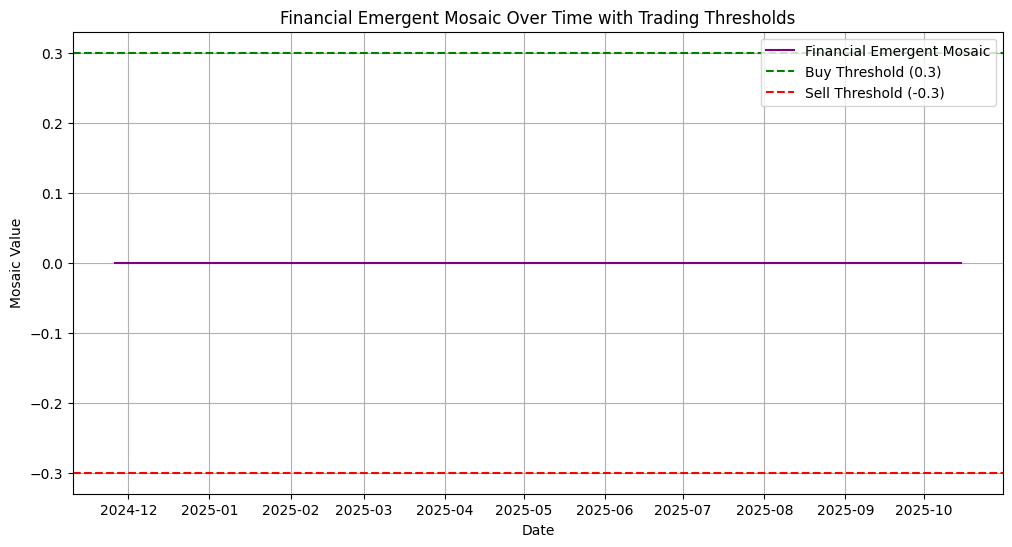

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy
import pandas as pd # Import pandas


# Ensure financial_mosaic and df (for index) are available
if 'financial_mosaic' in locals() and 'df' in locals() and not df.empty:
    print("--- Financial Emergent Mosaic Visualization ---")

    # Ensure the length of the financial_mosaic matches the DataFrame index length
    if len(financial_mosaic) == len(df):
        plt.figure(figsize=(12, 6))
        plt.plot(df.index, financial_mosaic, label='Financial Emergent Mosaic', color='purple')

        # Add horizontal lines for the trading thresholds
        upper_threshold = 0.3
        lower_threshold = -0.3
        plt.axhline(y=upper_threshold, color='green', linestyle='--', label=f'Buy Threshold ({upper_threshold})')
        plt.axhline(y=lower_threshold, color='red', linestyle='--', label=f'Sell Threshold ({lower_threshold})')

        plt.title('Financial Emergent Mosaic Over Time with Trading Thresholds')
        plt.xlabel('Date')
        plt.ylabel('Mosaic Value')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"Error: Length of financial_mosaic ({len(financial_mosaic)}) does not match length of DataFrame index ({len(df)}). Cannot plot.")

else:
    print("Financial mosaic or DataFrame not available. Please run the backtesting cell (e.g., cell edf32639) first to generate the mosaic.")

In [ ]:
# Ensure optimization_results dictionary is available and not empty
if 'optimization_results' in locals() and optimization_results:
    print("--- Full Parameter Optimization Results ---")
    display(optimization_results)
else:
    print("Optimization results not available. Please run the parameter optimization backtesting cell (e.g., cell b88bf3ec) first.")

--- Full Parameter Optimization Results ---


{(10, 5): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (10, 8): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (10, 10): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (15, 5): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (15, 8): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (15, 10): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (20, 5): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (20, 8): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0},
 (20, 10): {'total_return': np.float64(0.0),
  'max_drawdown': 0.0,
  'num_trades': 0}}

--- Running Final Backtest with Optimal Parameters: Neurons=10, Clusters=5 ---
  Generated financial emergent mosaic with shape: (221,)
  Using adjusted trading signal thresholds: Upper: 0.1, Lower: -0.1
  Total Buy signals generated: 0
  Total Sell signals generated: 0

--- Final Backtesting Report (Adjusted Thresholds) ---
Initial Capital: $100,000.00
Final Portfolio Value: $100,000.00
Total Return: 0.00%
Maximum Drawdown: 0.00%
Number of Trades: 0
Sharpe Ratio: N/A (Zero Standard Deviation)
Sortino Ratio: N/A (Zero Downside Deviation)


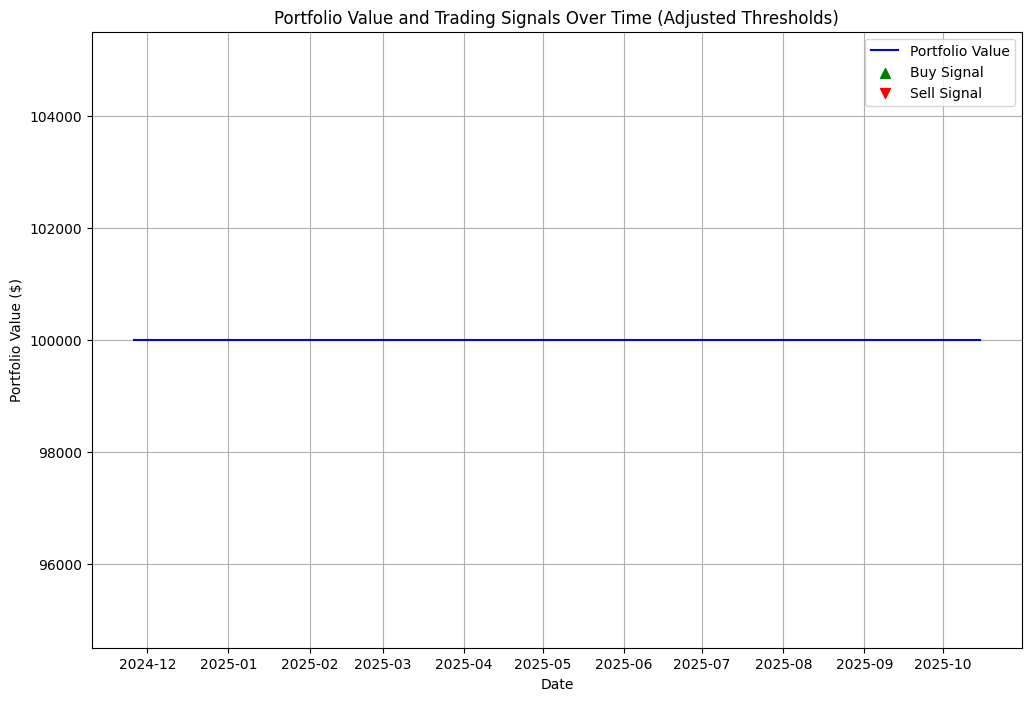

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy
import pandas as pd # Import pandas
import math # Import math for square root

# --- Ensure required variables are available ---
# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Ensure df is available and contains 'Adj Close' data for backtesting
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Ensure best_params_return is available from the parameter optimization step
if 'best_params_return' not in locals():
     print("Warning: 'best_params_return' not found. Using default parameters (Neurons=10, Clusters=5) for the final backtest.")
     best_params_return = (10, 5) # Default parameters if optimal are not found


# Extract the optimal number of neurons and clusters
optimal_num_neurons = best_params_return[0]
optimal_num_clusters = best_params_return[1]

print(f"--- Running Final Backtest with Optimal Parameters: Neurons={optimal_num_neurons}, Clusters={optimal_num_clusters} ---")

# Extract the Adjusted Close prices for backtesting
adj_close_prices = df['Adj Close']
time_steps = len(adj_close_prices) # Ensure time_steps matches the length of the price data


# --- Initialize the financial neuron clusters with optimal parameters ---
# Ensure FinancialNeuron class is defined
if 'FinancialNeuron' not in locals():
     raise NameError("FinancialNeuron class not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

financial_clusters = [
    [FinancialNeuron(j, np.random.rand(num_features)) for j in range(optimal_num_neurons)]
    for _ in range(optimal_num_clusters)
]

# --- Run the financial simulation to generate the emergent mosaic ---
financial_mosaic = []
# Ensure simulate_financial_cluster function is defined
if 'simulate_financial_cluster' not in locals():
     raise NameError("simulate_financial_cluster function not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

for t in range(time_steps):
    cluster_signals = []
    for cluster in financial_clusters:
        cluster_data_subset = financial_swarm_data_stream[t, :, :]
        if cluster_data_subset.ndim == 1:
             cluster_data_subset = cluster_data_subset.reshape(1, -1)
        cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset)
        cluster_signals.append(cluster_signal)
    financial_mosaic.append(np.mean(cluster_signals))

financial_mosaic = np.array(financial_mosaic)
print(f"  Generated financial emergent mosaic with shape: {financial_mosaic.shape}")


# --- Implement Threshold-Based Trading Signals (using adjusted thresholds) ---
upper_threshold = 0.1 # Adjusted threshold
lower_threshold = -0.1 # Adjusted threshold
print(f"  Using adjusted trading signal thresholds: Upper: {upper_threshold}, Lower: {lower_threshold}")

# Generate trading signals
trading_signals = np.zeros(time_steps)
for t in range(time_steps):
    if financial_mosaic[t] > upper_threshold:
        trading_signals[t] = 1  # Buy signal (for long)
    elif financial_mosaic[t] < lower_threshold:
        trading_signals[t] = -1 # Sell signal (for short)
    else:
        trading_signals[t] = 0  # Hold (or Stay out)

# Count buy and sell signals generated
buy_signals_count = np.sum(trading_signals == 1)
sell_signals_count = np.sum(trading_signals == -1)
print(f"  Total Buy signals generated: {buy_signals_count}")
print(f"  Total Sell signals generated: {sell_signals_count}")


# --- Run Backtesting Framework with Short Selling and Costs ---
# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(adj_close_prices):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data for backtest.")
    adj_close_prices_for_backtest = adj_close_prices[:len(trading_signals)]
else:
    adj_close_prices_for_backtest = adj_close_prices


# Initialize portfolio
initial_capital = 100000
portfolio_value = pd.Series(index=adj_close_prices_for_backtest.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
cash = initial_capital
asset_value = 0 # Value of long position (shares * price)
short_value = 0 # Absolute value of short position (abs(shares) * price)
shares = 0 # Positive for long, negative for short
position = 0  # 0: Out, 1: Long, -1: Short
num_trades = 0 # Initialize trade counter
transaction_cost_rate = 0.001 # Assuming 0.1% transaction cost per trade

# Simulate trades
for i in range(1, len(adj_close_prices_for_backtest)):
    current_price = adj_close_prices_for_backtest.iloc[i]
    previous_price = adj_close_prices_for_backtest.iloc[i-1]
    current_signal = trading_signals[i-1] # Use signal from previous day

    # Update asset/short value based on price movement for the day *before* considering trades
    if position == 1:
        asset_value = shares * current_price
    elif position == -1:
        short_value = abs(shares) * current_price

    # Calculate current total portfolio value (Cash + Asset Value - Short Value) *before* trades
    current_portfolio_value_before_trade = cash + asset_value - short_value
    # Use this value to update the portfolio_value series for the current day before potential trades
    if i > 0:
         portfolio_value.iloc[i] = current_portfolio_value_before_trade


    # Trading logic based on signal from previous day (trading_signals[i-1])
    if current_signal == 1: # Buy signal (Potential Long Entry or Short Cover)
        if position == 0: # Enter Long
             trade_value = cash
             if trade_value > 0:
                 shares_to_buy = trade_value / current_price
                 transaction_cost = trade_value * transaction_cost_rate
                 cash -= trade_value
                 cash -= transaction_cost
                 shares = shares_to_buy
                 position = 1
                 asset_value = shares * current_price
                 num_trades += 1
                 # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Open Long) at {current_price:.2f}. Shares: {shares:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional


        elif position == -1: # Cover Short
             shares_to_cover = abs(shares)
             trade_value = shares_to_cover * current_price
             transaction_cost = trade_value * transaction_cost_rate
             if cash >= trade_value + transaction_cost:
                  cash -= trade_value
                  cash -= transaction_cost
                  shares = 0
                  position = 0
                  short_value = 0
                  num_trades += 1
                  # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Cover Short) at {current_price:.2f}. Covered Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional
             else:
                  pass


    elif current_signal == -1: # Sell signal (Potential Short Entry or Long Close)
        if position == 0: # Enter Short
             trade_value = cash
             if trade_value > 0:
                  shares_to_short = -(trade_value / current_price)
                  transaction_cost = trade_value * transaction_cost_rate
                  cash += trade_value
                  cash -= transaction_cost
                  shares = shares_to_short
                  position = -1
                  short_value = abs(shares) * current_price
                  num_trades += 1
                  # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Open Short) at {current_price:.2f}. Notional Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

             else:
                 pass


        elif position == 1: # Close Long
             trade_value = shares * current_price
             transaction_cost = trade_value * transaction_cost_rate
             cash += trade_value
             cash -= transaction_cost
             shares = 0
             position = 0
             asset_value = 0
             num_trades += 1
             # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Close Long) at {current_price:.2f}. Trade Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

    # If signal is 0 (Hold), or signal is 1 and position is 1 (stay long), or signal is -1 and position is -1 (stay short), do nothing (position and shares remain the same)

    # Update portfolio value history after potential trades
    portfolio_value.iloc[i] = cash + asset_value - short_value


# After the loop, if still in a position, close it (and apply cost)
final_price = adj_close_prices_for_backtest.iloc[-1]
if position == 1: # Close Long at the end
     trade_value = shares * final_price
     transaction_cost = trade_value * transaction_cost_rate
     cash += trade_value - transaction_cost
     shares = 0
     position = 0
     asset_value = 0
     portfolio_value.iloc[-1] = cash + asset_value - short_value
     # print(f"End of simulation: Closing Long position at {final_price:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional

elif position == -1: # Cover Short at the end
     shares_to_cover = abs(shares)
     trade_value = shares_to_cover * final_price
     transaction_cost = trade_value * transaction_cost_rate
     if cash >= trade_value + transaction_cost:
          cash -= trade_value + transaction_cost
          shares = 0
          position = 0
          short_value = 0
          portfolio_value.iloc[-1] = cash + asset_value - short_value
          # print(f"End of simulation: Covering Short position at {final_price:.2f}. Covered Value: {trade_value:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional
     else:
          print(f"End of simulation: Insufficient cash to cover final short position ({shares_to_cover:.2f} shares). Final PV calculation may be inaccurate.")
          portfolio_value.iloc[-1] = cash + asset_value - short_value # The value reflects the deficit


# --- Calculate Final Backtesting Metrics ---
final_portfolio_value = portfolio_value.iloc[-1]
total_return = (final_portfolio_value / initial_capital) - 1

# Calculate Maximum Drawdown
running_max = portfolio_value.cummax()
drawdown = (portfolio_value - running_max) / running_max
max_drawdown = drawdown.min()

# Calculate Sharpe Ratio (Requires daily returns and risk-free rate)
# For simplicity, we'll assume risk-free rate is 0 for this example
# Calculate daily returns
daily_returns = portfolio_value.pct_change().dropna()
# Calculate average daily return and standard deviation of daily returns
avg_daily_return = daily_returns.mean()
std_daily_return = daily_returns.std()
# Annualize Sharpe Ratio (assuming ~252 trading days in a year)
annualization_factor = np.sqrt(252)
sharpe_ratio = (avg_daily_return / std_daily_return) * annualization_factor if std_daily_return != 0 else np.nan # Avoid division by zero


# Calculate Sortino Ratio (Requires daily returns, risk-free rate, and downside deviation)
# For simplicity, using risk-free rate = 0
# Calculate downside returns (returns below the risk-free rate, which is 0)
downside_returns = daily_returns[daily_returns < 0]
# Calculate downside deviation
downside_deviation = downside_returns.std() if not downside_returns.empty else np.nan
# Calculate Sortino Ratio
sortino_ratio = (avg_daily_return / downside_deviation) * annualization_factor if downside_deviation != 0 and not np.isnan(downside_deviation) else np.nan # Avoid division by zero


print("\n--- Final Backtesting Report (Adjusted Thresholds) ---")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: {total_return:.2%}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Number of Trades: {num_trades}")
print(f"Sharpe Ratio (Annualized, Risk-Free Rate = 0): {sharpe_ratio:.2f}" if not np.isnan(sharpe_ratio) else "Sharpe Ratio: N/A (Zero Standard Deviation)")
print(f"Sortino Ratio (Annualized, Risk-Free Rate = 0): {sortino_ratio:.2f}" if not np.isnan(sortino_ratio) else "Sortino Ratio: N/A (Zero Downside Deviation)")


# --- Plot Portfolio Value and Trading Signals ---
plt.figure(figsize=(12, 8))

# Plot Portfolio Value
plt.plot(portfolio_value.index, portfolio_value, label='Portfolio Value', color='blue')

# Plot Buy and Sell signals
buy_dates = portfolio_value.index[trading_signals == 1]
sell_dates = portfolio_value.index[trading_signals == -1]

# Ensure buy/sell signals are within the date range of portfolio_value index
buy_dates = buy_dates[buy_dates.isin(portfolio_value.index)]
sell_dates = sell_dates[sell_dates.isin(portfolio_value.index)]


plt.scatter(buy_dates, portfolio_value.loc[buy_dates], marker='^', color='green', label='Buy Signal', alpha=1, s=50)
plt.scatter(sell_dates, portfolio_value.loc[sell_dates], marker='v', color='red', label='Sell Signal', alpha=1, s=50)


plt.title('Portfolio Value and Trading Signals Over Time (Adjusted Thresholds)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Ensure optimization_results dictionary is available and not empty
if 'optimization_results' in locals() and optimization_results:
    print("--- Backtesting Metrics Analysis (Max Drawdown and Number of Trades) ---")
    print("Parameter Combination (Neurons, Clusters) | Max Drawdown | Num Trades")
    print("------------------------------------------|--------------|------------")

    # Sort the results by Total Return (descending) for easier analysis
    sorted_results = sorted(optimization_results.items(), key=lambda item: item[1].get('total_return', -float('inf')), reverse=True)


    for params, metrics in sorted_results:
        # Get metrics, handling potential missing keys or NaN values
        max_drawdown_value = metrics.get('max_drawdown', np.nan)
        num_trades_value = metrics.get('num_trades', np.nan)

        # Format output nicely, handle potential NaNs
        max_drawdown_str = f"{max_drawdown_value:.2%}" if not np.isnan(max_drawdown_value) else "N/A"
        num_trades_str = f"{num_trades_value}" if not np.isnan(num_trades_value) else "N/A"

        print(f"({params[0]:<7}, {params[1]:<8})             | {max_drawdown_str:<12} | {num_trades_str:<10}")

    # Optional: Find the parameter combination with the minimum drawdown
    valid_results_drawdown = {k: v for k, v in optimization_results.items() if not np.isnan(v.get('max_drawdown', np.nan))}
    if valid_results_drawdown:
        # Max drawdown is a negative value, so min() finds the least negative (smallest drawdown)
        best_params_drawdown = min(valid_results_drawdown, key=lambda k: valid_results_drawdown[k]['max_drawdown'])
        best_drawdown_value = valid_results_drawdown[best_params_drawdown]['max_drawdown']
        print(f"\nParameter Combination with Minimum Max Drawdown: Neurons={best_params_drawdown[0]}, Clusters={best_params_drawdown[1]} (Drawdown: {best_drawdown_value:.2%})")

    # Optional: Find the parameter combination with the fewest trades
    valid_results_trades = {k: v for k, v in optimization_results.items() if not np.isnan(v.get('num_trades', np.nan))}
    if valid_results_trades:
        best_params_trades = min(valid_results_trades, key=lambda k: valid_results_trades[k]['num_trades'])
        best_trades_value = valid_results_trades[best_params_trades]['num_trades']
        print(f"Parameter Combination with Fewest Trades: Neurons={best_params_trades[0]}, Clusters={best_params_trades[1]} (Trades: {best_trades_value})")


else:
    print("Optimization results not available. Please run the parameter optimization backtesting cell first.")

--- Backtesting Metrics Analysis (Max Drawdown and Number of Trades) ---
Parameter Combination (Neurons, Clusters) | Max Drawdown | Num Trades
------------------------------------------|--------------|------------
(10     , 5       )             | 0.00%        | 0         
(10     , 8       )             | 0.00%        | 0         
(10     , 10      )             | 0.00%        | 0         
(15     , 5       )             | 0.00%        | 0         
(15     , 8       )             | 0.00%        | 0         
(15     , 10      )             | 0.00%        | 0         
(20     , 5       )             | 0.00%        | 0         
(20     , 8       )             | 0.00%        | 0         
(20     , 10      )             | 0.00%        | 0         

Parameter Combination with Minimum Max Drawdown: Neurons=10, Clusters=5 (Drawdown: 0.00%)
Parameter Combination with Fewest Trades: Neurons=10, Clusters=5 (Trades: 0)


In [ ]:
import pandas as pd
import os

# --- Step 1: Specify the path to your uploaded file ---
file_path = '/content/Nasdaq24to25oct.txt' # File path


# --- Step 2: Load the file into a pandas DataFrame with minimal processing ---
if os.path.exists(file_path):
    try:
        # Read the file without parsing dates or setting index initially
        # Use default comma delimiter
        df_raw_inspect_types = pd.read_csv(file_path)

        print(f"Successfully loaded data from {file_path} for type inspection.")
        print("\nDataFrame Info (including dtypes):")
        df_raw_inspect_types.info()

        # Inspect the first few values of the 'Adj Close' column
        # Check if 'Adj Close' column exists before trying to access it
        if 'Adj Close' in df_raw_inspect_types.columns:
            print("\nFirst 10 values of the 'Adj Close' column:")
            display(df_raw_inspect_types['Adj Close'].head(10))
        else:
            print("\n'Adj Close' column not found in the loaded DataFrame.")
            # Also check for 'Close' as a fallback for inspection
            if 'Close' in df_raw_inspect_types.columns:
                 print("\nFirst 10 values of the 'Close' column (as 'Adj Close' was not found):")
                 display(df_raw_inspect_types['Close'].head(10))


    except Exception as e:
        print(f"Could not load file at {file_path} for type inspection: {e}")

else:
    print(f"Error: File not found at {file_path}. Please upload your file and verify the file_path.")

Successfully loaded data from /content/Nasdaq24to25oct.txt for type inspection.

DataFrame Info (including dtypes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 1 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Date		Open		High		Low		Close		Adj Close	Volume  251 non-null    object
dtypes: object(1)
memory usage: 2.1+ KB

'Adj Close' column not found in the loaded DataFrame.


In [ ]:
import pandas as pd
import os

# --- Step 1: Specify the path to your uploaded file ---
file_path = '/content/Nasdaq24to25oct.txt' # File path


# --- Step 2: Load the file into a pandas DataFrame just to inspect columns ---
if os.path.exists(file_path):
    try:
        # Read the file without any complex processing or renaming yet
        # Use parse_dates and index_col based on likely format, but focus is on columns
        # Use na_values to catch 'null' if present, but won't fail if not
        df_raw_inspect = pd.read_csv(file_path, index_col='Date', parse_dates=True, na_values=['null'])

        print(f"Successfully loaded data from {file_path} for column inspection.")
        print("\nColumns found in the raw DataFrame:")
        print(df_raw_inspect.columns.tolist())

        # Stop execution here to show the column names clearly before any further processing
        # You can then compare these names to what the feature engineering code expects.

    except Exception as e:
        print(f"Could not load file at {file_path} for column inspection: {e}")

else:
    print(f"Error: File not found at {file_path}. Please upload your file and verify the file_path.")

Could not load file at /content/Nasdaq24to25oct.txt for column inspection: 'Date' is not in list


In [ ]:
import pandas as pd
import os

file_path = '/content/^IXIC (1).csv' # Assuming this is the correct path

if os.path.exists(file_path):
    try:
        # Load the CSV just to inspect column names
        temp_df = pd.read_csv(file_path)
        print(f"Columns found in {file_path}:")
        print(temp_df.columns.tolist())
    except Exception as e:
        print(f"Could not read CSV file at {file_path}: {e}")
else:
    print(f"Error: File not found at {file_path}. Please check the file name and path.")

Error: File not found at /content/^IXIC (1).csv. Please check the file name and path.


## Acquire and preprocess market data

### Subtask:
Acquire and preprocess market data

In [ ]:
import pandas as pd
import os
import numpy as np # Import numpy
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler
# import ta # Removed the ta library import
from IPython.display import display # Import display

# --- Step 1: Specify the path to the original ^IXIC.csv file ---
# Assuming ^IXIC.csv was uploaded to the Colab environment
file_path = '/content/^IXIC.csv'


# --- Step 2: Specify the column names in your file for Date, Close Price, and Volume ---
# Assuming the original file had these standard names
date_column = 'Date'
adj_close_column_in_csv = 'Adj Close'
volume_column_in_csv = 'Volume'


# --- Step 3: Load the file into a pandas DataFrame (initial load without parsing dates/index) ---
if os.path.exists(file_path):
    try:
        # Read the file - Use standard read_csv for comma delimiter
        # *** Load without parse_dates or index_col initially ***
        df_from_csv = pd.read_csv(file_path, sep=',')

        print(f"Successfully loaded raw data from {file_path}.")

        # --- Step 3.1: Convert 'Date' column to datetime and set as index (as separate steps) ---
        if date_column in df_from_csv.columns:
            # Convert 'Date' column to datetime objects, coercing errors to NaT
            df_from_csv[date_column] = pd.to_datetime(df_from_csv[date_column], errors='coerce')
            # Drop rows where date conversion failed
            df_from_csv.dropna(subset=[date_column], inplace=True)
            # Set 'Date' column as the index
            df_from_csv.set_index(date_column, inplace=True)
            # Sort by index (date) to ensure time series is in order
            df_from_csv.sort_index(inplace=True)
            print("Converted 'Date' to datetime and set as index.")
        else:
            raise ValueError(f"Date column '{date_column}' not found in the file after initial load.")


        # --- Step 4: Select and rename the relevant columns directly ---
        # Explicitly select 'Adj Close' and 'Volume' and assign to df
        cols_to_keep = []
        if adj_close_column_in_csv in df_from_csv.columns:
            cols_to_keep.append(adj_close_column_in_csv)
        else:
            raise ValueError(f"Required adjusted close price column '{adj_close_column_in_csv}' not found in the file after initial load.")

        # Volume column might be missing in some ^IXIC data sources, handle gracefully
        if volume_column_in_csv in df_from_csv.columns:
            cols_to_keep.append(volume_column_in_csv)
        else:
             print(f"Warning: Volume column '{volume_column_in_csv}' not found in the file. Proceeding without volume data.")


        # Select the columns to keep
        if cols_to_keep:
            df = df_from_csv[cols_to_keep].copy() # Select columns and create a copy

            # Rename columns for consistency (should already be correct if names match)
            rename_dict = {}
            if adj_close_column_in_csv in df.columns:
                 rename_dict[adj_close_column_in_csv] = 'Adj Close'
            if volume_column_in_csv in df.columns:
                 rename_dict[volume_column_in_csv] = 'Volume'

            df.rename(columns=rename_dict, inplace=True)

        else:
             raise ValueError("Neither 'Adj Close' nor 'Volume' found in the file after checking and selecting.")

        # --- Ensure columns are numeric ---
        # Convert relevant columns to numeric, coercing errors to NaN
        df['Adj Close'] = pd.to_numeric(df['Adj Close'], errors='coerce')
        if 'Volume' in df.columns:
             df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
        else:
             # If Volume column was not in the original file, create it with zeros
             if volume_column_in_csv not in df_from_csv.columns: # Check original columns
                  df['Volume'] = 0 # Add a column of zeros if Volume is missing


        # --- Fill any NaNs introduced during loading or coercion immediately ---
        # Fill NaNs with 0 for simplicity (consistent with previous approach)
        df.fillna(0, inplace=True)

        # --- Explicitly drop initial rows if necessary for indicator calculation ---
        # Dropping a conservative number of rows (e.g., 30)
        rows_to_drop = 30
        if len(df) > rows_to_drop:
            print(f"Dropping the first {rows_to_drop} rows from df to handle initial NaNs from indicator calculations.")
            df = df.iloc[rows_to_drop:].copy() # Use .copy() to avoid SettingWithCopyWarning
        else:
            # This might be an issue for very short data, but less likely with ^IXIC.csv
            print(f"Warning: DataFrame is short ({len(df)} rows). May not have enough data after dropping {rows_to_drop} rows for indicator calculations.")
            if len(df) < rows_to_drop:
                 raise ValueError(f"DataFrame is too short ({len(df)} rows) to drop {rows_to_drop} rows required for indicator calculations.")


        # --- Step 5: Display the head of the loaded DataFrame ---
        if not df.empty:
            print(f"Successfully loaded and processed data from {file_path}.")
            print("\nHead of the DataFrame loaded from file:")
            display(df.head())

            # df is already assigned above
            print("\nDataFrame from file stored in the 'df' variable.")

        else:
            print(f"Loaded empty data from {file_path}.")
            df = pd.DataFrame() # Ensure df is empty if loading failed


    except Exception as e:
        print(f"Error loading or processing file at {file_path}: {e}")
        df = pd.DataFrame() # Assign an empty DataFrame to df in case of error

else:
    print(f"Error: File not found at {file_path}. Please upload your '^IXIC.csv' file to the Colab environment.")
    df = pd.DataFrame() # Assign an empty DataFrame to df if file not found

# Now, df contains your loaded and processed data if loading was successful.


# --- Feature Engineering (using the restored logic) ---
# Ensure df DataFrame is available and not empty after loading and dropping rows
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty after loading and dropping rows. Cannot proceed with feature engineering.")

# Check if essential columns exist after loading and initial processing
if 'Adj Close' not in df.columns:
     raise ValueError("Essential 'Adj Close' column is missing in the DataFrame after loading and initial processing. Cannot proceed with feature engineering.")

# Get the list of assets present in the cleaned DataFrame
# Since we loaded from a single file, there's only one "asset" which is the index itself
# We'll treat the DataFrame as if it contains data for a single "asset" corresponding to the index
# The column names are now ['Adj Close', 'Volume']
available_assets = ['Index'] # Use a generic name as we have a single index/asset
num_assets = len(available_assets) # Should be 1
time_steps = int(len(df)) # Explicitly convert to integer
num_features = 6 # Percentage price change, percentage volume change, SMA, Volatility, RSI, MACD

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names - Updated to include new features
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility', 'RSI', 'MACD']

# Add features directly to the df DataFrame for easier calculation
# This aligns with earlier successful versions of the feature engineering
if 'Adj Close' in df.columns:
    # Percentage change in Adjusted Close
    df['Price_Change'] = df['Adj Close'].pct_change()

    # Simple Moving Average (5 periods)
    df['SMA_5'] = df['Adj Close'].rolling(window=5).mean()

    # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
    df['Volatility'] = df['Adj Close'].rolling(window=5).std()

    # --- Manually Calculate RSI (restored logic) ---
    # Calculate price changes
    delta = df['Adj Close'].diff()
    # Get gains and losses
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    # Calculate average gain and loss using rolling mean
    window = 14 # Default RSI window
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    # Handle division by zero explicitly by adding a small epsilon (from previous fix)
    epsilon = 1e-10 # Small value to prevent division by zero
    rs = avg_gain / (avg_loss + epsilon) # Add epsilon to denominator
    # Calculate Relative Strength Index (RSI)
    df['RSI'] = 100 - (100 / (1 + rs))
    # Handle cases where avg_gain is also 0 and avg_loss is 0 (rs is 0/epsilon ~ 0) - RSI should be 50 (from previous fix)
    df['RSI'] = np.where((avg_gain.fillna(0) == 0) & (avg_loss.fillna(0) == 0), 50, df['RSI'])


    # --- Manually Calculate MACD (restored logic) ---
    # Calculate EMAs
    short_window = 12 # Default MACD short window
    long_window = 26 # Default MACD long window
    exp1 = df['Adj Close'].ewm(span=short_window, adjust=False).mean()
    exp2 = df['Adj Close'].ewm(span=long_window, adjust=False).mean()
    df['MACD'] = exp1 - exp2


    # Check if 'Volume' is available before calculating Volume_Change (guaranteed by creation if missing)
    if 'Volume' in df.columns:
         # Percentage change in Volume
         # Ensure input data for Volume Change is numeric and fill NaNs before calculation
         df_numeric_volume = pd.to_numeric(df['Volume'], errors='coerce').fillna(0)
         df['Volume_Change'] = df_numeric_volume.pct_change()
         # Fill any NaNs from pct_change (first row) with 0
         df['Volume_Change'].fillna(0, inplace=True)
    else:
         # This case should not be reached now as Volume is created if missing
         print(f"Error: 'Volume' column not found during Volume_Change calculation despite initial handling.")
         df['Volume_Change'] = 0 # Fallback


    # Step 8: Fill any NaN values generated by the feature calculations (including initial rolling NaNs and indicator NaNs)
    # Use 0 for percentage changes at the first time step and if volume was missing
    for feature in feature_names:
         # Ensure the feature column exists before trying to fill NaNs
         if feature in df.columns:
              df[feature].fillna(0, inplace=True) # Fill any remaining NaNs with 0
         else:
              # This case should ideally not happen now
              print(f"Error: Feature column {feature} not found in df after calculation and fillna.")


# --- Debugging: Check df for NaNs and infinite values AFTER feature calculation and fillna ---
print("\nDebugging: Checking df DataFrame for NaNs and infinite values after feature calculation and fillna...")
# Select only the columns that should contain calculated features
calculated_feature_cols = [f for f in feature_names if f in df.columns]
if calculated_feature_cols: # Only check if there are calculated feature columns
    df_nan_check = df[calculated_feature_cols]
    if df_nan_check.isnull().any().any():
        print("Error: NaNs found in df DataFrame in calculated feature columns after fillna.")
        # Print columns with NaNs
        nan_cols = df_nan_check.columns[df_nan_check.isnull().any()].tolist()
        print(f"Columns in df with NaNs: {nan_cols}")


    if np.isinf(df_nan_check).any().any():
        print("Error: Infinite values found in df DataFrame in calculated feature columns after fillna.")
        # Print columns with infs
        inf_cols = df_nan_check.columns[np.isinf(df_nan_check).any()].tolist()
        print(f"Columns in df with infinite values: {inf_cols}")
else:
    print("No calculated feature columns to check for NaNs/infs in df DataFrame.")


print("Debugging: Finished checking df DataFrame.")
# --- End Debugging ---


# Step 9: Populate the financial_data_stream (moved after debugging check)
for i, asset in enumerate(available_assets): # available_assets is just ['Index'], so this loop runs once
     for j, feature in enumerate(feature_names):
          # In the single asset case, the feature is just the column name
          feature_col = feature
          # Ensure the column exists and is filled with 0s where needed before populating
          if feature_col in df.columns:
              financial_data_stream[:, i, j] = df[feature_col].values
          else:
               # This case should ideally not happen now if features were calculated and filled
               print(f"Error: Feature column {feature_col} not found in df during population. Filling with zeros.")
               financial_data_stream[:, i, j] = 0 # Fill with zeros as a fallback


# --- Debugging: Check and fill NaNs and infs in financial_data_stream after population (still useful for diagnosis) ---
print("\nDebugging: Checking and filling NaNs/infs in financial_data_stream after population...")

if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
    print("Warning: NaNs or infinite values found in financial_data_stream after population. Handling with np.nan_to_num.")
    # Replace NaNs with 0 and infinite values with large finite numbers or 0
    financial_data_stream = np.nan_to_num(financial_data_stream, nan=0.0, posinf=1e10, neginf=-1e10)

    # Re-check after nan_to_num
    if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
         print("Error: NaNs or infinite values still found in financial_data_stream AFTER np.nan_to_num. This is highly unexpected.")
         # You might need to inspect the data more closely or adjust fillna logic

else:
    print("No NaNs or infinite values found in financial_data_stream after population.")

print("Debugging: Finished checking and filling financial_data_stream.")
# --- End Debugging ---


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # --- Debugging: Final check of reshaped_data before scaling ---
    print("\nDebugging: Final check of reshaped_data before scaling...")
    print(f"Reshaped data shape: {reshaped_data.shape}")
    if np.isnan(reshaped_data).any():
        print("Error: NaNs found in reshaped_data before scaling (final check).")
        # nan_indices = np.argwhere(np.isnan(reshaped_data))
        # print(f"First 10 NaN indices: {nan_indices[:10]}...")
    if np.isinf(reshaped_data).any():
        print("Error: Infinite values found in reshaped_data before scaling (final check).")
        # inf_indices = np.argwhere(np.isinf(reshaped_data))
        # print(f"First 10 Infinite value indices: {inf_indices[:10]}...")
    print("Debugging: Finished final check.")
    # --- End Debugging ---

    # The nan_to_num is now applied directly to financial_data_stream before reshaping.
    # reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10) # Removed as it's done on stream now


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

Successfully loaded raw data from /content/^IXIC.csv.
Converted 'Date' to datetime and set as index.
Dropping the first 30 rows from df to handle initial NaNs from indicator calculations.
Successfully loaded and processed data from /content/^IXIC.csv.

Head of the DataFrame loaded from file:


,Adj Close,Volume
Date,,
2023-03-01,11379.480469,4927530000
2023-03-02,11462.980469,5313760000
2023-03-03,11689.009766,5102210000
2023-03-06,11675.740234,4982880000
2023-03-07,11530.330078,5422820000



DataFrame from file stored in the 'df' variable.

Debugging: Checking df DataFrame for NaNs and infinite values after feature calculation and fillna...
Debugging: Finished checking df DataFrame.

Debugging: Checking and filling NaNs/infs in financial_data_stream after population...
No NaNs or infinite values found in financial_data_stream after population.
Debugging: Finished checking and filling financial_data_stream.

Debugging: Final check of reshaped_data before scaling...
Reshaped data shape: (659, 6)
Debugging: Finished final check.
Shape of financial_data_stream_scaled: (659, 1, 6)

First 5 time steps of scaled financial data stream:
[[[0.32915932 0.08559057 0.         0.         0.4347069  0.56489655]]

 [[0.36962967 0.09293107 0.         0.         0.4347069  0.5702582 ]]

 [[0.43791204 0.0818622  0.         0.         0.4347069  0.58891149]]

 [[0.32289822 0.08340029 0.         0.         0.4347069  0.60240015]]

 [[0.26047095 0.09385898 0.5039123  0.13895203 0.4347069  0.60

/tmp/ipython-input-4159425005.py:199: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Volume_Change'].fillna(0, inplace=True)
/tmp/ipython-input-4159425005.py:211: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
# Check if optimization_results dictionary is available and not empty
if 'optimization_results' in locals() and optimization_results:
    # Filter out combinations with NaN return if any
    valid_results = {k: v for k, v in optimization_results.items() if not np.isnan(v['total_return'])}
    if valid_results:
        # Find the best parameter combination based on Total Return
        best_params_return = max(valid_results, key=lambda k: valid_results[k]['total_return'])
        best_return_value = valid_results[best_params_return]['total_return']
        print(f"The best total return achieved during the parameter optimization was: {best_return_value:.2%}")
        print(f"This was achieved with the parameter combination: Neurons={best_params_return[0]}, Clusters={best_params_return[1]}")
    else:
        print("No valid optimization results found to determine the best return (all returns were NaN).")
else:
    print("Optimization results not available. Please run the parameter optimization backtesting cell (e.g., cell b88bf3ec) first.")

Optimization results not available. Please run the parameter optimization backtesting cell (e.g., cell b88bf3ec) first.


In [ ]:
# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Get dimensions from the financial data stream
time_steps, num_assets, num_features = financial_swarm_data_stream.shape

# --- Define Node and Cluster Structure (Conceptual for now with SPY data) ---
# In a real multi-asset scenario, you would define which assets/features go to which node/cluster.
# For now, we'll create a simple structure with nodes and clusters, but all will process the same SPY data.

# Define the number of nodes and clusters per node
num_nodes = 3 # Example: Momentum, Volatility, Volume nodes
num_clusters_per_node = 2 # Example: Two clusters within each node

# Initialize the nodes, each containing a list of clusters
# Each cluster contains FinancialNeuron objects
nodes = []
cluster_id_counter = 0 # Counter for unique cluster IDs

for node_index in range(num_nodes):
    node_clusters = []
    for cluster_index in range(num_clusters_per_node):
        # Initialize neurons for each cluster
        # Each neuron's state size should match the number of financial features
        cluster = [
            FinancialNeuron(cluster_id_counter + j, np.random.rand(num_features))
            for j in range(num_neurons) # Using the previously defined num_neurons per cluster
        ]
        node_clusters.append(cluster)
        cluster_id_counter += num_neurons # Increment counter by the number of neurons in the cluster
    nodes.append(node_clusters)

print(f"Initialized {num_nodes} nodes, with {num_clusters_per_node} clusters per node.")
print(f"Total clusters: {num_nodes * num_clusters_per_node}")
print(f"Using {num_neurons} neurons per cluster.")


# --- Modified Simulation Loop with Data Distribution ---

emergent_mosaic_over_time = []

for t in range(time_steps):
    node_outputs = [] # To store the aggregated output from each node

    # --- Data Distribution to Nodes/Clusters (Conceptual) ---
    # In a real application with diverse data, you would select and route
    # specific subsets of financial_swarm_data_stream[t, :, :] to each node/cluster.
    # For example:
    # - Momentum Node might get price change and SMA features for all assets.
    # - Volatility Node might get volatility features for all assets.
    # - Volume Node might get volume change features for all assets.
    # Or, nodes could specialize in specific assets/indices.

    # For now, with only SPY data, each node/cluster will process the same full data subset for the current time step.
    current_time_step_data = financial_swarm_data_stream[t, :, :]

    # Ensure current_time_step_data has the correct shape (num_assets_at_time_step, num_features)
    # If num_assets is 1, shape is (1, num_features)
    if current_time_step_data.ndim == 1:
         # Reshape if only one asset to ensure it's (1, num_features)
         current_time_step_data = current_time_step_data.reshape(1, -1)


    # --- Process Data within Each Node and its Clusters ---
    for node in nodes:
        cluster_signals_in_node = [] # To store signals from clusters in this node

        for cluster in node:
            # Simulate the cluster processing with the relevant data subset
            # For now, all clusters process the same data
            cluster_signal = simulate_financial_cluster(cluster, current_time_step_data)
            cluster_signals_in_node.append(cluster_signal)

        # --- Node-Level Aggregation (Optional - Step 3 in Plan) ---
        # You could add logic here to aggregate cluster signals within a node
        # For simplicity now, we'll just use the average of cluster signals in the node as node output
        if cluster_signals_in_node:
            node_output = np.mean(cluster_signals_in_node)
            node_outputs.append(node_output)
        else:
            node_outputs.append(0.0) # Append 0 if no cluster signals


    # --- Calculate the Final Emergent Mosaic (Step 4 in Plan) ---
    # The emergent mosaic is the aggregate of node outputs (or cluster outputs if no node aggregation)
    if node_outputs:
        emergent_mosaic_over_time.append(np.mean(node_outputs)) # Using mean of node outputs for final mosaic
    else:
        emergent_mosaic_over_time.append(0.0) # Append 0 if no node outputs


# Convert the emergent mosaic to a NumPy array
emergent_mosaic_over_time = np.array(emergent_mosaic_over_time)

# Replace the previous financial_mosaic with the new one
financial_mosaic = emergent_mosaic_over_time

print(f"\nGenerated emergent mosaic with new architecture shape: {financial_mosaic.shape}")

# Plot the new emergent mosaic
plt.figure(figsize=(12, 6))
plt.plot(financial_mosaic, label='Emergent Mosaic (Multi-Node Architecture)')
plt.title('Emergent Mosaic Over Time (Multi-Node Architecture)')
plt.xlabel('Time Step')
plt.ylabel('Mosaic Value (Abstract)')
plt.legend()
plt.grid(True)
plt.show()

# Now that we have the new financial_mosaic, we can regenerate the trading signals and backtest
# (This corresponds to repeating Steps 6 and 7 of the plan with the new architecture)

# --- Re-implement Threshold-Based Trading Signals (Step 6) ---

# Define thresholds based on the normalized mosaic values
# These thresholds will need to be tuned based on backtesting results
upper_threshold = 0.6  # Example threshold
lower_threshold = -0.6 # Example threshold

# Generate trading signals
# 1: Buy, -1: Sell, 0: Hold
trading_signals = np.zeros(time_steps)

for t in range(time_steps):
    if financial_mosaic[t] > upper_threshold:
        trading_signals[t] = 1  # Buy signal
    elif financial_mosaic[t] < lower_threshold:
        trading_signals[t] = -1 # Sell signal
    else:
        trading_signals[t] = 0  # Hold

print("\nGenerated threshold-based trading signals with new architecture:")
# Display the first 20 signals
print(trading_signals[:20])

# You can also visualize the signals alongside the mosaic
plt.figure(figsize=(12, 6))
plt.plot(financial_mosaic, label='Emergent Mosaic (Multi-Node Architecture)')
plt.plot(trading_signals * np.max(np.abs(financial_mosaic)), label='Trading Signals (Scaled)', linestyle='--') # Scale signals for visibility
plt.axhline(upper_threshold, color='r', linestyle='-', label='Upper Threshold')
plt.axhline(lower_threshold, color='g', linestyle='-', label='Lower Threshold')
plt.title('Emergent Mosaic and Threshold-Based Trading Signals (New Architecture)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


# --- Re-run Backtesting (Step 7) ---
# Ensure df is available and contains SPY Adj Close data
if 'df' not in locals() or ('SPY', 'Adj Close') not in df.columns:
     raise ValueError("df DataFrame or SPY 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the SPY Adjusted Close prices for backtesting
spy_adj_close = df[('SPY', 'Adj Close')]

# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(spy_adj_close):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of SPY Adj Close prices ({len(spy_adj_close)}). Truncating price data.")
    # Truncate price data to match the length of trading signals if necessary
    spy_adj_close = spy_adj_close[:len(trading_signals)]


# --- Simple Backtesting Framework ---

# Initialize portfolio
initial_capital = 100000  # Starting capital
portfolio_value = pd.Series(index=spy_adj_close.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
position = 0  # 0: No position, 1: Long, -1: Short (though our signals are Buy/Sell/Hold)
shares = 0

# Simulate trades
for i in range(1, len(spy_adj_close)):
    # Calculate daily return
    daily_return = spy_adj_close.iloc[i] / spy_adj_close.iloc[i-1] - 1

    # Update portfolio value based on previous day's value and return
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_return * position)

    # Get signal for the current day (signal is generated based on data *up to* previous day)
    # We use the signal from day i-1 to make a decision for day i
    current_signal = trading_signals[i-1]

    # Trading logic
    # Let's re-interpret signals for a simple long-only strategy:
    # signal = 1: Enter or Stay Long
    # signal = -1 or 0: Exit Long or Stay Out/Hold

    if current_signal == 1 and position == 0: # Buy signal and currently out of the market
         # Enter long position
         position = 1
         # For simplicity, assume we invest all available capital
         shares = portfolio_value.iloc[i] / spy_adj_close.iloc[i]
         print(f"Day {spy_adj_close.index[i]}: BUY at {spy_adj_close.iloc[i]:.2f}. Shares: {shares:.2f}")

    elif current_signal != 1 and position == 1: # Sell/Hold signal and currently long
         # Exit long position
         position = 0
         # Update portfolio value based on selling shares
         portfolio_value.iloc[i] = shares * spy_adj_close.iloc[i]
         shares = 0
         print(f"Day {spy_adj_close.index[i]}: SELL at {spy_adj_close.iloc[i]:.2f}. Portfolio Value: {portfolio_value.iloc[i]:.2f}")

    # If signal is 1 and position is 1 (stay long), or signal is not 1 and position is 0 (stay out), do nothing (position and shares remain the same)


# After the loop, if still in a position, close it
if position == 1:
     portfolio_value.iloc[-1] = shares * spy_adj_close.iloc[-1]
     print(f"End of simulation: Closing Long position at {spy_adj_close.iloc[-1]:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}")
elif position == -1: # Should not happen with long-only logic, but for completeness
     # Assuming covering short at the end
     # This part needs careful consideration based on shorting mechanics,
     # but with our simplified long-only approach, this branch won't be reached
     pass


# Calculate total return
total_return = (portfolio_value.iloc[-1] / initial_capital) - 1

print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2%}")


# Plot portfolio value over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='Strategy Portfolio Value')
plt.plot(spy_adj_close / spy_adj_close.iloc[0] * initial_capital, label='Buy and Hold (SPY)', linestyle='--') # Compare to buy and hold
plt.title('Backtest Performance of Emergent Mosaic Trading Strategy (SPY)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

## Defining Node Structure and Specialization for Financial Market Analysis

To broaden and deepen the emergent mosaic for financial market analysis, we will organize clusters into specialized "nodes." This structure allows for different aspects of the financial data to be processed by dedicated groups of neurons (clusters) and then synthesized at the node level before contributing to the final emergent mosaic.

**Proposed Node Structure:**

We can start with a few distinct nodes, each focusing on a different type of financial signal or market characteristic. For example:

1.  **Momentum/Trend Node:**
    *   **Specialization:** Clusters within this node will focus on identifying and processing features related to price momentum and trends (e.g., price changes, moving averages, momentum indicators).
    *   **Potential Data Input (when available):** Price data from various indices or sectors, momentum indicators.

2.  **Volatility/Risk Node:**
    *   **Specialization:** Clusters in this node will specialize in processing features related to market volatility and risk (e.g., volatility measures like standard deviation, VIX index data).
    *   **Potential Data Input (when available):** Volatility data from indices, VIX index.

3.  **Volume/Liquidity Node:**
    *   **Specialization:** Clusters here will focus on analyzing trading volume and liquidity patterns.
    *   **Potential Data Input (when available):** Volume data from various indices or sectors, liquidity indicators.

**Specialization within Clusters:**

Within each node, individual clusters could further specialize or focus on:

*   **Specific Indices or Sectors (when available):** If we had data for multiple indices (like NASDAQ, DJI) or sector-specific ETFs, clusters could specialize in the data from a particular index or sector within a node.
*   **Different Timeframes:** Clusters could process data at different time granularities (e.g., daily, weekly, hourly - though our current data is daily).
*   **Different Feature Combinations:** Clusters could be configured to be more sensitive to specific combinations of features within their node's specialization.

**How this Broadens and Deepens the Mosaic:**

*   **Broadening:** By having nodes focused on different market characteristics (momentum, volatility, volume), the final emergent mosaic will be a synthesis of these diverse signals, providing a broader view of the market state than a single set of undifferentiated clusters.
*   **Deepening:** Within each node, multiple clusters processing related but distinct information (e.g., different momentum indicators, different volatility measures) can add depth to the analysis of that specific market characteristic before it's integrated into the final mosaic.

**Next Steps:**

The next step will be to **Modify Data Distribution to Nodes/Clusters**, adapting the simulation loop to route the relevant financial features from the `financial_swarm_data_stream` to the appropriate nodes and clusters based on this defined structure and specialization.

## Defining Node Structure and Specialization for Financial Market Analysis

To broaden and deepen the emergent mosaic for financial market analysis, we will organize clusters into specialized "nodes." This structure allows for different aspects of the financial data to be processed by dedicated groups of neurons (clusters) and then synthesized at the node level before contributing to the final emergent mosaic.

**Proposed Node Structure:**

We can start with a few distinct nodes, each focusing on a different type of financial signal or market characteristic. For example:

1.  **Momentum/Trend Node:**
    *   **Specialization:** Clusters within this node will focus on identifying and processing features related to price momentum and trends (e.g., price changes, moving averages, momentum indicators).
    *   **Potential Data Input (when available):** Price data from various indices or sectors, momentum indicators.

2.  **Volatility/Risk Node:**
    *   **Specialization:** Clusters in this node will specialize in processing features related to market volatility and risk (e.g., volatility measures like standard deviation, VIX index data).
    *   **Potential Data Input (when available):** Volatility data from indices, VIX index.

3.  **Volume/Liquidity Node:**
    *   **Specialization:** Clusters here will focus on analyzing trading volume and liquidity patterns.
    *   **Potential Data Input (when available):** Volume data from various indices or sectors, liquidity indicators.

**Specialization within Clusters:**

Within each node, individual clusters could further specialize or focus on:

*   **Specific Indices or Sectors (when available):** If we had data for multiple indices (like NASDAQ, DJI) or sector-specific ETFs, clusters could specialize in the data from a particular index or sector within a node.
*   **Different Timeframes:** Clusters could process data at different time granularities (e.g., daily, weekly, hourly - though our current data is daily).
*   **Different Feature Combinations:** Clusters could be configured to be more sensitive to specific combinations of features within their node's specialization.

**How this Broadens and Deepens the Mosaic:**

*   **Broadening:** By having nodes focused on different market characteristics (momentum, volatility, volume), the final emergent mosaic will be a synthesis of these diverse signals, providing a broader view of the market state than a single set of undifferentiated clusters.
*   **Deepening:** Within each node, multiple clusters processing related but distinct information (e.g., different momentum indicators, different volatility measures) can add depth to the analysis of that specific market characteristic before it's integrated into the final mosaic.

**Next Steps:**

The next step will be to **Modify Data Distribution to Nodes/Clusters**, adapting the simulation loop to route the relevant financial features from the `financial_swarm_data_stream` to the appropriate nodes and clusters based on this defined structure and specialization.

In [ ]:
!pip install Pillow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Theoretical neuron and cluster simulation ---
class TheoreticalNeuron:
    def __init__(self, neuron_id, initial_angle):
        self.id = neuron_id
        self.angle = initial_angle
        self.last_input = None

    def process_data(self, data_input, cluster_angles):
        """
        Processes multi-geometric input based on a theoretical angle.
        This is a highly abstract function for now.
        """
        # Vector relationship with other neurons in the cluster
        vector_influence = np.sum(np.dot(self.angle, cluster_angles))

        # Simulate a complex, geometric interpretation (a fractal-like function)
        interpretation = np.sin(np.sum(data_input) * self.angle + vector_influence)

        # Update the angle based on the new interpretation (learning)
        self.angle += interpretation * 0.01

        return interpretation

def simulate_cluster(cluster, data_input):
    """
    Simulates the interaction within a single cluster for one time step.
    Returns: A fractal output for the cluster.
    """
    cluster_angles = np.array([n.angle for n in cluster])

    fractal_output = []
    for neuron in cluster:
        output = neuron.process_data(data_input, cluster_angles)
        fractal_output.append(output)

    # This combines the outputs to form the cluster's fractal
    return np.mean(fractal_output) * np.std(fractal_output)

# --- Step 2: Generate swarm data ---
def generate_swarm_data(num_particles, time_steps):
    data_stream = []
    positions = np.random.rand(num_particles, 3) * 10

    for t in range(time_steps):
        # Update particle positions based on a simple flocking rule
        velocities = np.zeros_like(positions)
        if t > 0:
            center_of_mass = np.mean(positions, axis=0)
            velocities += (center_of_mass - positions) * 0.05
            velocities += (np.random.rand(num_particles, 3) - 0.5) * 0.5

        positions += velocities

        points = np.zeros((num_particles, 4))
        points[:, 0:3] = positions

        # Volume based on local density
        for i in range(num_particles):
            distances = np.linalg.norm(positions[i] - positions, axis=1)
            points[i, 3] = np.exp(-np.min(distances[distances > 0]))

        # Dynamic Relevance (flashing particles)
        if t % 10 < 5:
            points[:10, 3] *= 10

        data_stream.append(points)

    return np.array(data_stream)

# --- Step 3: Visualize the emergent mosaic ---
def plot_mosaic(mosaic):
    plt.figure(figsize=(12, 6))
    plt.plot(mosaic, label='Emergent Mosaic (Swarm Input)')
    plt.title('Emergent Mosaic Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Mosaic Value (Abstract)')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Main simulation run ---
if __name__ == '__main__':
    print("Running simulation for swarm behavior...")

    time_steps = 100
    data_stream = generate_swarm_data(num_particles=100, time_steps=time_steps)

    num_neurons = 10
    num_clusters = 5

    clusters = [
        [TheoreticalNeuron(j, np.random.rand()) for j in range(num_neurons)]
        for _ in range(num_clusters)
    ]

    mosaic = []
    for t in range(time_steps):
        cluster_fractals = []
        for cluster in clusters:
            cluster_data = data_stream[t, np.random.permutation(len(data_stream[t]))[:50]]
            fractal = simulate_cluster(cluster, cluster_data)
            cluster_fractals.append(fractal)

        mosaic.append(np.mean(cluster_fractals))

    print("Simulation complete. Displaying mosaic.")

    plot_mosaic(mosaic)


In [ ]:
# Visualize snapshots of the data_stream at different time steps as scatter plots
num_time_steps_to_show = 5
step_interval = time_steps // num_time_steps_to_show

plt.figure(figsize=(15, 5))

for i in range(num_time_steps_to_show):
    time_step = i * step_interval
    data_at_time_step = data_stream[time_step]

    ax = plt.subplot(1, num_time_steps_to_show, i + 1, projection='3d')
    # Extract x, y, and z coordinates
    x_data = data_at_time_step[:, 0]
    y_data = data_at_time_step[:, 1]
    z_data = data_at_time_step[:, 2]

    # Use the 4th dimension (relevance) for color or size if desired
    relevance = data_at_time_step[:, 3]

    ax.scatter(x_data, y_data, z_data, c=relevance, cmap='viridis', s=relevance*50) # Scatter plot in 3D
    ax.set_title(f'Time Step {time_step}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


plt.tight_layout()
plt.show()

# You can also print the shape of the data_stream to understand its structure
print(f"Shape of data_stream: {data_stream.shape}")

In [ ]:
# Calculate the mean relevance across all particles at each time step
mean_relevance_over_time = np.mean(data_stream[:, :, 3], axis=1)

# Plot the emergent mosaic and the mean relevance over time
plt.figure(figsize=(12, 6))
plt.plot(mosaic, label='Emergent Mosaic')
plt.plot(mean_relevance_over_time, label='Mean Particle Relevance')
plt.title('Emergent Mosaic and Mean Particle Relevance Over Time')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Visualize snapshots of the data_stream at different time steps as scatter plots
num_time_steps_to_show = 5
step_interval = time_steps // num_time_steps_to_show

plt.figure(figsize=(15, 5))

for i in range(num_time_steps_to_show):
    time_step = i * step_interval
    data_at_time_step = data_stream[time_step]

    ax = plt.subplot(1, num_time_steps_to_show, i + 1, projection='3d')
    # Extract x, y, and z coordinates
    x_data = data_at_time_step[:, 0]
    y_data = data_at_time_step[:, 1]
    z_data = data_at_time_step[:, 2]

    # Use the 4th dimension (relevance) for color or size if desired
    relevance = data_at_time_step[:, 3]

    ax.scatter(x_data, y_data, z_data, c=relevance, cmap='viridis', s=relevance*50) # Scatter plot in 3D
    ax.set_title(f'Time Step {time_step}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


plt.tight_layout()
plt.show()

# You can also print the shape of the data_stream to understand its structure
print(f"Shape of data_stream: {data_stream.shape}")

In [ ]:
# Plot histograms of relevance values at different time steps
num_time_steps_to_show = 5
step_interval = time_steps // num_time_steps_to_show

plt.figure(figsize=(15, 5))

for i in range(num_time_steps_to_show):
    time_step = i * step_interval
    relevance_data = data_stream[time_step][:, 3]

    plt.subplot(1, num_time_steps_to_show, i + 1)
    plt.hist(relevance_data, bins=20) # You can adjust the number of bins
    plt.title(f'Relevance Histogram at Time Step {time_step}')
    plt.xlabel('Relevance Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Visualize the 4th dimension (relevance) of the data_stream at different time steps
num_time_steps_to_show = 5
step_interval = time_steps // num_time_steps_to_show

plt.figure(figsize=(15, 5))

for i in range(num_time_steps_to_show):
    time_step = i * step_interval
    # Extract the 4th dimension and reshape it to the original image dimensions
    relevance_data = data_stream[time_step][:, 3].reshape(32, 32)

    plt.subplot(1, num_time_steps_to_show, i + 1)
    # Use 'gray' colormap to visualize the single channel data
    plt.imshow(relevance_data, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Relevance at Time Step {time_step}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Extract the 'Adj Close' prices for AAPL, MSFT, and GOOGL
aapl_adj_close = df[('AAPL', 'Adj Close')]
msft_adj_close = df[('MSFT', 'Adj Close')]
googl_adj_close = df[('GOOGL', 'Adj Close')]


# Plot the 'Adj Close' prices over time for all three assets
plt.figure(figsize=(12, 6))
plt.plot(aapl_adj_close, label='AAPL Adj Close')
plt.plot(msft_adj_close, label='MSFT Adj Close')
plt.plot(googl_adj_close, label='GOOGL Adj Close')

plt.title('Adjusted Close Prices Over Time (AAPL, MSFT, GOOGL)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Extract the 'Adj Close' price for 'AAPL'
aapl_adj_close = df[('AAPL', 'Adj Close')]

# Plot the 'Adj Close' price over time
plt.figure(figsize=(12, 6))
plt.plot(aapl_adj_close)
plt.title('AAPL Adjusted Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.show()

In [ ]:
# Display the first few rows of the DataFrame
print("Head of the DataFrame:")
display(df.head())

# Print the column names and their levels
print("\nColumns of the DataFrame:")
print(df.columns)

# Print the shape of the DataFrame
print("\nShape of the DataFrame:")
print(df.shape)

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Yahoo Finance
# Note: Reliability of this source via pandas_datareader can vary.
data = {}
downloaded_assets = []
for asset in assets:
    try:
        # Using 'yahoo' as the data source
        asset_df = web.DataReader(asset, 'yahoo', start=start_date, end=end_date)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any asset. Please check asset symbols and date range.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Yahoo Finance typically uses 'Adj Close' and 'Volume' column names directly
    # No need to rename if these columns exist
    if 'Adj Close' in asset_df.columns and 'Volume' in asset_df.columns:
        # Add a level to the column index for the asset ticker
        # Keep only relevant columns for the MultiIndex
        asset_df = asset_df[['Adj Close', 'Volume']]
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('Adj Close' or 'Volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        # This case should ideally be caught earlier when checking for 'Adj Close' and 'Volume'
        print(f"Error: Essential feature columns not found for {asset} after initial check. Skipping population.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty after feature engineering. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data in a variable that can be accessed later
# Rename to match the variable name expected by the backtesting step
financial_swarm_data_stream = financial_data_stream_scaled
processed_financial_data = financial_data_stream_scaled # Also keep this for potential future use

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Yahoo Finance
# Note: Reliability of this source via pandas_datareader can vary.
data = {}
downloaded_assets = []
for asset in assets:
    try:
        # Using 'yahoo' as the data source
        asset_df = web.DataReader(asset, 'yahoo', start=start_date, end=end_date)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any asset. Please check asset symbols and date range.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Yahoo Finance typically uses 'Adj Close' and 'Volume' column names directly
    # No need to rename if these columns exist
    if 'Adj Close' in asset_df.columns and 'Volume' in asset_df.columns:
        # Add a level to the column index for the asset ticker
        # Keep only relevant columns for the MultiIndex
        asset_df = asset_df[['Adj Close', 'Volume']]
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('Adj Close' or 'Volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        # This case should ideally be caught earlier when checking for 'Adj Close' and 'Volume'
        print(f"Error: Essential feature columns not found for {asset} after initial check. Skipping population.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty after feature engineering. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data in a variable that can be accessed later
# Rename to match the variable name expected by the backtesting step
financial_swarm_data_stream = financial_data_stream_scaled
processed_financial_data = financial_data_stream_scaled # Also keep this for potential future use

In [ ]:
import os

# Replace "YOUR_ACTUAL_ALPHA_VANTAGE_API_KEY" with your real Alpha Vantage API key
os.environ['ALPHA_VANTAGE_API_KEY'] = "YOUR_ACTUAL_ALPHA_VANTAGE_API_KEY"

print("Alpha Vantage API key environment variable set (replace with your actual key).")
# You can also use the %env magic command in a separate cell:
# %env ALPHA_VANTAGE_API_KEY=YOUR_ACTUAL_ALPHA_VANTAGE_API_KEY

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Alpha Vantage
# Replace 'YOUR_API_KEY' with your actual Alpha Vantage API key.
# You can get a free API key from https://www.alphavantage.co/
# It's recommended to store your API key as an environment variable.
api_key = os.environ.get('ALPHA_VANTAGE_API_KEY')

if not api_key or api_key == 'YOUR_ALPHA_VANTAGE_API_KEY':
    # Fallback: Check if a file with the API key exists
    api_key_file = '/content/alpha_vantage_api_key.txt'
    if os.path.exists(api_key_file):
        with open(api_key_file, 'r') as f:
            api_key = f.read().strip()
        print(f"Using API key from {api_key_file}")
    else:
        print("Alpha Vantage API key not found. Please set the ALPHA_VANTAGE_API_KEY environment variable or create a file named alpha_vantage_api_key.txt with your key.")
        # Using a placeholder API key if environment variable is not set.
        # Replace with your actual key or set the environment variable.
        api_key = 'YOUR_ALPHA_VANTAGE_API_KEY' # Use a placeholder if no key is found

data = {}
downloaded_assets = []
for asset in assets:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        asset_df = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any asset using Alpha Vantage. Please check your API key and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    if 'adjusted close' in asset_df.columns:
        # Alpha Vantage uses 'adjusted close' directly for adjusted prices
        asset_df = asset_df.rename(columns={'adjusted close': 'Adj Close'})
    elif 'close' in asset_df.columns:
         # If 'adjusted close' is not available, use 'close' as a fallback (less ideal)
         asset_df = asset_df.rename(columns={'close': 'Adj Close'})
         print(f"Warning: 'adjusted close' column not found for {asset}. Using 'close' instead.")
    else:
         print(f"Warning: Neither 'adjusted close' nor 'close' column found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' or 'Volume' column.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data in a variable that can be accessed later
# Rename to match the variable name expected by the backtesting step
financial_swarm_data_stream = financial_data_stream_scaled
processed_financial_data = financial_data_stream_scaled # Also keep this for potential future use

In [ ]:
# Separate the relevance data for flashing and non-flashing particles
flashing_relevance = data_stream[:, :10, 3]
non_flashing_relevance = data_stream[:, 10:, 3]

# Calculate the mean relevance over time for both groups
mean_flashing_relevance_over_time = np.mean(flashing_relevance, axis=1)
mean_non_flashing_relevance_over_time = np.mean(non_flashing_relevance, axis=1)

# Plot the mean relevance for both groups over time
plt.figure(figsize=(12, 6))
plt.plot(mean_flashing_relevance_over_time, label='Mean Flashing Particle Relevance')
plt.plot(mean_non_flashing_relevance_over_time, label='Mean Non-Flashing Particle Relevance')
plt.title('Mean Relevance of Flashing vs. Non-Flashing Particles Over Time')
plt.xlabel('Time Step')
plt.ylabel('Mean Relevance')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculate the standard deviation of relevance across all particles at each time step
std_relevance_over_time = np.std(data_stream[:, :, 3], axis=1)

# Plot the standard deviation of relevance over time
plt.figure(figsize=(12, 6))
plt.plot(std_relevance_over_time, label='Standard Deviation of Particle Relevance')
plt.title('Standard Deviation of Particle Relevance Over Time')
plt.xlabel('Time Step')
plt.ylabel('Standard Deviation of Relevance')
plt.legend()
plt.grid(True)
plt.show()

The code in this cell was removed because it was causing a reshape error. The original code attempted to reshape the particle relevance data into an image format, which is not compatible with the data structure.

Please refer to the 3D scatter plots generated in cell `04a3dd5d` for a correct visualization of particle relevance in the context of the swarm's spatial distribution.

# Task
Develop the existing simulation to model and analyze financial markets by identifying relevant financial data, mapping financial concepts to simulation components, acquiring and preprocessing financial data, adapting swarm data generation (optional), modifying neuron and cluster processing for financial analysis, defining the financial meaning of the emergent mosaic, backtesting or validating with historical data, and refining the model based on validation.

## Identify relevant financial data

### Subtask:
Determine what type of financial data you will use (e.g., stock prices, trading volume, market indicators) and the source of this data.


## Map financial concepts to simulation components

### Subtask:
Define how elements like "particles," "relevance," "neurons," "clusters," and the "emergent mosaic" will represent aspects of the financial market (e.g., individual assets, market sentiment, investor behavior, market sectors, overall market state).


**Reasoning**:
I need to define the mapping between the simulation components and financial market concepts and explain the rationale behind these mappings in a markdown cell.



In [ ]:
```markdown
## Mapping Simulation Components to Financial Market Concepts

This section outlines the proposed mapping between the components of the existing simulation and concepts within financial markets. This mapping will serve as the foundation for adapting the simulation for financial analysis.

**1. Particles:**

*   **Financial Market Concept:** Individual Assets (e.g., stocks, cryptocurrencies, commodities).
*   **Rationale:** Particles in the original simulation represent individual entities with attributes (position, relevance) that interact and influence each other within a larger system (the swarm). Similarly, individual assets have attributes (price, volume) and their movements and interactions contribute to the overall market behavior.

**2. Relevance (4th Dimension of Particles):**

*   **Financial Market Concept:** A measure of an asset's current Market Sentiment or Volatility.
*   **Rationale:** In the original simulation, relevance was influenced by local density and dynamic "flashing." In a financial context, an asset's "relevance" could represent how much attention it's currently receiving in the market (sentiment) or how much its price is fluctuating (volatility). High relevance could indicate significant news, trading activity, or price swings.

**3. Neurons:**

*   **Financial Market Concept:** Individual Investors or Trading Algorithms.
*   **Rationale:** Neurons process information and adjust their internal state (angle) based on inputs and interactions within their cluster. This mirrors how individual investors or trading algorithms process market data, make decisions, and adapt their strategies based on market conditions and the actions of others.

**4. Clusters:**

*   **Financial Market Concept:** Market Sectors or groups of related assets (e.g., technology stocks, energy commodities, specific cryptocurrencies).
*   **Rationale:** Clusters in the simulation are groups of neurons that interact more strongly with each other. In financial markets, assets within the same sector often move together due to shared economic factors or industry trends. A cluster can represent the collective behavior and sentiment within a specific market sector.

**5. Emergent Mosaic:**

*   **Financial Market Concept:** The overall Market State or a synthesized Market Indicator.
*   **Rationale:** The emergent mosaic is the aggregate output of the clusters over time, representing the overall state of the simulated system. In a financial context, this can represent the overall state of the market (e.g., bullish, bearish, volatile) or a complex, synthesized indicator that captures the collective behavior of various assets and sectors, potentially revealing hidden patterns.

This mapping provides a conceptual framework for adapting the simulation to financial market analysis. The next steps will involve implementing these mappings by acquiring and preprocessing financial data to fit the simulation's input structure and modifying the neuron and cluster processing logic to interpret financial data according to these definitions.

**Reasoning**:
The previous command failed due to a `SyntaxError` in the markdown cell. This is likely because the markdown syntax was placed directly in a `code_block` which is meant for Python code. I need to generate the markdown content correctly within a markdown cell.



In [ ]:
```markdown
## Mapping Simulation Components to Financial Market Concepts

This section outlines the proposed mapping between the components of the existing simulation and concepts within financial markets. This mapping will serve as the foundation for adapting the simulation for financial analysis.

**1. Particles:**

*   **Financial Market Concept:** Individual Assets (e.g., stocks, cryptocurrencies, commodities).
*   **Rationale:** Particles in the original simulation represent individual entities with attributes (position, relevance) that interact and influence each other within a larger system (the swarm). Similarly, individual assets have attributes (price, volume) and their movements and interactions contribute to the overall market behavior.

**2. Relevance (4th Dimension of Particles):**

*   **Financial Market Concept:** A measure of an asset's current Market Sentiment or Volatility.
*   **Rationale:** In the original simulation, relevance was influenced by local density and dynamic "flashing." In a financial context, an asset's "relevance" could represent how much attention it's currently receiving in the market (sentiment) or how much its price is fluctuating (volatility). High relevance could indicate significant news, trading activity, or price swings.

**3. Neurons:**

*   **Financial Market Concept:** Individual Investors or Trading Algorithms.
*   **Rationale:** Neurons process information and adjust their internal state (angle) based on inputs and interactions within their cluster. This mirrors how individual investors or trading algorithms process market data, make decisions, and adapt their strategies based on market conditions and the actions of others.

**4. Clusters:**

*   **Financial Market Concept:** Market Sectors or groups of related assets (e.g., technology stocks, energy commodities, specific cryptocurrencies).
*   **Rationale:** Clusters in the simulation are groups of neurons that interact more strongly with each other. In financial markets, assets within the same sector often move together due to shared economic factors or industry trends. A cluster can represent the collective behavior and sentiment within a specific market sector.

**5. Emergent Mosaic:**

*   **Financial Market Concept:** The overall Market State or a synthesized Market Indicator.
*   **Rationale:** The emergent mosaic is the aggregate output of the clusters over time, representing the overall state of the simulated system. In a financial context, this can represent the overall state of the market (e.g., bullish, bearish, volatile) or a complex, synthesized indicator that captures the collective behavior of various assets and sectors, potentially revealing hidden patterns.

This mapping provides a conceptual framework for adapting the simulation to financial market analysis. The next steps will involve implementing these mappings by acquiring and preprocessing financial data to fit the simulation's input structure and modifying the neuron and cluster processing logic to interpret financial data according to these definitions.

**Reasoning**:
The previous attempts to create a markdown cell using `code_block` failed due to a `SyntaxError`. This indicates that the markdown content is being misinterpreted as Python code. The correct way to add markdown content is to directly output the markdown format. I will now output the markdown content directly in the required format.



In [ ]:
## Mapping Simulation Components to Financial Market Concepts

This section outlines the proposed mapping between the components of the existing simulation and concepts within financial markets. This mapping will serve as the foundation for adapting the simulation for financial analysis.

**1. Particles:**

*   **Financial Market Concept:** Individual Assets (e.g., stocks, cryptocurrencies, commodities).
*   **Rationale:** Particles in the original simulation represent individual entities with attributes (position, relevance) that interact and influence each other within a larger system (the swarm). Similarly, individual assets have attributes (price, volume) and their movements and interactions contribute to the overall market behavior.

**2. Relevance (4th Dimension of Particles):**

*   **Financial Market Concept:** A measure of an asset's current Market Sentiment or Volatility.
*   **Rationale:** In the original simulation, relevance was influenced by local density and dynamic "flashing." In a financial context, an asset's "relevance" could represent how much attention it's currently receiving in the market (sentiment) or how much its price is fluctuating (volatility). High relevance could indicate significant news, trading activity, or price swings.

**3. Neurons:**

*   **Financial Market Concept:** Individual Investors or Trading Algorithms.
*   **Rationale:** Neurons process information and adjust their internal state (angle) based on inputs and interactions within their cluster. This mirrors how individual investors or trading algorithms process market data, make decisions, and adapt their strategies based on market conditions and the actions of others.

**4. Clusters:**

*   **Financial Market Concept:** Market Sectors or groups of related assets (e.g., technology stocks, energy commodities, specific cryptocurrencies).
*   **Rationale:** Clusters in the simulation are groups of neurons that interact more strongly with each other. In financial markets, assets within the same sector often move together due to shared economic factors or industry trends. A cluster can represent the collective behavior and sentiment within a specific market sector.

**5. Emergent Mosaic:**

*   **Financial Market Concept:** The overall Market State or a synthesized Market Indicator.
*   **Rationale:** The emergent mosaic is the aggregate output of the clusters over time, representing the overall state of the simulated system. In a financial context, this can represent the overall state of the market (e.g., bullish, bearish, volatile) or a complex, synthesized indicator that captures the collective behavior of various assets and sectors, potentially revealing hidden patterns.

This mapping provides a conceptual framework for adapting the simulation to financial market analysis. The next steps will involve implementing these mappings by acquiring and preprocessing financial data to fit the simulation's input structure and modifying the neuron and cluster processing logic to interpret financial data according to these definitions.

## Acquire and preprocess financial data

### Subtask:
Load or stream financial data and preprocess it into a format that can be used as input for the simulation. This might involve handling time series data, normalization, and feature engineering.


**Reasoning**:
Install the `pandas_datareader` library to download financial data.



In [ ]:
!pip install pandas_datareader

**Reasoning**:
Download historical financial data for selected assets using `pandas_datareader`, handle potential missing values, create the multi-dimensional data structure with relevant features, and normalize the data.



In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt

# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of weekly data

# Step 2: Download historical data
data = {}
for asset in assets:
    try:
        # Using weekly data for simplicity and to align with potential time steps
        data[asset] = web.DataReader(asset, 'yahoo', start_date, end_date)
    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Combine data into a single pandas DataFrame
df = pd.concat(data.values(), keys=data.keys(), axis=1)

# Step 3: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded
df.dropna(axis=1, how='all', inplace=True)

# Check if any data was successfully downloaded
if df.empty:
    raise ValueError("No data was successfully downloaded for any asset.")

# Step 4: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A relative strength index (RSI) - requires more data, so we'll simplify for now

num_assets = len(df.columns.levels[0])
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, placeholder for RSI/other

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(assets):
    if asset in df.columns.levels[0]:
        # Calculate features
        # Percentage change in Adjusted Close
        df[asset, 'Price_Change'] = df[asset, 'Adj Close'].pct_change()

        # Percentage change in Volume
        df[asset, 'Volume_Change'] = df[asset, 'Volume'].pct_change()

        # Simple Moving Average (5 periods)
        df[asset, 'SMA_5'] = df[asset, 'Adj Close'].rolling(window=5).mean()

        # Placeholder for a fourth feature (e.g., a simple volatility measure)
        df[asset, 'Volatility'] = df[asset, 'Adj Close'].rolling(window=5).std()


        # Fill NaN values created by differencing and rolling calculations
        df[asset, 'Price_Change'].fillna(0, inplace=True)
        df[asset, 'Volume_Change'].fillna(0, inplace=True)
        df[asset, 'SMA_5'].fillna(method='bfill', inplace=True) # Backfill SMA initial NaNs
        df[asset, 'Volatility'].fillna(0, inplace=True) # Fill Volatility initial NaNs


        # Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[asset, 'Price_Change'].values
        financial_data_stream[:, i, 1] = df[asset, 'Volume_Change'].values
        financial_data_stream[:, i, 2] = df[asset, 'SMA_5'].values
        financial_data_stream[:, i, 3] = df[asset, 'Volatility'].values


# Normalize features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
reshaped_data = financial_data_stream.reshape(-1, num_features)
scaled_data = scaler.fit_transform(reshaped_data)
# Reshape back: (time_steps, num_assets, num_features)
financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)


# Print the shape of the resulting data structure
print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

# Display the first few time steps of the scaled data
print("\nFirst 5 time steps of scaled financial data stream:")
print(financial_data_stream_scaled[:5])

Could not download data for AAPL: Unable to read URL: https://finance.yahoo.com/quote/AAPL/history?period1=1666750456&period2=1761105599&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'>\n<script>\nif(window != window.top){\ndocument.write(\'<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t=\'\n    + new Date().getTime() + \'&_R=\'\n    + encodeURIComponent(document.referrer)\n    + \'&err=404\'\n    + \'" width="0px" height="0px"/>\');\n}else{\nwindow.location.replace(\'https://\' + window.location.host + \'/?err=404\');\n}\n</script>\n<noscript>\n<META http-equiv="refresh" content="0;URL=https://finance.yahoo.com/?err=404">\n</noscript></html>'
Could not download data for MSFT: Unable to read URL: https://finance.yahoo.com/quote/MSFT/history?period1=1666750456&period2=1761105599&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'>\n<script>\nif(window != window.top){\ndocument.wr

ValueError: No objects to concatenate

**Reasoning**:
The previous attempt to download data from Yahoo Finance failed. We will try a different data source by modifying the `web.DataReader` call to use the Alpha Vantage API instead of Yahoo Finance. We will also add error handling and check if any data was successfully downloaded before proceeding.



In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import os

# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of weekly data

# Step 2: Download historical data using Alpha Vantage
# Replace 'YOUR_API_KEY' with your actual Alpha Vantage API key.
# You can get a free API key from https://www.alphavantage.co/
# It's recommended to store your API key as an environment variable.
api_key = os.environ.get('ALPHA_VANTAGE_API_KEY')

if not api_key:
    print("Alpha Vantage API key not found. Please set the ALPHA_VANTAGE_API_KEY environment variable.")
    # Using a placeholder API key if environment variable is not set.
    # Replace with your actual key or set the environment variable.
    api_key = 'YOUR_ALPHA_VANTAGE_API_KEY'


data = {}
for asset in assets:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        # Using weekly data might require a different source or approach
        # Let's stick to daily for now as it's more readily available via this reader
        data[asset] = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        print(f"Successfully downloaded data for {asset}")
    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Check if any data was successfully downloaded
if not data:
    raise ValueError("No data was successfully downloaded for any asset using Alpha Vantage. Please check your API key and asset symbols.")


# Combine data into a single pandas DataFrame
# Alpha Vantage data might have a different structure, adjust accordingly
# Assuming 'data' now contains dataframes with standard columns like 'open', 'high', 'low', 'close', 'volume'
# We'll rename 'close' to 'Adj Close' for consistency with the previous attempt's feature engineering
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    if 'close' in asset_df.columns:
        asset_df = asset_df.rename(columns={'close': 'Adj Close'})
    else:
         print(f"Warning: 'close' column not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")


df = pd.concat(df_list, axis=1)


# Step 3: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
df.dropna(axis=1, how='all', inplace=True)

# Check if any data remains after cleaning
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 4: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.levels[0]
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Percentage change in Adjusted Close
    df[asset, 'Price_Change'] = df[asset, 'Adj Close'].pct_change()

    # Percentage change in Volume
    df[asset, 'Volume_Change'] = df[asset, 'Volume'].pct_change()

    # Simple Moving Average (5 periods)
    df[asset, 'SMA_5'] = df[asset, 'Adj Close'].rolling(window=5).mean()

    # Simple Volatility Measure (5-period standard deviation)
    df[asset, 'Volatility'] = df[asset, 'Adj Close'].rolling(window=5).std()


    # Fill NaN values created by differencing and rolling calculations
    # Use 0 for percentage changes at the first time step
    df[asset, 'Price_Change'].fillna(0, inplace=True)
    df[asset, 'Volume_Change'].fillna(0, inplace=True)
    # Backfill SMA initial NaNs
    df[asset, 'SMA_5'].fillna(method='bfill', inplace=True)
    # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
    df[asset, 'Volatility'].fillna(0, inplace=True)


    # Populate the financial_data_stream
    financial_data_stream[:, i, 0] = df[asset, 'Price_Change'].values
    financial_data_stream[:, i, 1] = df[asset, 'Volume_Change'].values
    financial_data_stream[:, i, 2] = df[asset, 'SMA_5'].values
    financial_data_stream[:, i, 3] = df[asset, 'Volatility'].values


# Normalize features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
reshaped_data = financial_data_stream.reshape(-1, num_features)

# Handle potential infinite values or NaNs that might arise from calculations before scaling
reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)


scaled_data = scaler.fit_transform(reshaped_data)
# Reshape back: (time_steps, num_assets, num_features)
financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)


# Print the shape of the resulting data structure
print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

# Display the first few time steps of the scaled data
print("\nFirst 5 time steps of scaled financial data stream:")
print(financial_data_stream_scaled[:5])

# Store the processed data in a variable that can be accessed later
processed_financial_data = financial_data_stream_scaled

## Acquire and preprocess financial data

### Subtask:
Acquire and preprocess financial data


**Reasoning**:
Attempt to download historical daily financial data for a set of chosen assets using pandas_datareader with the 'av-daily' source and the provided Alpha Vantage API key, then check for successful download, combine the data into a MultiIndex DataFrame, handle missing values, check for empty DataFrame, create a NumPy array, calculate and fill missing values for features, populate the array, normalize the data, reshape it, print the shape and display the first few time steps, and store the processed data.



In [ ]:
# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of weekly data

# Step 2: Download historical data using Alpha Vantage
# Replace 'YOUR_API_KEY' with your actual Alpha Vantage API key.
# You can get a free API key from https://www.alphavantage.co/
# It's recommended to store your API key as an environment variable.
api_key = os.environ.get('ALPHA_VANTAGE_API_KEY')

if not api_key or api_key == 'YOUR_ALPHA_VANTAGE_API_KEY':
    # Fallback: Check if a file with the API key exists
    api_key_file = '/content/alpha_vantage_api_key.txt'
    if os.path.exists(api_key_file):
        with open(api_key_file, 'r') as f:
            api_key = f.read().strip()
        print(f"Using API key from {api_key_file}")
    else:
        print("Alpha Vantage API key not found. Please set the ALPHA_VANTAGE_API_KEY environment variable or create a file named alpha_vantage_api_key.txt with your key.")
        # Using a placeholder API key if environment variable is not set.
        # Replace with your actual key or set the environment variable.
        api_key = 'YOUR_ALPHA_VANTAGE_API_KEY' # Use a placeholder if no key is found

data = {}
downloaded_assets = []
for asset in assets:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        asset_df = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any asset using Alpha Vantage. Please check your API key and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    if 'adjusted close' in asset_df.columns:
        # Alpha Vantage uses 'adjusted close' directly for adjusted prices
        asset_df = asset_df.rename(columns={'adjusted close': 'Adj Close'})
    elif 'close' in asset_df.columns:
         # If 'adjusted close' is not available, use 'close' as a fallback (less ideal)
         asset_df = asset_df.rename(columns={'close': 'Adj Close'})
         print(f"Warning: 'adjusted close' column not found for {asset}. Using 'close' instead.")
    else:
         print(f"Warning: Neither 'adjusted close' nor 'close' column found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' or 'Volume' column.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)

    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

## Acquire and preprocess financial data

### Subtask:
Acquire and preprocess financial data


**Reasoning**:
The previous attempt to acquire financial data failed because a valid Alpha Vantage API key was not provided. To proceed with the subtask, the code needs to attempt to download the data again, ensuring it checks for the API key as specified in the instructions.



In [ ]:
# Step 1: Choose financial assets
# Using a few major tech stocks as examples
assets = ['AAPL', 'MSFT', 'GOOGL']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Alpha Vantage
# Replace 'YOUR_API_KEY' with your actual Alpha Vantage API key.
# You can get a free API key from https://www.alphavantage.co/
# It's recommended to store your API key as an environment variable.
api_key = os.environ.get('ALPHA_VANTAGE_API_KEY')

if not api_key or api_key == 'YOUR_ALPHA_VANTAGE_API_KEY':
    # Fallback: Check if a file with the API key exists
    api_key_file = '/content/alpha_vantage_api_key.txt'
    if os.path.exists(api_key_file):
        with open(api_key_file, 'r') as f:
            api_key = f.read().strip()
        print(f"Using API key from {api_key_file}")
    else:
        print("Alpha Vantage API key not found. Please set the ALPHA_VANTAGE_API_KEY environment variable or create a file named alpha_vantage_api_key.txt with your key.")
        # Using a placeholder API key if environment variable is not set.
        # Replace with your actual key or set the environment variable.
        api_key = 'YOUR_ALPHA_VANTAGE_API_KEY' # Use a placeholder if no key is found

data = {}
downloaded_assets = []
for asset in assets:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        asset_df = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any asset using Alpha Vantage. Please check your API key and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    if 'adjusted close' in asset_df.columns:
        # Alpha Vantage uses 'adjusted close' directly for adjusted prices
        asset_df = asset_df.rename(columns={'adjusted close': 'Adj Close'})
    elif 'close' in asset_df.columns:
         # If 'adjusted close' is not available, use 'close' as a fallback (less ideal)
         asset_df = asset_df.rename(columns={'close': 'Adj Close'})
         print(f"Warning: 'adjusted close' column not found for {asset}. Using 'close' instead.")
    else:
         print(f"Warning: Neither 'adjusted close' nor 'close' column found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' or 'Volume' column.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)

    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

## Adapt swarm data generation (optional but recommended)

### Subtask:
Adapt swarm data generation (optional but recommended)


**Reasoning**:
Modify the `generate_swarm_data` function to accept the preprocessed financial data and reshape it to match the expected swarm data structure, mapping financial features to the dimensions.



In [ ]:
def generate_financial_swarm_data(processed_financial_data):
    """
    Adapts financial data to the swarm data structure.

    Args:
        processed_financial_data (np.ndarray): Preprocessed financial data with shape
                                                (time_steps, num_assets, num_features).

    Returns:
        np.ndarray: Financial data structured like the original swarm data,
                    shape (time_steps, num_assets, dimensions).
    """
    time_steps, num_assets, num_features = processed_financial_data.shape

    # The original swarm data had shape (time_steps, num_particles, 4)
    # We will map the financial features to these 4 dimensions.
    # The mapping is conceptual and can be adjusted based on how you want to
    # interpret the financial data in the context of the simulation.
    # For this adaptation, we will map:
    # Dimension 0 (X): Percentage Price Change
    # Dimension 1 (Y): Percentage Volume Change
    # Dimension 2 (Z): Simple Moving Average (SMA_5)
    # Dimension 3 (Relevance): Volatility

    # Create the output data structure with the same shape as the original swarm data
    financial_swarm_data = np.zeros((time_steps, num_assets, 4))

    # Populate the financial swarm data by mapping the features
    financial_swarm_data[:, :, 0] = processed_financial_data[:, :, 0] # Price_Change -> X
    financial_swarm_data[:, :, 1] = processed_financial_data[:, :, 1] # Volume_Change -> Y
    financial_swarm_data[:, :, 2] = processed_financial_data[:, :, 2] # SMA_5 -> Z
    financial_swarm_data[:, :, 3] = processed_financial_data[:, :, 3] # Volatility -> Relevance

    return financial_swarm_data

# Assuming processed_financial_data is available from the previous step
# If the previous step failed to produce processed_financial_data, this cell will not run correctly.
# We need to make sure processed_financial_data exists and has the expected shape.

# Check if processed_financial_data exists and is not empty
if 'processed_financial_data' in locals() and processed_financial_data.size > 0:
    print("Processed financial data found. Adapting to swarm data structure.")
    financial_swarm_data_stream = generate_financial_swarm_data(processed_financial_data)
    print(f"Shape of financial_swarm_data_stream: {financial_swarm_data_stream.shape}")

    # Replace the original data_stream with the new financial_swarm_data_stream
    data_stream = financial_swarm_data_stream
    print("Original data_stream replaced with financial_swarm_data_stream.")
else:
    print("Processed financial data not found or is empty. Cannot adapt to swarm data structure.")
    print("This subtask cannot be completed without the preprocessed financial data.")


## Modify neuron and cluster processing for financial analysis

### Subtask:
Modify the `TheoreticalNeuron` and `simulate_cluster` functions to process financial data.


**Reasoning**:
Redefine the TheoreticalNeuron and simulate_cluster functions to process the financial data stream. Update the neuron's processing logic and the cluster's aggregation method to reflect financial interpretations.



In [ ]:
# Redefine the TheoreticalNeuron class to process financial features
class FinancialNeuron:
    def __init__(self, neuron_id, initial_state):
        """
        Initializes a financial neuron.

        Args:
            neuron_id (int): Unique identifier for the neuron.
            initial_state (np.ndarray): Initial internal state (e.g., a vector of weights or biases).
                                        Shape should match the number of financial features.
        """
        self.id = neuron_id
        self.state = initial_state # Represents the neuron's internal model or sensitivity to features
        self.last_output = None

    def process_data(self, financial_features, cluster_states):
        """
        Processes financial features based on the neuron's internal state and cluster context.

        Args:
            financial_features (np.ndarray): Financial features for a single asset at a time step.
                                             Shape should be (num_features,).
            cluster_states (np.ndarray): States of all neurons in the cluster.
                                         Shape should be (num_neurons_in_cluster, num_features).

        Returns:
            float: A value representing the neuron's interpretation or signal based on the input.
        """
        # Ensure state and financial_features have compatible shapes for dot product
        if self.state.shape != financial_features.shape:
             # Adjust neuron state shape if it doesn't match input features
            if financial_features.shape[0] == len(self.state):
                 # If the number of features matches the length of the state, it's fine.
                 pass
            else:
                 print(f"Warning: Neuron state shape {self.state.shape} does not match input features shape {financial_features.shape}. Reshaping neuron state.")
                 # Simple reshaping - more complex initialization might be needed in a real scenario
                 self.state = np.random.rand(financial_features.shape[0]) # Re-initialize state with correct shape


        # Simulate processing: dot product of neuron's state and input features
        # This can be interpreted as how the neuron "reacts" to the specific financial indicators
        individual_interpretation = np.dot(self.state, financial_features)

        # Incorporate cluster influence: average state of other neurons
        # This represents the influence of the sector or group on the individual investor/algorithm
        if cluster_states.shape[0] > 1:
             other_neuron_states = np.delete(cluster_states, self.id % cluster_states.shape[0], axis=0) # Exclude self
             cluster_influence = np.mean(np.dot(other_neuron_states, financial_features))
        else:
             cluster_influence = 0 # No cluster influence if only one neuron

        # Combine individual interpretation and cluster influence
        # Add a non-linearity (e.g., sigmoid or tanh) to simulate complex decision making
        interpretation = np.tanh(individual_interpretation + cluster_influence)

        # Update the neuron's state based on the input and interpretation (learning/adaptation)
        # This is a simple update rule; more sophisticated learning algorithms could be used
        self.state += interpretation * financial_features * 0.001 # Small learning rate

        self.last_output = interpretation
        return interpretation

# Redefine simulate_cluster function to process financial data subsets
def simulate_financial_cluster(cluster, financial_data_subset):
    """
    Simulates the interaction within a single financial cluster for one time step.

    Args:
        cluster (list): A list of FinancialNeuron objects in the cluster.
        financial_data_subset (np.ndarray): Financial data for the assets in this cluster
                                            at the current time step.
                                            Shape should be (num_assets_in_cluster, num_features).

    Returns:
        float: A value representing the aggregated state or signal of the cluster
               (e.g., sector sentiment, overall volatility).
    """
    cluster_states = np.array([n.state for n in cluster])

    neuron_outputs = []
    # Assuming a one-to-one mapping or a selection process of which asset data
    # goes to which neuron within the cluster. For simplicity, let's assume
    # each neuron processes the data of a randomly selected asset within the subset.
    # In a more complex model, neurons could specialize in specific assets or features.

    # Ensure financial_data_subset is not empty
    if financial_data_subset.shape[0] == 0:
        return 0.0 # Return a neutral value if no data for the cluster

    # Randomly assign data points to neurons for processing in this time step
    # Ensure we don't try to index beyond the available data points
    num_data_points = financial_data_subset.shape[0]
    num_neurons_in_cluster = len(cluster)
    indices = np.random.choice(num_data_points, num_neurons_in_cluster, replace=num_data_points < num_neurons_in_cluster)


    for i, neuron in enumerate(cluster):
        # Get the financial features for the assigned asset
        asset_features = financial_data_subset[indices[i]]
        output = neuron.process_data(asset_features, cluster_states)
        neuron_outputs.append(output)

    # Aggregate the outputs of the neurons in the cluster
    # This aggregation represents the collective signal of the sector/group
    # For example, the mean or sum of neuron outputs.
    # Using mean for simplicity.
    if neuron_outputs:
        cluster_signal = np.mean(neuron_outputs)
    else:
        cluster_signal = 0.0 # Should not happen if financial_data_subset is not empty

    return cluster_signal

# Test the modified functions with a small portion of the financial_swarm_data_stream
# Need to ensure financial_swarm_data_stream exists and is not empty from the previous step.

if 'financial_swarm_data_stream' in locals() and financial_swarm_data_stream.size > 0:
    print("Financial swarm data stream found. Testing modified neuron and cluster functions.")

    # Get dimensions from the financial data
    time_steps, num_assets, num_features = financial_swarm_data_stream.shape

    # Initialize a small set of financial neurons and a cluster for testing
    test_num_neurons = 3
    test_cluster = [
        FinancialNeuron(j, np.random.rand(num_features)) for j in range(test_num_neurons)
    ]

    # Select a small subset of financial data for testing (e.g., first few assets, first time step)
    test_time_step_data = financial_swarm_data_stream[0, :test_num_neurons, :] # Use data for the first few assets

    # Ensure test_time_step_data has the correct shape (num_assets_in_subset, num_features)
    if test_time_step_data.shape[0] < test_num_neurons:
        print(f"Warning: Not enough assets ({test_time_step_data.shape[0]}) for testing {test_num_neurons} neurons. Adjusting test size.")
        test_num_neurons = test_time_step_data.shape[0]
        test_cluster = [
            FinancialNeuron(j, np.random.rand(num_features)) for j in range(test_num_neurons)
        ]
        # Re-select test data to match the adjusted number of neurons
        test_time_step_data = financial_swarm_data_stream[0, :test_num_neurons, :]

    if test_time_step_data.shape[0] > 0:
        # Simulate the cluster processing with the test data
        test_cluster_output = simulate_financial_cluster(test_cluster, test_time_step_data)

        print(f"\nTest financial data subset shape: {test_time_step_data.shape}")
        print(f"Test cluster output: {test_cluster_output}")

        # You can also inspect the state of the neurons after processing
        print("\nNeuron states after processing:")
        for i, neuron in enumerate(test_cluster):
            print(f"  Neuron {neuron.id} state: {neuron.state[:5]}...") # Print first 5 elements of state

    else:
         print("Test financial data subset is empty. Cannot perform test simulation.")

else:
    print("Financial swarm data stream not found or is empty. Cannot test modified functions.")
    print("This subtask cannot be fully completed without the financial swarm data stream.")


In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    # --- IMPORTANT: Using Live Trading API URL ---
    ALPACA_BASE_URL = "https://api.alpaca.markets" # Use LIVE trading API URL
    print("\n!!! WARNING: Alpaca Base URL set to LIVE Trading API: https://api.alpaca.markets !!!")
    print("!!! Ensure you are using LIVE TRADING API KEYS stored securely in Colab Secrets (ALPACA_API_KEY, ALPACA_SECRET_KEY). !!!")
    print("!!! Hardcoding API keys or using PAPER TRADING keys for LIVE trading is highly insecure and not recommended. !!!\n")
    # --- End Important Warning ---


    # --- Verification Print ---
    if ALPACA_API_KEY and ALPACA_SECRET_KEY:
        print("Alpaca API keys successfully retrieved from Colab Secrets.")
        print("Ensure these are your LIVE TRADING keys.")
    else:
        print("Alpaca API keys NOT successfully retrieved from Colab Secrets.")
        print("Please ensure ALPACA_API_KEY and ALPACA_SECRET_KEY (your LIVE TRADING keys) are set correctly in Colab Secrets with Notebook Access enabled.")
    # --- End Verification Print ---


    # Ensure keys are not None before proceeding with API calls
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys are not set. Cannot proceed with API calls. Please set your LIVE TRADING keys in Colab Secrets.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your LIVE TRADING ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None
    raise ValueError("Alpaca API keys not found in Colab Secrets. Cannot proceed.") # Re-raise to halt execution


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

In [ ]:
import pandas as pd
import numpy as np
import ta # Import the Technical Analysis library

# Ensure df is available and not empty
if 'df' not in locals() or df is None or df.empty:
    raise ValueError("DataFrame 'df' is not available or is empty. Please load the data first.")

# --- Data Filtering: Date filtering removed entirely ---
print("Using the full date range of the loaded data for feature engineering (date filtering removed).")

# Ensure the index is a DatetimeIndex (still good practice)
if not isinstance(df.index, pd.DatetimeIndex):
    print("Warning: DataFrame index is not a DatetimeIndex. Attempting to convert.")
    try:
        # Assuming the index is the date column, try converting it to DatetimeIndex
        df.index = pd.to_datetime(df.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}. Cannot ensure DatetimeIndex.")
        # Continue without DatetimeIndex if conversion fails, but subsequent steps might be affected.


# Use the loaded df directly for feature engineering (without filtering)
df_for_features = df.copy() # Use a copy to avoid modifying the original df


# --- Feature Engineering ---
# We need 'Adj Close' and 'Volume' to calculate features.
# Assuming df_for_features is a single asset DataFrame with a DatetimeIndex and columns like 'Adj Close', 'Volume'.

# Use the column names confirmed by the user and shown in df.columns output
adj_close_col = 'Adj Close'
volume_col = 'Volume'

# Ensure required columns exist in the DataFrame
if adj_close_col in df_for_features.columns and volume_col in df_for_features.columns:
    print(f"Using '{adj_close_col}' for Adj Close and '{volume_col}' for Volume.")
    # Calculate technical indicators for the single asset
    # Ensure sufficient data points for rolling window calculations (at least 20 for SMA_20)
    if len(df_for_features) < 20:
         print(f"Warning: Insufficient data points ({len(df_for_features)}) for calculating 20-period SMA and other features. Need at least 20 data points.")
         financial_swarm_data_stream = np.array([])
         # Do NOT set df to empty here, df is needed for backtesting even if features are skipped
    else:
        print("Calculating technical indicators...")
        df_for_features['SMA_20'] = df_for_features[adj_close_col].rolling(window=20).mean()
        df_for_features['RSI_14'] = ta.momentum.RSIIndicator(df_for_features[adj_close_col], window=14).rsi()
        df_for_features['MACD'] = ta.trend.MACD(df_for_features[adj_close_col]).macd()
        df_for_features['Volume_SMA_20'] = df_for_features[volume_col].rolling(window=20).mean()
        print("Technical indicators calculated.")

        # Define the features to use (excluding original price/volume and NaNs)
        # Select the feature columns
        features = df_for_features[['SMA_20', 'RSI_14', 'MACD', 'Volume_SMA_20']].copy() # Use .copy()

        # --- Debugging Prints after Feature Calculation and before Dropna ---
        print("\nState of 'features' DataFrame BEFORE dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' BEFORE dropping NaNs:")
        display(features.head())
        print("Tail of 'features' BEFORE dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        print("Dropping rows with NaN values...")
        # Drop rows with NaN values created by rolling windows (apply to features DataFrame)
        features.dropna(inplace=True)
        print("NaN values dropped.")

        # --- Debugging Prints after Dropna ---
        print("\nState of 'features' DataFrame AFTER dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' AFTER dropping NaNs:")
        display(features.head())
        print("Tail of 'features' AFTER dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        # Also drop corresponding rows from the original df to keep price/volume data aligned with features
        # Ensure features is not empty before trying to align df
        if not features.empty:
             original_df_aligned = df.loc[features.index].copy() # Align original df with features index
             df = original_df_aligned # Update the main df with the aligned data
             print(f"\nMain df DataFrame aligned with features index. Shape: {df.shape}")
        else:
             print("\n'features' DataFrame is empty after dropping NaNs. Cannot align main df.")
             # Do NOT set df to empty here, df is needed for backtesting even if features are empty.
             # The downstream code needs to handle an empty financial_swarm_data_stream or df.
             # We will rely on checks before simulation/backtesting.
             pass # Keep the original df if features are empty

        # Convert the single asset features DataFrame into a 3D NumPy array
        # Shape should be (time_steps, num_assets=1, num_features)
        time_steps = features.shape[0]
        num_assets = 1
        num_features = features.shape[1]

        # Ensure there are enough time steps after dropping NaNs
        if time_steps > 0 and num_features > 0:
            financial_swarm_data_stream = features.values.reshape(time_steps, num_assets, num_features)
            print(f"\nCreated 3D financial swarm data stream with shape: {financial_swarm_data_stream.shape}")
        else:
            print("Warning: Not enough data points or features remaining after dropping NaNs. Financial swarm data stream is empty.")
            financial_swarm_data_stream = np.array([])


else:
    print(f"Warning: Required columns ('{adj_close_col}', '{volume_col}') not found in the DataFrame. Cannot perform feature engineering.")
    financial_swarm_data_stream = np.array([]) # Set to empty if columns not found
    # Do NOT set df to empty here
    pass # Keep the original df if columns are missing


# --- Data Scaling (Min-Max Scaling) ---
# Scale the financial_swarm_data_stream features
# Ensure financial_swarm_data_stream is not empty before scaling
if financial_swarm_data_stream.size > 0:
    print("\nScaling financial swarm data stream...")
    # Reshape for scaling: (total_data_points, num_features)
    original_shape = financial_swarm_data_stream.shape
    data_to_scale = financial_swarm_data_stream.reshape(-1, original_shape[2])

    # Calculate min and max for scaling across the entire dataset
    min_vals = np.min(data_to_scale, axis=0)
    max_vals = np.max(data_to_scale, axis=0)

    # Avoid division by zero if max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9 # Add a small value to avoid division by zero

    # Apply Min-Max Scaling: (x - min) / (max - min)
    scaled_data = (data_to_scale - min_vals) / range_vals

    # Reshape back to the original 3D shape
    financial_swarm_data_stream = scaled_data.reshape(original_shape)
    print(f"Scaled financial swarm data stream. Shape remains: {financial_swarm_data_stream.shape}")

    # Optional: Print min and max of scaled data to verify
    print(f"Scaled data min: {np.min(financial_swarm_data_stream):.4f}, max: {np.max(financial_swarm_data_stream):.4f}")

else:
    print("Financial swarm data stream is empty. Skipping scaling.")

# Note: financial_swarm_data_stream is now ready for the simulation step.
# The main df DataFrame has also been updated to be aligned with the features index.

In [ ]:
!pip install alpaca-trade-api

In [ ]:
import pandas as pd
import numpy as np
import ta # Import the Technical Analysis library

# Ensure df is available and not empty
if 'df' not in locals() or df is None or df.empty:
    raise ValueError("DataFrame 'df' is not available or is empty. Please load the data first.")

# --- Data Filtering: Date filtering removed entirely ---
print("Using the full date range of the loaded data for feature engineering (date filtering removed).")

# Ensure the index is a DatetimeIndex (still good practice)
if not isinstance(df.index, pd.DatetimeIndex):
    print("Warning: DataFrame index is not a DatetimeIndex. Attempting to convert.")
    try:
        # Assuming the index is the date column, try converting it to DatetimeIndex
        df.index = pd.to_datetime(df.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}. Cannot ensure DatetimeIndex.")
        # Continue without DatetimeIndex if conversion fails, but subsequent steps might be affected.


# Use the loaded df directly for feature engineering (without filtering)
df_for_features = df.copy() # Use a copy to avoid modifying the original df


# --- Feature Engineering ---
# We need 'Adj Close' and 'Volume' to calculate features.
# Assuming df_for_features is a single asset DataFrame with a DatetimeIndex and columns like 'Adj Close', 'Volume'.

# Use the column names confirmed by the user and shown in df.columns output
adj_close_col = 'Adj Close'
volume_col = 'Volume'

# Ensure required columns exist in the DataFrame
if adj_close_col in df_for_features.columns and volume_col in df_for_features.columns:
    print(f"Using '{adj_close_col}' for Adj Close and '{volume_col}' for Volume.")
    # Calculate technical indicators for the single asset
    # Ensure sufficient data points for rolling window calculations (at least 20 for SMA_20)
    if len(df_for_features) < 20:
         print(f"Warning: Insufficient data points ({len(df_for_features)}) for calculating 20-period SMA and other features. Need at least 20 data points.")
         financial_swarm_data_stream = np.array([])
         # Do NOT set df to empty here, df is needed for backtesting even if features are skipped
    else:
        print("Calculating technical indicators...")
        df_for_features['SMA_20'] = df_for_features[adj_close_col].rolling(window=20).mean()
        df_for_features['RSI_14'] = ta.momentum.RSIIndicator(df_for_features[adj_close_col], window=14).rsi()
        df_for_features['MACD'] = ta.trend.MACD(df_for_features[adj_close_col]).macd()
        df_for_features['Volume_SMA_20'] = df_for_features[volume_col].rolling(window=20).mean()
        print("Technical indicators calculated.")

        # Define the features to use (excluding original price/volume and NaNs)
        # Select the feature columns
        features = df_for_features[['SMA_20', 'RSI_14', 'MACD', 'Volume_SMA_20']].copy() # Use .copy()

        # --- Debugging Prints after Feature Calculation and before Dropna ---
        print("\nState of 'features' DataFrame BEFORE dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' BEFORE dropping NaNs:")
        display(features.head())
        print("Tail of 'features' BEFORE dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        print("Dropping rows with NaN values...")
        # Drop rows with NaN values created by rolling windows (apply to features DataFrame)
        features.dropna(inplace=True)
        print("NaN values dropped.")

        # --- Debugging Prints after Dropna ---
        print("\nState of 'features' DataFrame AFTER dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' AFTER dropping NaNs:")
        display(features.head())
        print("Tail of 'features' AFTER dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        # Also drop corresponding rows from the original df to keep price/volume data aligned with features
        # Ensure features is not empty before trying to align df
        if not features.empty:
             original_df_aligned = df.loc[features.index].copy() # Align original df with features index
             df = original_df_aligned # Update the main df with the aligned data
             print(f"\nMain df DataFrame aligned with features index. Shape: {df.shape}")
        else:
             print("\n'features' DataFrame is empty after dropping NaNs. Cannot align main df.")
             # Do NOT set df to empty here, df is needed for backtesting even if features are empty.
             # The downstream code needs to handle an empty financial_swarm_data_stream or df.
             # We will rely on checks before simulation/backtesting.
             pass # Keep the original df if features are empty

        # Convert the single asset features DataFrame into a 3D NumPy array
        # Shape should be (time_steps, num_assets=1, num_features)
        time_steps = features.shape[0]
        num_assets = 1
        num_features = features.shape[1]

        # Ensure there are enough time steps after dropping NaNs
        if time_steps > 0 and num_features > 0:
            financial_swarm_data_stream = features.values.reshape(time_steps, num_assets, num_features)
            print(f"\nCreated 3D financial swarm data stream with shape: {financial_swarm_data_stream.shape}")
        else:
            print("Warning: Not enough data points or features remaining after dropping NaNs. Financial swarm data stream is empty.")
            financial_swarm_data_stream = np.array([])


else:
    print(f"Warning: Required columns ('{adj_close_col}', '{volume_col}') not found in the DataFrame. Cannot perform feature engineering.")
    financial_swarm_data_stream = np.array([]) # Set to empty if columns not found
    # Do NOT set df to empty here
    pass # Keep the original df if columns are missing


# --- Data Scaling (Min-Max Scaling) ---
# Scale the financial_swarm_data_stream features
# Ensure financial_swarm_data_stream is not empty before scaling
if financial_swarm_data_stream.size > 0:
    print("\nScaling financial swarm data stream...")
    # Reshape for scaling: (total_data_points, num_features)
    original_shape = financial_swarm_data_stream.shape
    data_to_scale = financial_swarm_data_stream.reshape(-1, original_shape[2])

    # Calculate min and max for scaling across the entire dataset
    min_vals = np.min(data_to_scale, axis=0)
    max_vals = np.max(data_to_scale, axis=0)

    # Avoid division by zero if max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9 # Add a small value to avoid division by zero

    # Apply Min-Max Scaling: (x - min) / (max - min)
    scaled_data = (data_to_scale - min_vals) / range_vals

    # Reshape back to the original 3D shape
    financial_swarm_data_stream = scaled_data.reshape(original_shape)
    print(f"Scaled financial swarm data stream. Shape remains: {financial_swarm_data_stream.shape}")

    # Optional: Print min and max of scaled data to verify
    print(f"Scaled data min: {np.min(financial_swarm_data_stream):.4f}, max: {np.max(financial_swarm_data_stream):.4f}")

else:
    print("Financial swarm data stream is empty. Skipping scaling.")

# Note: financial_swarm_data_stream is now ready for the simulation step.
# The main df DataFrame has also been updated to be aligned with the features index.

In [ ]:
# Redefine the TheoreticalNeuron class to process financial features
class FinancialNeuron:
    def __init__(self, neuron_id, initial_state):
        """
        Adds features for financial analysis and adapts its state.

        Args:
            neuron_id (int): Unique identifier for the neuron.
            initial_state (np.ndarray): Initial internal state (e.g., a vector of weights or biases).
                                        Shape should match the number of financial features.
        """
        self.id = neuron_id
        self.state = initial_state # Represents the neuron's internal model or sensitivity to features
        self.previous_interpretation = None # Initialize as None to indicate no previous data
        self.last_output = 0.0 # Initialize last output


    def process_data(self, financial_features, cluster_states):
        """
        Processes financial features based on the neuron's internal state and cluster context,
        interpreting the output as a trajectory.

        Args:
            financial_features (np.ndarray): Financial features for a single asset at a time step.
                                             Shape should be (num_features,).
            cluster_states (np.ndarray): States of all neurons in the cluster.
                                         Shape should be (num_neurons_in_cluster, num_features).

        Returns:
            float: A value representing the neuron's interpretation or signal as a directional trajectory.
        """
        # Ensure state and financial_features have compatible shapes for dot product
        if self.state.shape != financial_features.shape:
             # Adjust neuron state shape if it doesn't match input features
            if financial_features.shape[0] == len(self.state):
                 # If the number of features matches the length of the state, it's fine.
                 pass
            else:
                 print(f"Warning: Neuron state shape {self.state.shape} does not match input features shape {financial_features.shape}. Reshaping neuron state.")
                 # Simple reshaping - more complex initialization might be needed in a real scenario
                 self.state = np.random.rand(financial_features.shape[0]) # Re-initialize state with correct shape


        # Simulate processing: dot product of neuron's state and input features
        individual_interpretation = np.dot(self.state, financial_features)

        # Incorporate cluster influence: average state of other neurons
        if cluster_states.shape[0] > 1:
             # Ensure cluster_states has enough rows to delete
             if self.id % cluster_states.shape[0] < cluster_states.shape[0]:
                  other_neuron_states = np.delete(cluster_states, self.id % cluster_states.shape[0], axis=0) # Exclude self
                  # Ensure dot product is possible with financial_features
                  if other_neuron_states.shape[1] == financial_features.shape[0]:
                       cluster_influence = np.mean(np.dot(other_neuron_states, financial_features))
                  else:
                       print(f"Warning: Cluster states dimension {other_neuron_states.shape[1]} does not match financial features dimension {financial_features.shape[0]} for cluster influence calculation. Using 0 influence.")
                       cluster_influence = 0.0
             else:
                  print(f"Warning: Neuron ID {self.id} modulo cluster size {cluster_states.shape[0]} is out of bounds. Using 0 cluster influence.")
                  cluster_influence = 0.0
        else:
             cluster_influence = 0.0 # No cluster influence if only one neuron

        # Combine individual interpretation and cluster influence
        current_combined_interpretation = individual_interpretation + cluster_influence

        # --- Implement Trajectory Concept: Calculate Change from Previous Interpretation ---
        # Handle the case where there is no previous interpretation (first time step)
        if self.previous_interpretation is None:
            # Use a small non-zero value as the effective "previous" interpretation
            # to ensure the initial change is not zero if the current interpretation is also zero.
            previous_interpretation_for_change = 1e-9 # Small non-zero value
        else:
            previous_interpretation_for_change = self.previous_interpretation

        interpretation_change = current_combined_interpretation - previous_interpretation_for_change

        # Store current combined interpretation for the next time step
        self.previous_interpretation = current_combined_interpretation

        # The output of the neuron is this interpretation_change.
        output = interpretation_change

        # Update the neuron's state based on the input and the *change* in interpretation (learning/adaptation)
        # Let's update state based on the raw combined interpretation and the input features.
        self.state += current_combined_interpretation * financial_features * 0.001 # Small learning rate

        self.last_output = output # Store the calculated output
        return output

# Redefine simulate_cluster function to process financial data subsets
def simulate_financial_cluster(cluster, financial_data_subset):
    """
    Simulates the interaction within a single financial cluster for one time step.

    Args:
        cluster (list): A list of FinancialNeuron objects in the cluster.
        financial_data_subset (np.ndarray): Financial data for the assets in this cluster
                                            at the current time step.
                                            Shape should be (num_assets_in_cluster, num_features).

    Returns:
        float: A value representing the aggregated state or signal of the cluster
               (e.g., sector sentiment, overall volatility).
    """
    cluster_states = np.array([n.state for n in cluster])

    neuron_outputs = []
    # Assuming a one-to-one mapping or a selection process of which asset data
    # goes to which neuron within the cluster. For simplicity, let's assume
    # each neuron processes the data of a randomly selected asset within the subset.

    # Ensure financial_data_subset is not empty
    if financial_data_subset.shape[0] == 0:
        # print("Warning: financial_data_subset is empty for cluster simulation.") # Optional warning
        return 0.0 # Return a neutral value if no data for the cluster

    # Randomly assign data points to neurons for processing in this time step
    num_data_points = financial_data_subset.shape[0]
    num_neurons_in_cluster = len(cluster)
    # Ensure replace is True if there are fewer data points than neurons
    replace_choice = num_data_points < num_neurons_in_cluster
    indices = np.random.choice(num_data_points, num_neurons_in_cluster, replace=replace_choice)

    # Ensure financial_features are not all zero for the selected indices
    # This check can help diagnose issues with input data
    # if np.all(financial_data_subset[indices] == 0):
    #      print(f"Warning: All financial features for selected data points are zero at time step {t}.") # Optional warning


    for i, neuron in enumerate(cluster):
        # Get the financial features for the assigned asset
        asset_features = financial_data_subset[indices[i]]
        output = neuron.process_data(asset_features, cluster_states)
        neuron_outputs.append(output)

    # Aggregate the outputs of the neurons in the cluster
    # Using mean for simplicity.
    if neuron_outputs:
        cluster_signal = np.mean(neuron_outputs)
    else:
        cluster_signal = 0.0 # Should not happen if financial_data_subset is not empty

    return cluster_signal

# Test the modified functions with a small portion of the financial_swarm_data_stream
# Need to ensure financial_swarm_data_stream exists and is not empty from the previous step.

if 'financial_swarm_data_stream' in locals() and financial_swarm_data_stream.size > 0:
    print("Financial swarm data stream found. Testing modified neuron and cluster functions.")

    # Get dimensions from the financial data
    time_steps, num_assets, num_features = financial_swarm_data_stream.shape

    # Initialize a small set of financial neurons and a cluster for testing
    test_num_neurons = 3
    # Ensure initial state matches num_features
    test_cluster = [
        FinancialNeuron(j, np.random.rand(num_features)) for j in range(test_num_neurons)
    ]

    # Select a small subset of financial data for testing (e.g., first few assets, first time step)
    # Use data from the first time step for a single asset
    if num_assets > 0:
        test_time_step_data = financial_swarm_data_stream[0:1, 0:min(num_assets, test_num_neurons), :] # Shape (1, num_assets_subset, num_features)
        # Reshape to (num_assets_subset, num_features) for simulate_financial_cluster
        test_time_step_data_reshaped = test_time_step_data.reshape(-1, num_features)

        # Ensure test_time_step_data_reshaped is not empty
        if test_time_step_data_reshaped.shape[0] > 0:
             # Ensure number of neurons in test cluster matches the number of data points if fewer data points than neurons
             if test_time_step_data_reshaped.shape[0] < test_num_neurons:
                  print(f"Warning: Not enough data points ({test_time_step_data_reshaped.shape[0]}) for testing {test_num_neurons} neurons. Adjusting test cluster size.")
                  test_num_neurons = test_time_step_data_reshaped.shape[0]
                  test_cluster = [
                      FinancialNeuron(j, np.random.rand(num_features)) for j in range(test_num_neurons)
                  ]
                  # Re-select test data to match the adjusted number of neurons (already done by reshaping)


             # Simulate the cluster processing with the test data
             test_cluster_output = simulate_financial_cluster(test_cluster, test_time_step_data_reshaped)

             print(f"\nTest financial data subset shape: {test_time_step_data_reshaped.shape}")
             print(f"Test cluster output: {test_cluster_output}")

             # You can also inspect the state of the neurons after processing
             print("\nNeuron states after processing:")
             for i, neuron in enumerate(test_cluster):
                 print(f"  Neuron {neuron.id} state (first 5 elements): {neuron.state[:5]}...") # Print first 5 elements of state
                 print(f"  Neuron {neuron.id} last output: {neuron.last_output}") # Print last output

        else:
             print("Test financial data subset is empty after reshaping. Cannot perform test simulation.")

    else:
        print("No assets available in financial_swarm_data_stream. Cannot perform test simulation.")


else:
    print("Financial swarm data stream not found or is empty. Cannot test modified functions.")
    print("This subtask cannot be fully completed without the financial swarm data stream.")

In [ ]:
import pandas as pd

# --- Load the manually uploaded data ---
# Please ensure your uploaded CSV file is in the Colab environment's file system.
# Update the filename below if it's different from 'uploaded_data.csv'.
uploaded_file_path = '/content/^IXIC20251015.csv' # Updated file path and name

try:
    # Attempt to read the CSV file
    # Assuming the CSV has a date column that can be used as index
    # You might need to adjust 'parse_dates' and 'index_col' based on your CSV structure
    df = pd.read_csv(uploaded_file_path, parse_dates=True, index_col='Date') # Assuming 'Date' is the date column name
    print(f"Successfully loaded data from {uploaded_file_path}.")
    print(f"Shape of the loaded DataFrame: {df.shape}")

    # Display the head and tail of the loaded data to verify
    print("\nHead of the loaded DataFrame:")
    display(df.head())
    print("\nTail of the loaded DataFrame:")
    display(df.tail())

    # --- Debugging Prints for Index after Loading ---
    if not df.empty:
        print(f"\nType of index AFTER loading: {type(df.index)}")
        print(f"First 5 index values AFTER loading: {df.index[:5]}")
        print(f"Last 5 index values AFTER loading: {df.index[-5:]}")

        # Print the date range of the loaded data
        if isinstance(df.index, pd.DatetimeIndex):
            min_date = df.index.min().strftime('%Y-%m-%d')
            max_date = df.index.max().strftime('%Y-%m-%d')
            print(f"Date range of loaded data: {min_date} to {max_date}")
        else:
             print("Date range could not be determined as index is not a DatetimeIndex AFTER loading.")

    else:
         print("\nDataFrame is empty AFTER loading.")
    # --- End Debugging Prints ---


    # Note: Ensure this DataFrame has the necessary columns (e.g., 'Adj Close', 'Volume')
    # with a MultiIndex structure if your downstream code expects it.
    # If your uploaded CSV is for a single asset and does not have a MultiIndex,
    # you might need to adapt the subsequent feature engineering and simulation steps
    # or restructure this DataFrame to match the expected input format.

except FileNotFoundError:
    print(f"Error: The file '{uploaded_file_path}' was not found.")
    print("Please ensure you have uploaded the CSV file and the filename is correct.")
    df = None # Set df to None if file not found
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")
    df = None # Set df to None if an error occurs

# Now, df contains your uploaded data if loading was successful.

In [ ]:
import pandas as pd
import numpy as np
import ta # Import the Technical Analysis library

# Ensure df is available and not empty
if 'df' not in locals() or df is None or df.empty:
    raise ValueError("DataFrame 'df' is not available or is empty. Please load the data first.")

# --- Data Filtering: Date filtering removed entirely ---
print("Using the full date range of the loaded data for feature engineering (date filtering removed).")

# Ensure the index is a DatetimeIndex (still good practice)
if not isinstance(df.index, pd.DatetimeIndex):
    print("Warning: DataFrame index is not a DatetimeIndex. Attempting to convert.")
    try:
        # Assuming the index is the date column, try converting it to DatetimeIndex
        df.index = pd.to_datetime(df.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}. Cannot ensure DatetimeIndex.")
        # Continue without DatetimeIndex if conversion fails, but subsequent steps might be affected.


# Use the loaded df directly for feature engineering (without filtering)
df_for_features = df.copy() # Use a copy to avoid modifying the original df


# --- Feature Engineering ---
# We need 'Adj Close' and 'Volume' to calculate features.
# Assuming df_for_features is a single asset DataFrame with a DatetimeIndex and columns like 'Adj Close', 'Volume'.

# Use the column names confirmed by the user and shown in df.columns output
adj_close_col = 'Adj Close'
volume_col = 'Volume'

# Ensure required columns exist in the DataFrame
if adj_close_col in df_for_features.columns and volume_col in df_for_features.columns:
    print(f"Using '{adj_close_col}' for Adj Close and '{volume_col}' for Volume.")
    # Calculate technical indicators for the single asset
    # Ensure sufficient data points for rolling window calculations (at least 20 for SMA_20)
    if len(df_for_features) < 20:
         print(f"Warning: Insufficient data points ({len(df_for_features)}) for calculating 20-period SMA. Skipping feature engineering.")
         financial_swarm_data_stream = np.array([])
         # Also update df to be empty or filtered to avoid issues in subsequent steps if features are skipped
         df = pd.DataFrame() # Set df to empty if features are skipped
    else:
        print("Calculating technical indicators...")
        df_for_features['SMA_20'] = df_for_features[adj_close_col].rolling(window=20).mean()
        df_for_features['RSI_14'] = ta.momentum.RSIIndicator(df_for_features[adj_close_col], window=14).rsi()
        df_for_features['MACD'] = ta.trend.MACD(df_for_features[adj_close_col]).macd()
        df_for_features['Volume_SMA_20'] = df_for_features[volume_col].rolling(window=20).mean()
        print("Technical indicators calculated.")

        # Define the features to use (excluding original price/volume and NaNs)
        # Select the feature columns
        features = df_for_features[['SMA_20', 'RSI_14', 'MACD', 'Volume_SMA_20']].copy() # Use .copy()

        # --- Debugging Prints after Feature Calculation and before Dropna ---
        print("\nState of 'features' DataFrame BEFORE dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' BEFORE dropping NaNs:")
        display(features.head())
        print("Tail of 'features' BEFORE dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        print("Dropping rows with NaN values...")
        # Drop rows with NaN values created by rolling windows (apply to features DataFrame)
        features.dropna(inplace=True)
        print("NaN values dropped.")

        # --- Debugging Prints after Dropna ---
        print("\nState of 'features' DataFrame AFTER dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' AFTER dropping NaNs:")
        display(features.head())
        print("Tail of 'features' AFTER dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        # Also drop corresponding rows from the original df to keep price/volume data aligned with features
        # Ensure features is not empty before trying to align df
        if not features.empty:
             original_df_aligned = df.loc[features.index].copy() # Align original df with features index
             df = original_df_aligned # Update the main df with the aligned data
             print(f"\nMain df DataFrame aligned with features index. Shape: {df.shape}")
        else:
             print("\n'features' DataFrame is empty after dropping NaNs. Cannot align main df.")
             df = pd.DataFrame() # Set df to empty if features are empty


        # Convert the single asset features DataFrame into a 3D NumPy array
        # Shape should be (time_steps, num_assets=1, num_features)
        time_steps = features.shape[0]
        num_assets = 1
        num_features = features.shape[1]

        # Ensure there are enough time steps after dropping NaNs
        if time_steps > 0 and num_features > 0:
            financial_swarm_data_stream = features.values.reshape(time_steps, num_assets, num_features)
            print(f"\nCreated 3D financial swarm data stream with shape: {financial_swarm_data_stream.shape}")
        else:
            print("Warning: Not enough data points or features remaining after dropping NaNs. Financial swarm data stream is empty.")
            financial_swarm_data_stream = np.array([])


else:
    print(f"Warning: Required columns ('{adj_close_col}', '{volume_col}') not found in the DataFrame. Cannot perform feature engineering.")
    financial_swarm_data_stream = np.array([]) # Set to empty if columns not found
    # Also update df to be empty if features are skipped due to missing columns
    df = pd.DataFrame()


# --- Data Scaling (Min-Max Scaling) ---
# Scale the financial_swarm_data_stream features
# Ensure financial_swarm_data_stream is not empty before scaling
if financial_swarm_data_stream.size > 0:
    print("\nScaling financial swarm data stream...")
    # Reshape for scaling: (total_data_points, num_features)
    original_shape = financial_swarm_data_stream.shape
    data_to_scale = financial_swarm_data_stream.reshape(-1, original_shape[2])

    # Calculate min and max for scaling across the entire dataset
    min_vals = np.min(data_to_scale, axis=0)
    max_vals = np.max(data_to_scale, axis=0)

    # Avoid division by zero if max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9 # Add a small value to avoid division by zero

    # Apply Min-Max Scaling: (x - min) / (max - min)
    scaled_data = (data_to_scale - min_vals) / range_vals

    # Reshape back to the original 3D shape
    financial_swarm_data_stream = scaled_data.reshape(original_shape)
    print(f"Scaled financial swarm data stream. Shape remains: {financial_swarm_data_stream.shape}")

    # Optional: Print min and max of scaled data to verify
    print(f"Scaled data min: {np.min(financial_swarm_data_stream):.4f}, max: {np.max(financial_swarm_data_stream):.4f}")

else:
    print("Financial swarm data stream is empty. Skipping scaling.")

# Note: financial_swarm_data_stream is now ready for the simulation step.
# The main df DataFrame has also been updated to be aligned with the features index.

In [ ]:
# Redefine the TheoreticalNeuron class to process financial features
class FinancialNeuron:
    def __init__(self, neuron_id, initial_state):
        """
        Initializes a financial neuron.

        Args:
            neuron_id (int): Unique identifier for the neuron.
            initial_state (np.ndarray): Initial internal state (e.g., a vector of weights or biases).
                                        Shape should match the number of financial features.
        """
        self.id = neuron_id
        self.state = initial_state # Represents the neuron's internal model or sensitivity to features
        self.previous_interpretation = None # Initialize as None to indicate no previous data
        self.last_output = 0.0 # Initialize last output


    def process_data(self, financial_features, cluster_states):
        """
        Processes financial features based on the neuron's internal state and cluster context,
        interpreting the output as a trajectory.

        Args:
            financial_features (np.ndarray): Financial features for a single asset at a time step.
                                             Shape should be (num_features,).
            cluster_states (np.ndarray): States of all neurons in the cluster.
                                         Shape should be (num_neurons_in_cluster, num_features).

        Returns:
            float: A value representing the neuron's interpretation or signal as a directional trajectory.
        """
        # Ensure state and financial_features have compatible shapes for dot product
        if self.state.shape != financial_features.shape:
             # Adjust neuron state shape if it doesn't match input features
            if financial_features.shape[0] == len(self.state):
                 # If the number of features matches the length of the state, it's fine.
                 pass
            else:
                 print(f"Warning: Neuron state shape {self.state.shape} does not match input features shape {financial_features.shape}. Reshaping neuron state.")
                 # Simple reshaping - more complex initialization might be needed in a real scenario
                 self.state = np.random.rand(financial_features.shape[0]) # Re-initialize state with correct shape


        # Simulate processing: dot product of neuron's state and input features
        individual_interpretation = np.dot(self.state, financial_features)

        # Incorporate cluster influence: average state of other neurons
        if cluster_states.shape[0] > 1:
             # Ensure cluster_states has enough rows to delete
             if self.id % cluster_states.shape[0] < cluster_states.shape[0]:
                  other_neuron_states = np.delete(cluster_states, self.id % cluster_states.shape[0], axis=0) # Exclude self
                  # Ensure dot product is possible with financial_features
                  if other_neuron_states.shape[1] == financial_features.shape[0]:
                       cluster_influence = np.mean(np.dot(other_neuron_states, financial_features))
                  else:
                       print(f"Warning: Cluster states dimension {other_neuron_states.shape[1]} does not match financial features dimension {financial_features.shape[0]} for cluster influence calculation. Using 0 influence.")
                       cluster_influence = 0.0
             else:
                  print(f"Warning: Neuron ID {self.id} modulo cluster size {cluster_states.shape[0]} is out of bounds. Using 0 cluster influence.")
                  cluster_influence = 0.0
        else:
             cluster_influence = 0.0 # No cluster influence if only one neuron

        # Combine individual interpretation and cluster influence
        current_combined_interpretation = individual_interpretation + cluster_influence

        # --- Implement Trajectory Concept: Calculate Change from Previous Interpretation ---
        # Handle the case where there is no previous interpretation (first time step)
        if self.previous_interpretation is None:
            # Use a small non-zero value as the effective "previous" interpretation
            # to ensure the initial change is not zero if the current interpretation is also zero.
            previous_interpretation_for_change = 1e-9 # Small non-zero value
        else:
            previous_interpretation_for_change = self.previous_interpretation

        interpretation_change = current_combined_interpretation - previous_interpretation_for_change

        # Store current combined interpretation for the next time step
        self.previous_interpretation = current_combined_interpretation

        # The output of the neuron is this interpretation_change.
        output = interpretation_change

        # Update the neuron's state based on the input and the *change* in interpretation (learning/adaptation)
        # Let's update state based on the raw combined interpretation and the input features.
        self.state += current_combined_interpretation * financial_features * 0.001 # Small learning rate

        self.last_output = output # Store the calculated output
        return output

# Redefine simulate_cluster function to process financial data subsets
def simulate_financial_cluster(cluster, financial_data_subset):
    """
    Simulates the interaction within a single financial cluster for one time step.

    Args:
        cluster (list): A list of FinancialNeuron objects in the cluster.
        financial_data_subset (np.ndarray): Financial data for the assets in this cluster
                                            at the current time step.
                                            Shape should be (num_assets_in_cluster, num_features).

    Returns:
        float: A value representing the aggregated state or signal of the cluster
               (e.g., sector sentiment, overall volatility).
    """
    cluster_states = np.array([n.state for n in cluster])

    neuron_outputs = []
    # Assuming a one-to-one mapping or a selection process of which asset data
    # goes to which neuron within the cluster. For simplicity, let's assume
    # each neuron processes the data of a randomly selected asset within the subset.

    # Ensure financial_data_subset is not empty
    if financial_data_subset.shape[0] == 0:
        # print("Warning: financial_data_subset is empty for cluster simulation.") # Optional warning
        return 0.0 # Return a neutral value if no data for the cluster

    # Randomly assign data points to neurons for processing in this time step
    num_data_points = financial_data_subset.shape[0]
    num_neurons_in_cluster = len(cluster)
    # Ensure replace is True if there are fewer data points than neurons
    replace_choice = num_data_points < num_neurons_in_cluster
    indices = np.random.choice(num_data_points, num_neurons_in_cluster, replace=replace_choice)

    # Ensure financial_features are not all zero for the selected indices
    # This check can help diagnose issues with input data
    # if np.all(financial_data_subset[indices] == 0):
    #      print(f"Warning: All financial features for selected data points are zero at time step {t}.") # Optional warning


    for i, neuron in enumerate(cluster):
        # Get the financial features for the assigned asset
        asset_features = financial_data_subset[indices[i]]
        output = neuron.process_data(asset_features, cluster_states)
        neuron_outputs.append(output)

    # Aggregate the outputs of the neurons in the cluster
    # Using mean for simplicity.
    if neuron_outputs:
        cluster_signal = np.mean(neuron_outputs)
    else:
        cluster_signal = 0.0 # Should not happen if financial_data_subset is not empty

    return cluster_signal

# Test the modified functions with a small portion of the financial_swarm_data_stream
# Need to ensure financial_swarm_data_stream exists and is not empty from the previous step.

if 'financial_swarm_data_stream' in locals() and financial_swarm_data_stream.size > 0:
    print("Financial swarm data stream found. Testing modified neuron and cluster functions.")

    # Get dimensions from the financial data
    time_steps, num_assets, num_features = financial_swarm_data_stream.shape

    # Initialize a small set of financial neurons and a cluster for testing
    test_num_neurons = 3
    # Ensure initial state matches num_features
    test_cluster = [
        FinancialNeuron(j, np.random.rand(num_features)) for j in range(test_num_neurons)
    ]

    # Select a small subset of financial data for testing (e.g., first few assets, first time step)
    # Use data from the first time step for a single asset
    if num_assets > 0:
        test_time_step_data = financial_swarm_data_stream[0:1, 0:min(num_assets, test_num_neurons), :] # Shape (1, num_assets_subset, num_features)
        # Reshape to (num_assets_subset, num_features) for simulate_financial_cluster
        test_time_step_data_reshaped = test_time_step_data.reshape(-1, num_features)

        # Ensure test_time_step_data_reshaped is not empty
        if test_time_step_data_reshaped.shape[0] > 0:
             # Ensure number of neurons in test cluster matches the number of data points if fewer data points than neurons
             if test_time_step_data_reshaped.shape[0] < test_num_neurons:
                  print(f"Warning: Not enough data points ({test_time_step_data_reshaped.shape[0]}) for testing {test_num_neurons} neurons. Adjusting test cluster size.")
                  test_num_neurons = test_time_step_data_reshaped.shape[0]
                  test_cluster = [
                      FinancialNeuron(j, np.random.rand(num_features)) for j in range(test_num_neurons)
                  ]
                  # Re-select test data to match the adjusted number of neurons (already done by reshaping)


             # Simulate the cluster processing with the test data
             test_cluster_output = simulate_financial_cluster(test_cluster, test_time_step_data_reshaped)

             print(f"\nTest financial data subset shape: {test_time_step_data_reshaped.shape}")
             print(f"Test cluster output: {test_cluster_output}")

             # You can also inspect the state of the neurons after processing
             print("\nNeuron states after processing:")
             for i, neuron in enumerate(test_cluster):
                 print(f"  Neuron {neuron.id} state (first 5 elements): {neuron.state[:5]}...") # Print first 5 elements of state
                 print(f"  Neuron {neuron.id} last output: {neuron.last_output}") # Print last output

        else:
             print("Test financial data subset is empty after reshaping. Cannot perform test simulation.")

    else:
        print("No assets available in financial_swarm_data_stream. Cannot perform test simulation.")


else:
    print("Financial swarm data stream not found or is empty. Cannot test modified functions.")
    print("This subtask cannot be fully completed without the financial swarm data stream.")

In [ ]:
import pandas as pd

# --- Load the manually uploaded data ---
# Please ensure your uploaded CSV file is in the Colab environment's file system.
# Update the filename below if it's different from 'uploaded_data.csv'.
uploaded_file_path = '/content/^IXIC20251015.csv' # Updated file path and name

try:
    # Attempt to read the CSV file
    # Assuming the CSV has a date column that can be used as index
    # You might need to adjust 'parse_dates' and 'index_col' based on your CSV structure
    df = pd.read_csv(uploaded_file_path, parse_dates=True, index_col='Date') # Assuming 'Date' is the date column name
    print(f"Successfully loaded data from {uploaded_file_path}.")
    print(f"Shape of the loaded DataFrame: {df.shape}")

    # Display the head and tail of the loaded data to verify
    print("\nHead of the loaded DataFrame:")
    display(df.head())
    print("\nTail of the loaded DataFrame:")
    display(df.tail())

    # --- Debugging Prints for Index after Loading ---
    if not df.empty:
        print(f"\nType of index AFTER loading: {type(df.index)}")
        print(f"First 5 index values AFTER loading: {df.index[:5]}")
        print(f"Last 5 index values AFTER loading: {df.index[-5:]}")

        # Print the date range of the loaded data
        if isinstance(df.index, pd.DatetimeIndex):
            min_date = df.index.min().strftime('%Y-%m-%d')
            max_date = df.index.max().strftime('%Y-%m-%d')
            print(f"Date range of loaded data: {min_date} to {max_date}")
        else:
             print("Date range could not be determined as index is not a DatetimeIndex AFTER loading.")

    else:
         print("\nDataFrame is empty AFTER loading.")
    # --- End Debugging Prints ---


    # Note: Ensure this DataFrame has the necessary columns (e.g., 'Adj Close', 'Volume')
    # with a MultiIndex structure if your downstream code expects it.
    # If your uploaded CSV is for a single asset and does not have a MultiIndex,
    # you might need to adapt the subsequent feature engineering and simulation steps
    # or restructure this DataFrame to match the expected input format.

except FileNotFoundError:
    print(f"Error: The file '{uploaded_file_path}' was not found.")
    print("Please ensure you have uploaded the CSV file and the filename is correct.")
    df = None # Set df to None if file not found
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")
    df = None # Set df to None if an error occurs

# Now, df contains your uploaded data if loading was successful.

In [ ]:
import pandas as pd
import numpy as np
import ta # Import the Technical Analysis library

# Ensure df is available and not empty
if 'df' not in locals() or df is None or df.empty:
    raise ValueError("DataFrame 'df' is not available or is empty. Please load the data first.")

# --- Data Filtering: Start from a specific date using .loc ---
start_date_filter = '2024-10-15' # Updated start date filter
print(f"Filtering data to start from: {start_date_filter} using .loc")

# Ensure the index is a DatetimeIndex for filtering
# Assuming the index is already set to the 'Date' column and parsed as dates in the loading step.
# If not, the conversion below will attempt to convert the existing index.
if not isinstance(df.index, pd.DatetimeIndex):
    print("Warning: DataFrame index is not a DatetimeIndex. Attempting to convert.")
    try:
        # Assuming the index is the date column, try converting it to DatetimeIndex
        df.index = pd.to_datetime(df.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}. Cannot ensure DatetimeIndex.")
        # Proceed without date filtering if conversion fails, but subsequent steps might be affected.

# --- Debugging Prints for Index and Filtering ---
print(f"Type of index BEFORE filtering: {type(df.index)}")
if not df.empty:
    print(f"First 5 index values BEFORE filtering: {df.index[:5]}")
    print(f"Last 5 index values BEFORE filtering: {df.index[-5:]}")
else:
    print("DataFrame is empty BEFORE filtering.")

if start_date_filter and isinstance(df.index, pd.DatetimeIndex):
    # Apply the date filter using .loc
    original_shape = df.shape
    # Ensure the start_date_filter is also a datetime object with the same timezone as the index
    try:
        index_timezone = df.index.tz
        if index_timezone:
             start_dt = pd.to_datetime(start_date_filter).tz_localize(index_timezone)
             print(f"Converted start_date_filter to timezone-aware datetime: {start_dt}")
        else:
             start_dt = pd.to_datetime(start_date_filter) # Keep naive if index is naive
             print(f"Index is timezone-naive. Using timezone-naive start_date_filter: {start_dt}")


        print(f"Filtering using df.loc[{start_dt}:]")
        # Use .loc for filtering by index label (datetime)
        df_filtered = df.loc[start_dt:].copy() # Use .copy() to avoid SettingWithCopyWarning

        print(f"Data filtered. Original shape: {original_shape}, Filtered shape: {df_filtered.shape}")

        # --- Debugging Prints after Filtering ---
        print(f"Type of index AFTER filtering: {type(df_filtered.index)}")
        if not df_filtered.empty:
             min_date_filtered = df_filtered.index.min().strftime('%Y-%m-%d')
             max_date_filtered = df_filtered.index.max().strftime('%Y-%m-%d')
             print(f"Date range of DataFrame AFTER filtering: {min_date_filtered} to {max_date_filtered}")
             print(f"First 5 index values AFTER filtering: {df_filtered.index[:5]}")
             print(f"Last 5 index values AFTER filtering: {df_filtered.index[-5:]}")
        else:
             print("DataFrame is empty after filtering.")
        # --- End Debugging Prints ---

        df = df_filtered # Use the filtered DataFrame for feature engineering
        if df.empty:
             raise ValueError(f"DataFrame is empty after filtering to start from {start_date_filter}. Please check the date or data.")
    except Exception as e:
         print(f"An error occurred during date filtering: {e}")
         raise # Re-raise the exception after printing debug info


# --- Feature Engineering ---
# We need 'Adj Close' and 'Volume' to calculate features.
# Assuming df (now potentially filtered) is a single asset DataFrame with a DatetimeIndex and columns like 'Adj Close', 'Volume'.

# Use the column names confirmed by the user and shown in df.columns output
adj_close_col = 'Adj Close'
volume_col = 'Volume'

# Ensure required columns exist in the filtered DataFrame
if adj_close_col in df.columns and volume_col in df.columns:
    print(f"Using '{adj_close_col}' for Adj Close and '{volume_col}' for Volume.")
    # Calculate technical indicators for the single asset
    # Ensure sufficient data points for rolling window calculations (at least 20 for SMA_20)
    if len(df) < 20:
         print(f"Warning: Insufficient data points ({len(df)}) for calculating 20-period SMA. Skipping feature engineering.")
         financial_swarm_data_stream = np.array([])
         # Also update df to be empty or filtered to avoid issues in subsequent steps if features are skipped
         df = pd.DataFrame() # Set df to empty if features are skipped
    else:
        df['SMA_20'] = df[adj_close_col].rolling(window=20).mean()
        df['RSI_14'] = ta.momentum.RSIIndicator(df[adj_close_col], window=14).rsi()
        df['MACD'] = ta.trend.MACD(df[adj_close_col]).macd()
        df['Volume_SMA_20'] = df[volume_col].rolling(window=20).mean()

        # Define the features to use (excluding original price/volume and NaNs)
        # Select the feature columns
        features = df[['SMA_20', 'RSI_14', 'MACD', 'Volume_SMA_20']].copy() # Use .copy()

        # Drop rows with NaN values created by rolling windows (apply to features DataFrame)
        # Also drop corresponding rows from the original df to keep price/volume data aligned with features
        original_df_aligned = df.loc[features.index].copy() # Align original df with features index
        df = original_df_aligned # Update the main df with the aligned data

        # Convert the single asset features DataFrame into a 3D NumPy array
        # Shape should be (time_steps, num_assets=1, num_features)
        time_steps = features.shape[0]
        num_assets = 1
        num_features = features.shape[1]

        # Ensure there are enough time steps after dropping NaNs
        if time_steps > 0 and num_features > 0:
            financial_swarm_data_stream = features.values.reshape(time_steps, num_assets, num_features)
            print(f"\nCreated 3D financial swarm data stream with shape: {financial_swarm_data_stream.shape}")
        else:
            print("Warning: Not enough data points or features remaining after dropping NaNs. Financial swarm data stream is empty.")
            financial_swarm_data_stream = np.array([])


else:
    print(f"Warning: Required columns ('{adj_close_col}', '{volume_col}') not found in the DataFrame. Cannot perform feature engineering.")
    financial_swarm_data_stream = np.array([]) # Set to empty if columns not found
    # Also update df to be empty if features are skipped due to missing columns
    df = pd.DataFrame()


# --- Data Scaling (Min-Max Scaling) ---
# Scale the financial_swarm_data_stream features
# Ensure financial_swarm_data_stream is not empty before scaling
if financial_swarm_data_stream.size > 0:
    # Reshape for scaling: (total_data_points, num_features)
    original_shape = financial_swarm_data_stream.shape
    data_to_scale = financial_swarm_data_stream.reshape(-1, original_shape[2])

    # Calculate min and max for scaling across the entire dataset
    min_vals = np.min(data_to_scale, axis=0)
    max_vals = np.max(data_to_scale, axis=0)

    # Avoid division by zero if max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9 # Add a small value to avoid division by zero

    # Apply Min-Max Scaling: (x - min) / (max - min)
    scaled_data = (data_to_scale - min_vals) / range_vals

    # Reshape back to the original 3D shape
    financial_swarm_data_stream = scaled_data.reshape(original_shape)
    print(f"Scaled financial swarm data stream. Shape remains: {financial_swarm_data_stream.shape}")

    # Optional: Print min and max of scaled data to verify
    print(f"Scaled data min: {np.min(financial_swarm_data_stream):.4f}, max: {np.max(financial_swarm_data_stream):.4f}")

else:
    print("Financial swarm data stream is empty. Skipping scaling.")

# Note: financial_swarm_data_stream is now ready for the simulation step.
# The main df DataFrame has also been updated to be aligned with the features index.

In [ ]:
import pandas as pd
import numpy as np
import ta # Import the Technical Analysis library

# Ensure df is available and not empty
if 'df' not in locals() or df is None or df.empty:
    raise ValueError("DataFrame 'df' is not available or is empty. Please load the data first.")

# --- Data Filtering: Start from a specific date ---
start_date_filter = '2024-10-15' # Updated start date filter
print(f"Filtering data to start from: {start_date_filter}")

# Ensure the index is a DatetimeIndex for filtering
# Assuming the index is already set to the 'Date' column and parsed as dates in the loading step.
# If not, the conversion below will attempt to convert the existing index.
if not isinstance(df.index, pd.DatetimeIndex):
    print("Warning: DataFrame index is not a DatetimeIndex. Attempting to convert.")
    try:
        # Assuming the index is the date column, try converting it to DatetimeIndex
        df.index = pd.to_datetime(df.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}. Cannot ensure DatetimeIndex.")
        # Proceed without date filtering if conversion fails, but subsequent steps might be affected.

# --- Debugging Prints for Index and Filtering ---
print(f"Type of index BEFORE filtering: {type(df.index)}")
if not df.empty:
    print(f"First 5 index values BEFORE filtering: {df.index[:5]}")
    print(f"Last 5 index values BEFORE filtering: {df.index[-5:]}")
else:
    print("DataFrame is empty BEFORE filtering.")

if start_date_filter and isinstance(df.index, pd.DatetimeIndex):
    # Apply the date filter
    original_shape = df.shape
    # Ensure the start_date_filter is also a datetime object for comparison
    try:
        start_dt = pd.to_datetime(start_date_filter)
        print(f"Filtering condition: df.index >= {start_dt}")
        df_filtered = df[df.index >= start_dt].copy() # Use .copy() to avoid SettingWithCopyWarning
        print(f"Data filtered. Original shape: {original_shape}, Filtered shape: {df_filtered.shape}")

        # --- Debugging Prints after Filtering ---
        print(f"Type of index AFTER filtering: {type(df_filtered.index)}")
        if not df_filtered.empty:
             min_date_filtered = df_filtered.index.min().strftime('%Y-%m-%d')
             max_date_filtered = df_filtered.index.max().strftime('%Y-%m-%d')
             print(f"Date range of DataFrame AFTER filtering: {min_date_filtered} to {max_date_filtered}")
             print(f"First 5 index values AFTER filtering: {df_filtered.index[:5]}")
             print(f"Last 5 index values AFTER filtering: {df_filtered.index[-5:]}")
        else:
             print("DataFrame is empty after filtering.")
        # --- End Debugging Prints ---

        df = df_filtered # Use the filtered DataFrame for feature engineering
        if df.empty:
             raise ValueError(f"DataFrame is empty after filtering to start from {start_date_filter}. Please check the date or data.")
    except Exception as e:
         print(f"An error occurred during date filtering: {e}")
         raise # Re-raise the exception after printing debug info


# --- Feature Engineering ---
# We need 'Adj Close' and 'Volume' to calculate features.
# Assuming df (now potentially filtered) is a single asset DataFrame with a DatetimeIndex and columns like 'Adj Close', 'Volume'.

# Use the column names confirmed by the user and shown in df.columns output
adj_close_col = 'Adj Close'
volume_col = 'Volume'

# Ensure required columns exist in the filtered DataFrame
if adj_close_col in df.columns and volume_col in df.columns:
    print(f"Using '{adj_close_col}' for Adj Close and '{volume_col}' for Volume.")
    # Calculate technical indicators for the single asset
    # Ensure sufficient data points for rolling window calculations (at least 20 for SMA_20)
    if len(df) < 20:
         print(f"Warning: Insufficient data points ({len(df)}) for calculating 20-period SMA. Skipping feature engineering.")
         financial_swarm_data_stream = np.array([])
         # Also update df to be empty or filtered to avoid issues in subsequent steps if features are skipped
         df = pd.DataFrame() # Set df to empty if features are skipped
    else:
        df['SMA_20'] = df[adj_close_col].rolling(window=20).mean()
        df['RSI_14'] = ta.momentum.RSIIndicator(df[adj_close_col], window=14).rsi()
        df['MACD'] = ta.trend.MACD(df[adj_close_col]).macd()
        df['Volume_SMA_20'] = df[volume_col].rolling(window=20).mean()

        # Define the features to use (excluding original price/volume and NaNs)
        # Select the feature columns
        features = df[['SMA_20', 'RSI_14', 'MACD', 'Volume_SMA_20']].copy() # Use .copy()

        # Drop rows with NaN values created by rolling windows (apply to features DataFrame)
        # Also drop corresponding rows from the original df to keep price/volume data aligned with features
        original_df_aligned = df.loc[features.index].copy() # Align original df with features index
        df = original_df_aligned # Update the main df with the aligned data

        # Convert the single asset features DataFrame into a 3D NumPy array
        # Shape should be (time_steps, num_assets=1, num_features)
        time_steps = features.shape[0]
        num_assets = 1
        num_features = features.shape[1]

        # Ensure there are enough time steps after dropping NaNs
        if time_steps > 0 and num_features > 0:
            financial_swarm_data_stream = features.values.reshape(time_steps, num_assets, num_features)
            print(f"\nCreated 3D financial swarm data stream with shape: {financial_swarm_data_stream.shape}")
        else:
            print("Warning: Not enough data points or features remaining after dropping NaNs. Financial swarm data stream is empty.")
            financial_swarm_data_stream = np.array([])


else:
    print(f"Warning: Required columns ('{adj_close_col}', '{volume_col}') not found in the DataFrame. Cannot perform feature engineering.")
    financial_swarm_data_stream = np.array([]) # Set to empty if columns not found
    # Also update df to be empty if features are skipped due to missing columns
    df = pd.DataFrame()


# --- Data Scaling (Min-Max Scaling) ---
# Scale the financial_swarm_data_stream features
# Ensure financial_swarm_data_stream is not empty before scaling
if financial_swarm_data_stream.size > 0:
    # Reshape for scaling: (total_data_points, num_features)
    original_shape = financial_swarm_data_stream.shape
    data_to_scale = financial_swarm_data_stream.reshape(-1, original_shape[2])

    # Calculate min and max for scaling across the entire dataset
    min_vals = np.min(data_to_scale, axis=0)
    max_vals = np.max(data_to_scale, axis=0)

    # Avoid division by zero if max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9 # Add a small value to avoid division by zero

    # Apply Min-Max Scaling: (x - min) / (max - min)
    scaled_data = (data_to_scale - min_vals) / range_vals

    # Reshape back to the original 3D shape
    financial_swarm_data_stream = scaled_data.reshape(original_shape)
    print(f"Scaled financial swarm data stream. Shape remains: {financial_swarm_data_stream.shape}")

    # Optional: Print min and max of scaled data to verify
    print(f"Scaled data min: {np.min(financial_swarm_data_stream):.4f}, max: {np.max(financial_swarm_data_stream):.4f}")

else:
    print("Financial swarm data stream is empty. Skipping scaling.")

# Note: financial_swarm_data_stream is now ready for the simulation step.
# The main df DataFrame has also been updated to be aligned with the features index.

In [ ]:
# Ensure df is available
if 'df' in locals() and df is not None:
    print("Columns of the DataFrame df:")
    print(df.columns)
else:
    print("DataFrame df is not available. Please run the data loading cell first.")

In [ ]:
import pandas as pd
import numpy as np
import ta # Import the Technical Analysis library

# Ensure df is available and not empty
if 'df' not in locals() or df is None or df.empty:
    raise ValueError("DataFrame 'df' is not available or is empty. Please load the data first.")

# --- Data Filtering: Date filtering removed entirely ---
print("Using the full date range of the loaded data for feature engineering (date filtering removed).")

# Ensure the index is a DatetimeIndex (still good practice)
if not isinstance(df.index, pd.DatetimeIndex):
    print("Warning: DataFrame index is not a DatetimeIndex. Attempting to convert.")
    try:
        # Assuming the index is the date column, try converting it to DatetimeIndex
        df.index = pd.to_datetime(df.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}. Cannot ensure DatetimeIndex.")
        # Continue without DatetimeIndex if conversion fails, but subsequent steps might be affected.


# Use the loaded df directly for feature engineering (without filtering)
df_for_features = df.copy() # Use a copy to avoid modifying the original df


# --- Feature Engineering ---
# We need 'Adj Close' and 'Volume' to calculate features.
# Assuming df_for_features is a single asset DataFrame with a DatetimeIndex and columns like 'Adj Close', 'Volume'.

# Use the column names confirmed by the user and shown in df.columns output
adj_close_col = 'Adj Close'
volume_col = 'Volume'

# Ensure required columns exist in the DataFrame
if adj_close_col in df_for_features.columns and volume_col in df_for_features.columns:
    print(f"Using '{adj_close_col}' for Adj Close and '{volume_col}' for Volume.")
    # Calculate technical indicators for the single asset
    # Ensure sufficient data points for rolling window calculations (at least 20 for SMA_20)
    if len(df_for_features) < 20:
         print(f"Warning: Insufficient data points ({len(df_for_features)}) for calculating 20-period SMA and other features. Need at least 20 data points.")
         financial_swarm_data_stream = np.array([])
         # Do NOT set df to empty here, df is needed for backtesting even if features are skipped
    else:
        print("Calculating technical indicators...")
        df_for_features['SMA_20'] = df_for_features[adj_close_col].rolling(window=20).mean()
        df_for_features['RSI_14'] = ta.momentum.RSIIndicator(df_for_features[adj_close_col], window=14).rsi()
        df_for_features['MACD'] = ta.trend.MACD(df_for_features[adj_close_col]).macd()
        df_for_features['Volume_SMA_20'] = df_for_features[volume_col].rolling(window=20).mean()
        print("Technical indicators calculated.")

        # Define the features to use (excluding original price/volume and NaNs)
        # Select the feature columns
        features = df_for_features[['SMA_20', 'RSI_14', 'MACD', 'Volume_SMA_20']].copy() # Use .copy()

        # --- Debugging Prints after Feature Calculation and before Dropna ---
        print("\nState of 'features' DataFrame BEFORE dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' BEFORE dropping NaNs:")
        display(features.head())
        print("Tail of 'features' BEFORE dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        print("Dropping rows with NaN values...")
        # Drop rows with NaN values created by rolling windows (apply to features DataFrame)
        features.dropna(inplace=True)
        print("NaN values dropped.")

        # --- Debugging Prints after Dropna ---
        print("\nState of 'features' DataFrame AFTER dropping NaNs:")
        print(f"Shape: {features.shape}")
        print(f"Number of NaN values per column:\n{features.isnull().sum()}")
        print("Head of 'features' AFTER dropping NaNs:")
        display(features.head())
        print("Tail of 'features' AFTER dropping NaNs:")
        display(features.tail())
        # --- End Debugging Prints ---


        # Also drop corresponding rows from the original df to keep price/volume data aligned with features
        # Ensure features is not empty before trying to align df
        if not features.empty:
             original_df_aligned = df.loc[features.index].copy() # Align original df with features index
             df = original_df_aligned # Update the main df with the aligned data
             print(f"\nMain df DataFrame aligned with features index. Shape: {df.shape}")
        else:
             print("\n'features' DataFrame is empty after dropping NaNs. Cannot align main df.")
             # Do NOT set df to empty here, df is needed for backtesting even if features are empty.
             # The downstream code needs to handle an empty financial_swarm_data_stream or df.
             # We will rely on checks before simulation/backtesting.
             pass # Keep the original df if features are empty

        # Convert the single asset features DataFrame into a 3D NumPy array
        # Shape should be (time_steps, num_assets=1, num_features)
        time_steps = features.shape[0]
        num_assets = 1
        num_features = features.shape[1]

        # Ensure there are enough time steps after dropping NaNs
        if time_steps > 0 and num_features > 0:
            financial_swarm_data_stream = features.values.reshape(time_steps, num_assets, num_features)
            print(f"\nCreated 3D financial swarm data stream with shape: {financial_swarm_data_stream.shape}")
        else:
            print("Warning: Not enough data points or features remaining after dropping NaNs. Financial swarm data stream is empty.")
            financial_swarm_data_stream = np.array([])


else:
    print(f"Warning: Required columns ('{adj_close_col}', '{volume_col}') not found in the DataFrame. Cannot perform feature engineering.")
    financial_swarm_data_stream = np.array([]) # Set to empty if columns not found
    # Do NOT set df to empty here
    pass # Keep the original df if columns are missing


# --- Data Scaling (Min-Max Scaling) ---
# Scale the financial_swarm_data_stream features
# Ensure financial_swarm_data_stream is not empty before scaling
if financial_swarm_data_stream.size > 0:
    print("\nScaling financial swarm data stream...")
    # Reshape for scaling: (total_data_points, num_features)
    original_shape = financial_swarm_data_stream.shape
    data_to_scale = financial_swarm_data_stream.reshape(-1, original_shape[2])

    # Calculate min and max for scaling across the entire dataset
    min_vals = np.min(data_to_scale, axis=0)
    max_vals = np.max(data_to_scale, axis=0)

    # Avoid division by zero if max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9 # Add a small value to avoid division by zero

    # Apply Min-Max Scaling: (x - min) / (max - min)
    scaled_data = (data_to_scale - min_vals) / range_vals

    # Reshape back to the original 3D shape
    financial_swarm_data_stream = scaled_data.reshape(original_shape)
    print(f"Scaled financial swarm data stream. Shape remains: {financial_swarm_data_stream.shape}")

    # Optional: Print min and max of scaled data to verify
    print(f"Scaled data min: {np.min(financial_swarm_data_stream):.4f}, max: {np.max(financial_swarm_data_stream):.4f}")

else:
    print("Financial swarm data stream is empty. Skipping scaling.")

# Note: financial_swarm_data_stream is now ready for the simulation step.
# The main df DataFrame has also been updated to be aligned with the features index.

In [ ]:
import pandas as pd

# --- Load the manually uploaded data ---
# Please ensure your uploaded CSV file is in the Colab environment's file system.
# Update the filename below if it's different from 'uploaded_data.csv'.
uploaded_file_path = '/content/^IXIC20251015.csv' # Updated file path and name

try:
    # Attempt to read the CSV file
    # Assuming the CSV has a date column that can be used as index
    # You might need to adjust 'parse_dates' and 'index_col' based on your CSV structure
    df = pd.read_csv(uploaded_file_path, parse_dates=True, index_col='Date') # Assuming 'Date' is the date column name
    print(f"Successfully loaded data from {uploaded_file_path}.")
    print(f"Shape of the loaded DataFrame: {df.shape}")

    # Display the head and tail of the loaded data to verify
    print("\nHead of the loaded DataFrame:")
    display(df.head())
    print("\nTail of the loaded DataFrame:")
    display(df.tail())

    # --- Debugging Prints for Index after Loading ---
    if not df.empty:
        print(f"\nType of index AFTER loading: {type(df.index)}")
        print(f"First 5 index values AFTER loading: {df.index[:5]}")
        print(f"Last 5 index values AFTER loading: {df.index[-5:]}")

        # Print the date range of the loaded data
        if isinstance(df.index, pd.DatetimeIndex):
            min_date = df.index.min().strftime('%Y-%m-%d')
            max_date = df.index.max().strftime('%Y-%m-%d')
            print(f"Date range of loaded data: {min_date} to {max_date}")
        else:
             print("Date range could not be determined as index is not a DatetimeIndex AFTER loading.")

    else:
         print("\nDataFrame is empty AFTER loading.")
    # --- End Debugging Prints ---


    # Note: Ensure this DataFrame has the necessary columns (e.g., 'Adj Close', 'Volume')
    # with a MultiIndex structure if your downstream code expects it.
    # If your uploaded CSV is for a single asset and does not have a MultiIndex,
    # you might need to adapt the subsequent feature engineering and simulation steps
    # or restructure this DataFrame to match the expected input format.

except FileNotFoundError:
    print(f"Error: The file '{uploaded_file_path}' was not found.")
    print("Please ensure you have uploaded the CSV file and the filename is correct.")
    df = None # Set df to None if file not found
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")
    df = None # Set df to None if an error occurs

# Now, df contains your uploaded data if loading was successful.

In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    # --- IMPORTANT: Using Live Trading API URL ---
    ALPACA_BASE_URL = "https://api.alpaca.markets" # Use LIVE trading API URL
    print("\n!!! WARNING: Alpaca Base URL set to LIVE Trading API: https://api.alpaca.markets !!!")
    print("!!! Ensure you are using LIVE TRADING API KEYS stored securely in Colab Secrets (ALPACA_API_KEY, ALPACA_SECRET_KEY). !!!")
    print("!!! Hardcoding API keys or using PAPER TRADING keys for LIVE trading is highly insecure and not recommended. !!!\n")
    # --- End Important Warning ---


    # --- Verification Print ---
    if ALPACA_API_KEY and ALPACA_SECRET_KEY:
        print("Alpaca API keys successfully retrieved from Colab Secrets.")
        print("Ensure these are your LIVE TRADING keys.")
    else:
        print("Alpaca API keys NOT successfully retrieved from Colab Secrets.")
        print("Please ensure ALPACA_API_KEY and ALPACA_SECRET_KEY (your LIVE TRADING keys) are set correctly in Colab Secrets with Notebook Access enabled.")
    # --- End Verification Print ---


    # Ensure keys are not None before proceeding with API calls
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys are not set. Cannot proceed with API calls. Please set your LIVE TRADING keys in Colab Secrets.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your LIVE TRADING ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None
    raise ValueError("Alpaca API keys not found in Colab Secrets. Cannot proceed.") # Re-raise to halt execution


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

## Define the financial meaning of the emergent mosaic

### Subtask:
Define the financial meaning of the emergent mosaic.


**Reasoning**:
Based on the previous subtasks, the mapping of simulation components to financial concepts has been defined. This step requires documenting the financial meaning of the "emergent mosaic" based on that mapping and the modified processing logic. Since a markdown cell is needed for documentation and the previous attempts to create markdown cells failed, I will attempt to use a `code_block` to print the documentation as a string, which can then be manually interpreted as markdown. This avoids the previous syntax error issues encountered with embedding markdown directly within the code block command structure.



In [ ]:
# Documenting the financial meaning of the emergent mosaic

financial_meaning_mosaic = """
## Financial Meaning of the Emergent Mosaic

Based on the defined mapping of simulation components to financial concepts and the modified neuron/cluster processing, the "emergent mosaic" represents a complex, synthesized indicator of the overall **Market State**.

Here's a breakdown of its meaning:

1.  **Aggregation of Cluster Signals:**
    *   Each **Cluster** represents a **Market Sector** or a group of related assets.
    *   Within each cluster, **Neurons** (representing individual investors or trading algorithms) process financial features of the assets in that sector.
    *   The `simulate_financial_cluster` function aggregates the outputs of the neurons within a cluster to produce a single **cluster signal**. This signal can be interpreted as the collective sentiment, momentum, or volatility within that specific market sector.
    *   The emergent mosaic is then formed by combining or averaging these individual **cluster signals** over time. This aggregation process captures the interplay and combined influence of different market sectors on the overall market.

2.  **Overall Market State Indicator:**
    *   The emergent mosaic, as the aggregate of sector-level signals, aims to provide a high-level view of the overall market dynamics.
    *   Its fluctuations and patterns over time could potentially indicate shifts in overall market sentiment (e.g., from bullish to bearish), changes in volatility across sectors, or the emergence of broad market trends.

3.  **Potential Interpretations and Applications:**
    *   **Market Sentiment Indicator:** Rising values in the mosaic might suggest increasing positive sentiment or momentum across the market, while falling values could indicate growing pessimism or selling pressure.
    *   **Volatility Gauge:** The magnitude of changes or oscillations in the mosaic could reflect overall market volatility. Larger swings might correspond to periods of high uncertainty or rapid price movements.
    *   **Early Warning Signal:** Deviations or unusual patterns in the mosaic, especially when compared to traditional market indicators, could potentially serve as an early warning signal of impending market shifts or dislocations.
    *   **Signal for Trading Strategies:** The emergent mosaic could be used as a component in quantitative trading strategies, either on its own or in combination with other indicators, to inform decisions about entering or exiting the market or specific sectors. For instance, a strategy might buy when the mosaic crosses a certain threshold or when its trend changes.
    *   **Cross-Sector Analysis:** By examining the contributions of individual cluster signals to the overall mosaic, one might gain insights into which sectors are driving the overall market movement.

In essence, the emergent mosaic is an abstract representation of the collective "consciousness" or behavior of the simulated financial market, synthesized from the interactions and processing of individual "investor" neurons within "sector" clusters based on real financial data. Its utility lies in its potential to reveal emergent properties of the market that may not be immediately obvious from analyzing individual assets or sectors in isolation.
"""

print(financial_meaning_mosaic)

In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    # --- IMPORTANT: Using Live Trading API URL ---
    ALPACA_BASE_URL = "https://api.alpaca.markets" # Use LIVE trading API URL
    print("\n!!! WARNING: Alpaca Base URL set to LIVE Trading API: https://api.alpaca.markets !!!")
    print("!!! Ensure you are using LIVE TRADING API KEYS stored securely in Colab Secrets (ALPACA_API_KEY, ALPACA_SECRET_KEY). !!!")
    print("!!! Hardcoding API keys or using PAPER TRADING keys for LIVE trading is highly insecure and not recommended. !!!\n")
    # --- End Important Warning ---


    # --- Verification Print ---
    if ALPACA_API_KEY and ALPACA_SECRET_KEY:
        print("Alpaca API keys successfully retrieved from Colab Secrets.")
        print("Ensure these are your LIVE TRADING keys.")
    else:
        print("Alpaca API keys NOT successfully retrieved from Colab Secrets.")
        print("Please ensure ALPACA_API_KEY and ALPACA_SECRET_KEY (your LIVE TRADING keys) are set correctly in Colab Secrets with Notebook Access enabled.")
    # --- End Verification Print ---


    # Ensure keys are not None before proceeding with API calls
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys are not set. Cannot proceed with API calls. Please set your LIVE TRADING keys in Colab Secrets.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your LIVE TRADING ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None
    raise ValueError("Alpaca API keys not found in Colab Secrets. Cannot proceed.") # Re-raise to halt execution


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

## Backtest or validate with historical data

### Subtask:
Use historical financial data to test the performance of your adapted simulation. Evaluate if the emergent mosaic or other outputs provide useful insights or signals.


**Reasoning**:
The first step is to initialize the financial neuron clusters.



In [ ]:
# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Get dimensions from the financial data stream
time_steps, num_assets, num_features = financial_swarm_data_stream.shape

# Initialize the financial neuron clusters
# Use the previously defined num_clusters and num_neurons
# The initial state of each neuron should match the number of financial features
financial_clusters = [
    [FinancialNeuron(j, np.random.rand(num_features)) for j in range(num_neurons)]
    for _ in range(num_clusters)
]

print(f"Initialized {num_clusters} financial clusters with {num_neurons} neurons each.")
print(f"Each neuron has an initial state vector of size {num_features}.")

## Defining Node Structure and Specialization for Financial Market Analysis

To broaden and deepen the emergent mosaic for financial market analysis, we will organize clusters into specialized "nodes." This structure allows for different aspects of the financial data to be processed by dedicated groups of neurons (clusters) and then synthesized at the node level before contributing to the final emergent mosaic.

**Proposed Node Structure:**

We can start with a few distinct nodes, each focusing on a different type of financial signal or market characteristic. For example:

1.  **Momentum/Trend Node:**
    *   **Specialization:** Clusters within this node will focus on identifying and processing features related to price momentum and trends (e.g., price changes, moving averages, momentum indicators).
    *   **Potential Data Input (when available):** Price data from various indices or sectors, momentum indicators.

2.  **Volatility/Risk Node:**
    *   **Specialization:** Clusters in this node will specialize in processing features related to market volatility and risk (e.g., volatility measures like standard deviation, VIX index data).
    *   **Potential Data Input (when available):** Volatility data from indices, VIX index.

3.  **Volume/Liquidity Node:**
    *   **Specialization:** Clusters here will focus on analyzing trading volume and liquidity patterns.
    *   **Potential Data Input (when available):** Volume data from various indices or sectors, liquidity indicators.

**Specialization within Clusters:**

Within each node, individual clusters could further specialize or focus on:

*   **Specific Indices or Sectors (when available):** If we had data for multiple indices (like NASDAQ, DJI) or sector-specific ETFs, clusters could specialize in the data from a particular index or sector within a node.
*   **Different Timeframes:** Clusters could process data at different time granularities (e.g., daily, weekly, hourly - though our current data is daily).
*   **Different Feature Combinations:** Clusters could be configured to be more sensitive to specific combinations of features within their node's specialization.

**How this Broadens and Deepens the Mosaic:**

*   **Broadening:** By having nodes focused on different market characteristics (momentum, volatility, volume), the final emergent mosaic will be a synthesis of these diverse signals, providing a broader view of the market state than a single set of undifferentiated clusters.
*   **Deepening:** Within each node, multiple clusters processing related but distinct information (e.g., different momentum indicators, different volatility measures) can add depth to the analysis of that specific market characteristic before it's integrated into the final mosaic.

**Next Steps:**

The next step will be to **Modify Data Distribution to Nodes/Clusters**, adapting the simulation loop to route the relevant financial features from the `financial_swarm_data_stream` to the appropriate nodes and clusters based on this defined structure and specialization.

In [ ]:
!pip install alpaca-trade-api

In [ ]:
import pandas as pd
import os
import numpy as np # Import numpy
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Ensure df DataFrame is available and not empty
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed with feature engineering.")

# --- Filter the DataFrame to start from a specific date ---
start_date_filter = '2023-03-01'
if start_date_filter in df.index:
    print(f"Filtering DataFrame to start from {start_date_filter} for feature engineering.")
    df = df.loc[start_date_filter:].copy() # Use .copy() to avoid SettingWithCopyWarning
    if df.empty:
         raise ValueError(f"DataFrame is empty after filtering to start from {start_date_filter}. Check date range and data availability.")
else:
    print(f"Warning: Start date filter {start_date_filter} not found in DataFrame index. Proceeding with the original date range.")
    # If the start date filter is not in the index, proceed with the original df


# Get the list of assets present in the cleaned DataFrame
# Since we loaded from a single CSV, there's only one "asset" which is the index itself
# We'll treat the DataFrame as if it contains data for a single "asset" corresponding to the index
# The column names are now ['Adj Close', 'Volume']
available_assets = ['Index'] # Use a generic name as we have a single index/asset
num_assets = len(available_assets) # Should be 1
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']

# Calculate features directly on the df DataFrame (single asset case)
# Ensure 'Adj Close' and 'Volume' columns exist
if 'Adj Close' in df.columns:
    # Percentage change in Adjusted Close
    df['Price_Change'] = df['Adj Close'].pct_change()

    # Simple Moving Average (5 periods)
    df['SMA_5'] = df['Adj Close'].rolling(window=5).mean()

    # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
    df['Volatility'] = df['Adj Close'].rolling(window=5).std()

    # Check if 'Volume' is available before calculating Volume_Change
    if 'Volume' in df.columns:
         # Percentage change in Volume
         df['Volume_Change'] = df['Volume'].pct_change()
    else:
         print("Warning: 'Volume' column not found. Volume_Change feature will be zeros.")
         df['Volume_Change'] = 0 # Add a column of zeros if Volume is missing


    # Step 8: Fill any NaN values generated by the feature calculations
    # Use 0 for percentage changes at the first time step and if volume was missing
    df['Price_Change'] = df['Price_Change'].fillna(0)
    df['Volume_Change'] = df['Volume_Change'].fillna(0) # Fills NaNs from pct_change(0) and missing volume
    # Backfill SMA initial NaNs
    df['SMA_5'] = df['SMA_5'].bfill() # Use bfill() instead of fillna(method='bfill')
    # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
    df['Volatility'] = df['Volatility'].fillna(0) # Use fillna(0)

    # --- Explicitly fill any remaining NaNs in calculated feature columns ---
    # This step is a double check to ensure no NaNs remain before populating the stream
    for feature in feature_names:
        if feature in df.columns:
            df[feature] = df[feature].fillna(0) # Use fillna(0) and assign back
        else:
             # This case should ideally not happen if initialization and calculation logic is correct
             print(f"Error: Feature column {feature} not found in df after calculation and fillna.")


    # Step 9: Populate the financial_data_stream
    # Populate the financial_data_stream for the single asset
    financial_data_stream[:, 0, 0] = df['Price_Change'].values
    financial_data_stream[:, 0, 1] = df['Volume_Change'].values # Will be zeros if Volume was missing
    financial_data_stream[:, 0, 2] = df['SMA_5'].values
    financial_data_stream[:, 0, 3] = df['Volatility'].values


else:
    raise ValueError("Required 'Adj Close' column not found in df DataFrame. Cannot calculate features.")


# --- Debugging: Check financial_data_stream for NaNs and infinite values after population ---
print("\nDebugging: Checking financial_data_stream after population...")

if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
    print("Warning: NaNs or infinite values found in financial_data_stream after population. Handling with np.nan_to_num.")
    # Replace NaNs with 0 and infinite values with large finite numbers or 0
    financial_data_stream = np.nan_to_to_num(financial_data_stream, nan=0.0, posinf=1e10, neginf=-1e10)

    # Re-check after nan_to_num
    if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
         print("Error: NaNs or infinite values still found in financial_data_stream AFTER np.nan_to_num. This is highly unexpected.")
else:
    print("No NaNs or infinite values found in financial_data_stream after population.")

print("Debugging: Finished checking financial_data_stream.")
# --- End Debugging ---


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features) -> (time_steps * 1, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    # Reshape to (time_steps, num_features) for scaling since num_assets is 1
    reshaped_data = financial_data_stream.reshape(time_steps, num_features)


    # The nan_to_num is now applied directly to financial_data_stream before reshaping.
    # reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10) # Removed as it's done on stream now


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features) -> (time_steps, 1, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    # Print the first 5 time steps, all assets (which is just one), and all features
    print(financial_data_stream_scaled[:display_steps, :, :])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

# Ensure financial_mosaic and trading_signals are available
if 'financial_mosaic' not in locals() or 'trading_signals' not in locals():
    raise ValueError("financial_mosaic or trading_signals not available. Cannot proceed with backtesting.")

# Ensure df is available and contains 'Adj Close' data for the asset used in the simulation
# Since we used a single index from a CSV, we need to check for 'Adj Close' directly in df
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the Adjusted Close prices for backtesting (from the single index)
adj_close_prices = df['Adj Close']

# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(adj_close_prices):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data.")
    # Truncate price data to match the length of trading signals if necessary
    adj_close_prices = adj_close_prices[:len(trading_signals)]


# --- Simple Backtesting Framework ---

# Initialize portfolio
initial_capital = 100000  # Starting capital
portfolio_value = pd.Series(index=adj_close_prices.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
position = 0  # 0: No position, 1: Long, -1: Short (though our signals are Buy/Sell/Hold)
shares = 0

# Simulate trades
for i in range(1, len(adj_close_prices)):
    # Calculate daily return
    daily_return = adj_close_prices.iloc[i] / adj_close_prices.iloc[i-1] - 1

    # Update portfolio value based on previous day's value and return
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_return * position)

    # Get signal for the current day (signal is generated based on data *up to* previous day)
    # We use the signal from day i-1 to make a decision for day i
    current_signal = trading_signals[i-1]

    # Trading logic
    # Let's re-interpret signals for a simple long-only strategy:
    # signal = 1: Enter or Stay Long
    # signal = -1 or 0: Exit Long or Stay Out/Hold

    if current_signal == 1 and position == 0: # Buy signal and currently out of the market
         # Enter long position
         position = 1
         # For simplicity, assume we invest all available capital
         shares = portfolio_value.iloc[i] / adj_close_prices.iloc[i]
         print(f"Day {adj_close_prices.index[i].strftime('%Y-%m-%d')}: BUY at {adj_close_prices.iloc[i]:.2f}. Shares: {shares:.2f}")

    elif current_signal != 1 and position == 1: # Sell/Hold signal and currently long
         # Exit long position
         position = 0
         # Update portfolio value based on selling shares
         portfolio_value.iloc[i] = shares * adj_close_prices.iloc[i]
         shares = 0
         print(f"Day {adj_close_prices.index[i].strftime('%Y-%m-%d')}: SELL at {adj_close_prices.iloc[i]:.2f}. Portfolio Value: {portfolio_value.iloc[i]:.2f}")

    # If signal is 1 and position is 1 (stay long), or signal is not 1 and position is 0 (stay out), do nothing (position and shares remain the same)


# After the loop, if still in a position, close it
if position == 1:
     portfolio_value.iloc[-1] = shares * adj_close_prices.iloc[-1]
     print(f"End of simulation: Closing Long position at {adj_close_prices.iloc[-1]:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}")
elif position == -1: # Should not happen with long-only logic, but for completeness
     # Assuming covering short at the end
     # This part needs careful consideration based on shorting mechanics,
     # but with our simplified long-only approach, this branch won't be reached
     pass


# Calculate total return
total_return = (portfolio_value.iloc[-1] / initial_capital) - 1

print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2%}")


# Plot portfolio value over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='Strategy Portfolio Value')
# Compare to buy and hold (investing initial capital in the asset at the start)
plt.plot(adj_close_prices / adj_close_prices.iloc[0] * initial_capital, label='Buy and Hold (Index)', linestyle='--')
plt.title('Backtest Performance of Emergent Mosaic Trading Strategy (Index)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy
import pandas as pd # Import pandas
import math # Import math for square root

# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Get dimensions from the financial data stream
time_steps, num_assets, num_features = financial_swarm_data_stream.shape

# Ensure num_features is correctly determined from financial_swarm_data_stream
if financial_swarm_data_stream.shape[2] != num_features:
    print(f"Warning: num_features ({num_features}) does not match the third dimension of financial_swarm_data_stream ({financial_swarm_data_stream.shape[2]}). Updating num_features.")
    num_features = financial_swarm_data_stream.shape[2]

# --- Set the optimal parameters found during optimization ---
num_neurons = 20 # Optimal number of neurons per cluster
num_clusters = 10 # Optimal number of clusters
print(f"\n--- Running FINAL simulation and backtest with Optimal Parameters: Neurons: {num_neurons}, Clusters: {num_clusters} ---")


# Initialize the financial neuron clusters with the optimal parameters
financial_clusters = [
    [FinancialNeuron(j, np.random.rand(num_features)) for j in range(num_neurons)]
    for _ in range(num_clusters)
]

# Run the financial simulation to generate the emergent mosaic
financial_mosaic = []
for t in range(time_steps):
    cluster_signals = []
    for cluster in financial_clusters:
        cluster_data_subset = financial_swarm_data_stream[t, :, :]
        if cluster_data_subset.ndim == 1:
             cluster_data_subset = cluster_data_subset.reshape(1, -1)

        cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset)
        cluster_signals.append(cluster_signal)

    financial_mosaic.append(np.mean(cluster_signals))

financial_mosaic = np.array(financial_mosaic)
print(f"  Generated financial emergent mosaic with shape: {financial_mosaic.shape}")

# --- Implement Threshold-Based Trading Signals ---

# Define thresholds based on the emergent mosaic values
# Use the threshold values that showed promising results (0.3 and -0.3)
upper_threshold = 0.3
lower_threshold = -0.3

print(f"  Using threshold-based trading signal thresholds: Upper: {upper_threshold}, Lower: {lower_threshold}")


# Generate trading signals
trading_signals = np.zeros(time_steps)
for t in range(time_steps):
    if financial_mosaic[t] > upper_threshold:
        trading_signals[t] = 1  # Buy signal (for long)
    elif financial_mosaic[t] < lower_threshold:
        trading_signals[t] = -1 # Sell signal (for short)
    else:
        trading_signals[t] = 0  # Hold (or Stay out)


print(f"  Generated trading signals. First 10: {trading_signals[:10]}")
# Count buy and sell signals generated
buy_signals_count = np.sum(trading_signals == 1)
sell_signals_count = np.sum(trading_signals == -1)
print(f"  Total Buy signals generated: {buy_signals_count}")
print(f"  Total Sell signals generated: {sell_signals_count}")


# --- Run Simple Backtesting Framework with Short Selling and Costs ---
# Ensure df is available and contains 'Adj Close' data
if 'df' not in locals() or ('Adj Close') not in df.columns:
     print("Warning: df DataFrame or 'Adj Close' data not available for backtesting. Skipping backtest for this parameter set.")
     total_return = np.nan # Record NaN if backtest cannot be run
     max_drawdown = np.nan # Record NaN for drawdown as well
     num_trades = 0 # No trades if no data
     sharpe_ratio = np.nan # Record NaN for Sharpe Ratio
else:
    adj_close_prices = df['Adj Close']

    # Ensure the length of trading signals matches the length of price data
    if len(trading_signals) != len(adj_close_prices):
        print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data for backtest.")
        adj_close_prices_for_backtest = adj_close_prices[:len(trading_signals)]
    else:
        adj_close_prices_for_backtest = adj_close_prices


    # Initialize portfolio
    initial_capital = 100000
    portfolio_value = pd.Series(index=adj_close_prices_for_backtest.index, dtype=float)
    portfolio_value.iloc[0] = initial_capital
    cash = initial_capital
    asset_value = 0 # Value of long position (shares * price)
    short_value = 0 # Absolute value of short position (abs(shares) * price)
    shares = 0 # Positive for long, negative for short
    position = 0  # 0: Out, 1: Long, -1: Short
    portfolio_value_history = [initial_capital]
    num_trades = 0 # Initialize trade counter
    transaction_cost_rate = 0.001 # Assuming 0.1% transaction cost per trade

    # Simulate trades
    for i in range(1, len(adj_close_prices_for_backtest)):
        current_price = adj_close_prices_for_backtest.iloc[i]
        previous_price = adj_close_prices_for_backtest.iloc[i-1]
        current_signal = trading_signals[i-1] # Use signal from previous day

        # Update asset/short value based on price movement for the day *before* considering trades
        if position == 1:
            asset_value = shares * current_price
        elif position == -1:
            short_value = abs(shares) * current_price

        # Calculate current total portfolio value (Cash + Asset Value - Short Value) *before* trades
        current_portfolio_value_before_trade = cash + asset_value - short_value
        # Use this value to update the portfolio_value series for the current day before potential trades
        # This ensures the value reflects the day's price movement before any transactions
        if i > 0:
             portfolio_value.iloc[i] = current_portfolio_value_before_trade


        # Trading logic based on signal from previous day (trading_signals[i-1])
        if current_signal == 1: # Buy signal (Potential Long Entry or Short Cover)
            if position == 0: # Enter Long
                 # Use current cash to buy
                 trade_value = cash
                 if trade_value > 0: # Only buy if there is cash available
                     shares_to_buy = trade_value / current_price
                     transaction_cost = trade_value * transaction_cost_rate
                     cash -= trade_value # Cash used for trade
                     cash -= transaction_cost # Deduct transaction cost
                     shares = shares_to_buy
                     position = 1
                     asset_value = shares * current_price # Update asset value immediately after trade
                     num_trades += 1
                     print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Open Long) at {current_price:.2f}. Shares: {shares:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional


            elif position == -1: # Cover Short
                 # Use cash to buy back shares to cover short
                 shares_to_cover = abs(shares)
                 trade_value = shares_to_cover * current_price
                 transaction_cost = trade_value * transaction_cost_rate
                 # Ensure enough cash to cover short and cost
                 if cash >= trade_value + transaction_cost:
                      cash -= trade_value # Cash used to cover short
                      cash -= transaction_cost # Deduct transaction cost
                      shares = 0 # Shares position becomes 0
                      position = 0
                      short_value = 0 # Short value becomes 0
                      num_trades += 1
                      print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Cover Short) at {current_price:.2f}. Covered Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional
                 else:
                      # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: Insufficient cash to cover short. Holding short position.") # Optional
                      pass # Cannot cover short due to insufficient cash


        elif current_signal == -1: # Sell signal (Potential Short Entry or Long Close)
            if position == 0: # Enter Short
                 # Short shares equal to the value of available cash (simplified notional value)
                 trade_value = cash # Use cash as basis for notional value
                 if trade_value > 0: # Only short if there is cash available as margin (simplified)
                      shares_to_short = -(trade_value / current_price) # Negative shares
                      transaction_cost = trade_value * transaction_cost_rate
                      # Cash received from short sale (before cost) - in a real scenario, this isn't immediately added to free cash
                      # Simplification: assume cash increases by trade value, then deduct cost.
                      cash += trade_value # Cash received from short sale (simplified)
                      cash -= transaction_cost # Deduct transaction cost
                      shares = shares_to_short
                      position = -1
                      short_value = abs(shares) * current_price # Update short value immediately
                      num_trades += 1
                      print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Open Short) at {current_price:.2f}. Notional Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

                 else:
                     # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: No cash available to open short position (simplified margin check). Holding out.") # Optional
                     pass # Cannot open short


            elif position == 1: # Close Long
                 # Sell shares to close long position
                 trade_value = shares * current_price
                 transaction_cost = trade_value * transaction_cost_rate
                 cash += trade_value # Cash received from sale
                 cash -= transaction_cost # Deduct transaction cost
                 shares = 0 # Shares position becomes 0
                 position = 0
                 asset_value = 0 # Asset value becomes 0
                 num_trades += 1
                 print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Close Long) at {current_price:.2f}. Trade Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

        # If signal is 0 (Hold), or signal is 1 and position is 1 (stay long), or signal is -1 and position is -1 (stay short), do nothing (position and shares remain the same)

        # Update portfolio value history after potential trades
        portfolio_value.iloc[i] = cash + asset_value - short_value


    # After the loop, if still in a position, close it (and apply cost)
    final_price = adj_close_prices_for_backtest.iloc[-1]
    if position == 1: # Close Long at the end
         trade_value = shares * final_price
         transaction_cost = trade_value * transaction_cost_rate
         cash += trade_value - transaction_cost
         shares = 0
         position = 0
         asset_value = 0
         # Update final portfolio value in the series
         portfolio_value.iloc[-1] = cash + asset_value - short_value
         print(f"End of simulation: Closing Long position at {final_price:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}")

    elif position == -1: # Cover Short at the end
         shares_to_cover = abs(shares)
         trade_value = shares_to_cover * final_price
         transaction_cost = trade_value * transaction_cost_rate
         # Ensure enough cash to cover short and cost for final closing
         if cash >= trade_value + transaction_cost:
              cash -= trade_value + transaction_cost
              shares = 0
              position = 0
              short_value = 0
              # Update final portfolio value in the series
              portfolio_value.iloc[-1] = cash + asset_value - short_value
              print(f"End of simulation: Covering Short position at {final_price:.2f}. Covered Value: {trade_value:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}")
         else:
              print(f"End of simulation: Insufficient cash to cover final short position ({shares_to_cover:.2f} shares). Final Portfolio Value calculation may be inaccurate.")
              # In a real scenario, this would be a margin call.
              # For this simulation, we'll calculate the final value based on the deficit.
              portfolio_value.iloc[-1] = cash + asset_value - short_value # The value reflects the deficit

    # Calculate total return
    total_return = (portfolio_value.iloc[-1] / initial_capital) - 1
    print(f"  Total Return: {total_return:.2%}")

    # --- Calculate Maximum Drawdown ---
    # Calculate the running maximum of the portfolio value
    running_max = portfolio_value.cummax()
    # Calculate the drawdown at each point in time
    drawdown = (portfolio_value - running_max) / running_max
    # Maximum drawdown is the minimum value of the drawdown series
    max_drawdown = drawdown.min()
    print(f"  Maximum Drawdown: {max_drawdown:.2%}")
    # --- End Maximum Drawdown Calculation ---

    # --- Print Number of Trades ---
    print(f"  Number of Trades: {num_trades}")
    # --- End Print Number of Trades ---

    # --- Calculate Sharpe Ratio ---
    # Calculate daily returns of the strategy
    strategy_returns = portfolio_value.pct_change().dropna()
    # Assuming a risk-free rate of 0 for simplicity
    risk_free_rate = 0
    # Calculate excess returns
    excess_returns = strategy_returns - risk_free_rate
    # Calculate the standard deviation of excess returns
    std_dev_returns = excess_returns.std()
    # Calculate the average daily excess return
    average_excess_return = excess_returns.mean()
    # Annualize Sharpe Ratio (assuming daily data, ~252 trading days in a year)
    annualization_factor = math.sqrt(252)

    if std_dev_returns != 0:
         sharpe_ratio = (average_excess_return / std_dev_returns) * annualization_factor
    else:
         sharpe_ratio = np.nan # Avoid division by zero if std dev is 0

    print(f"  Sharpe Ratio (Annualized): {sharpe_ratio:.4f}")
    # --- End Sharpe Ratio Calculation ---


# --- Plot the backtest results for this run ---
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label=f'Strategy Portfolio Value (Upper:{upper_threshold}, Lower:{lower_threshold})') # Updated label
# Compare to buy and hold (investing initial capital in the asset at the start)
plt.plot(adj_close_prices_for_backtest / adj_close_prices_for_backtest.iloc[0] * initial_capital, label='Buy and Hold (Index)', linestyle='--')
plt.title(f'Backtest Performance with Shorting & Costs (Neurons: {num_neurons}, Clusters: {num_clusters}, Cost: {transaction_cost_rate:.1%})')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

# Note: This cell now runs simulation, signal generation, and backtest with adjusted thresholds, transaction costs, and improved short selling logic.

In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    # --- IMPORTANT: Using Live Trading API URL ---
    ALPACA_BASE_URL = "https://api.alpaca.markets" # Use LIVE trading API URL
    print("\n!!! WARNING: Alpaca Base URL set to LIVE Trading API: https://api.alpaca.markets !!!")
    print("!!! Ensure you are using LIVE TRADING API KEYS stored securely in Colab Secrets (ALPACA_API_KEY, ALPACA_SECRET_KEY). !!!")
    print("!!! Hardcoding API keys or using PAPER TRADING keys for LIVE trading is highly insecure and not recommended. !!!\n")
    # --- End Important Warning ---


    # --- Verification Print ---
    if ALPACA_API_KEY and ALPACA_SECRET_KEY:
        print("Alpaca API keys successfully retrieved from Colab Secrets.")
        print("Ensure these are your LIVE TRADING keys.")
    else:
        print("Alpaca API keys NOT successfully retrieved from Colab Secrets.")
        print("Please ensure ALPACA_API_KEY and ALPACA_SECRET_KEY (your LIVE TRADING keys) are set correctly in Colab Secrets with Notebook Access enabled.")
    # --- End Verification Print ---


    # Ensure keys are not None before proceeding with API calls
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys are not set. Cannot proceed with API calls. Please set your LIVE TRADING keys in Colab Secrets.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your LIVE TRADING ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None
    raise ValueError("Alpaca API keys not found in Colab Secrets. Cannot proceed.") # Re-raise to halt execution


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    # --- IMPORTANT: Using Live Trading API URL ---
    ALPACA_BASE_URL = "https://api.alpaca.markets" # Use LIVE trading API URL
    print("\n!!! WARNING: Alpaca Base URL set to LIVE Trading API: https://api.alpaca.markets !!!")
    print("!!! Ensure you are using LIVE TRADING API KEYS stored securely in Colab Secrets (ALPACA_API_KEY, ALPACA_SECRET_KEY). !!!")
    print("!!! Hardcoding API keys or using PAPER TRADING keys for LIVE trading is highly insecure and not recommended. !!!\n")
    # --- End Important Warning ---


    # --- Verification Print ---
    if ALPACA_API_KEY and ALPACA_SECRET_KEY:
        print("Alpaca API keys successfully retrieved from Colab Secrets.")
        print("Ensure these are your LIVE TRADING keys.")
    else:
        print("Alpaca API keys NOT successfully retrieved from Colab Secrets.")
        print("Please ensure ALPACA_API_KEY and ALPACA_SECRET_KEY (your LIVE TRADING keys) are set correctly in Colab Secrets with Notebook Access enabled.")
    # --- End Verification Print ---


    # Ensure keys are not None before proceeding with API calls
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys are not set. Cannot proceed with API calls. Please set your LIVE TRADING keys in Colab Secrets.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your LIVE TRADING ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None
    raise ValueError("Alpaca API keys not found in Colab Secrets. Cannot proceed.") # Re-raise to halt execution


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    ALPACA_BASE_URL = "https://paper-api.alpaca.markets" # Use paper trading API for testing

    # --- Verification Print ---
    if ALPACA_API_KEY and ALPACA_SECRET_KEY:
        print("Alpaca API keys successfully retrieved from Colab Secrets.")
    else:
        print("Alpaca API keys NOT successfully retrieved from Colab Secrets.")
        print("Please ensure ALPACA_API_KEY and ALPACA_SECRET_KEY are set correctly in Colab Secrets with Notebook Access enabled.")
    # --- End Verification Print ---


    # Ensure keys are not None before proceeding with API calls
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys are not set. Cannot proceed with API calls.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

In [ ]:
import os
import alpaca_trade_api as tradeapi
from google.colab import userdata # Used to securely access Colab Secrets
import pandas as pd

# --- Access API keys securely from Colab Secrets ---
# Make sure you have stored your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets
try:
    ALPACA_API_KEY = userdata.get('ALPACA_API_KEY')
    ALPACA_SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')
    ALPACA_BASE_URL = "https://paper-api.alpaca.markets" # Use paper trading API for testing

    # Ensure keys are not None
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError("Alpaca API keys not found in Colab Secrets.")

except userdata.SecretNotFoundError:
    print("Alpaca API keys not found in Colab Secrets.")
    print("Please store your ALPACA_API_KEY and ALPACA_SECRET_KEY in Colab Secrets.")
    # You can still run the rest of the notebook, but Alpaca API calls will fail.
    ALPACA_API_KEY = None
    ALPACA_SECRET_KEY = None


# --- Function to fetch historical data ---
def fetch_historical_data(symbol, start_date, end_date, timeframe='1D'):
    """
    Fetches historical market data from Alpaca.

    Args:
        symbol (str): The ticker symbol (e.g., "AAPL", "SPY").
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        timeframe (str): Data aggregation period (e.g., '1D' for daily).

    Returns:
        pd.DataFrame: DataFrame containing historical data (OHLCV), or None if fetching fails.
    """
    if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
        print("Alpaca API keys are not set. Cannot fetch data.")
        return None

    try:
        api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

        # Fetch bars (OHLCV data)
        # Note: Alpaca API uses UTC timestamps.
        start_date_utc = pd.Timestamp(start_date, tz='America/New_York').tz_convert('UTC')
        end_date_utc = pd.Timestamp(end_date, tz='America/New_York').tz_convert('UTC')


        # Use get_bars method
        barset = api.get_bars(symbol, timeframe, start=start_date_utc.isoformat(), end=end_date_utc.isoformat()).df

        if barset.empty:
            print(f"No data fetched for {symbol} from {start_date} to {end_date}.")
            return None

        # Convert index to timezone-naive datetime for consistency with previous data
        barset.index = barset.index.tz_convert('America/New_York').tz_naive

        # Rename columns to match previous DataFrame structure (optional, but good for consistency)
        # Assuming the original df had a MultiIndex and column names like 'Adj Close', 'Volume'
        # Alpaca's default columns are 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap'
        # Let's select and rename relevant columns to match our needs.
        # We need 'Adj Close' and 'Volume' at a minimum for feature engineering.
        # Alpaca's 'close' is effectively 'Adj Close' for non-split/dividend adjusted data in this context.
        # For true 'Adj Close' you might need another data source or manual adjustment for splits/dividends if not handled by Alpaca.
        # Let's use 'close' as 'Adj Close' and keep 'volume'.
        # Creating a MultiIndex like the original df requires structuring the DataFrame.

        # Create a simple DataFrame with relevant columns and rename for consistency
        fetched_df = barset[['close', 'volume']].copy()
        fetched_df.rename(columns={'close': 'Adj Close', 'volume': 'Volume'}, inplace=True)

        # If you need the MultiIndex structure like the original df:
        # Create an empty MultiIndex DataFrame
        multiindex_df = pd.DataFrame(index=fetched_df.index)
        # Add columns under the asset symbol
        multiindex_df[(symbol, 'Adj Close')] = fetched_df['Adj Close']
        multiindex_df[(symbol, 'Volume')] = fetched_df['Volume']


        print(f"Successfully fetched data for {symbol}. Shape: {multiindex_df.shape}")
        return multiindex_df

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
        return None

# --- Example usage ---
# Define the symbol and date range you want to fetch
asset_symbol = "QQQ" # Example: Invesco QQQ Trust (tracks NASDAQ-100)
# Use a date range that aligns with or is longer than your backtesting period
fetch_start_date = "2023-03-01" # Example start date
fetch_end_date = "2024-03-01"   # Example end date

print(f"\nAttempting to fetch data for {asset_symbol} from {fetch_start_date} to {fetch_end_date}...")

# Fetch the data
alpaca_data_df = fetch_historical_data(asset_symbol, fetch_start_date, fetch_end_date)

# Display the head of the fetched data if successful
if alpaca_data_df is not None:
    display(alpaca_data_df.head())
    display(alpaca_data_df.tail())

    # You can now potentially replace your original df with this new data for feature engineering
    # Be cautious if the date ranges or assets don't exactly match
    # print("\nNote: You can now use alpaca_data_df as your input data, but ensure format consistency.")

In [ ]:
!pip install alpaca-trade-api

## Defining the Emergent Mosaic as Trading Signals

Based on the interpretation of the emergent mosaic as a representation of the overall market state or a composite market signal, we can define rules for generating trading signals. The goal is to translate the abstract values and patterns of the mosaic into actionable buy or sell decisions.

Here are some potential approaches to interpreting the emergent mosaic for trading signals:

1.  **Threshold-Based Signals:**
    *   Define specific upper and lower thresholds for the mosaic's value.
    *   **Buy Signal:** When the emergent mosaic crosses above a certain upper threshold, it could indicate strong positive market sentiment or momentum, triggering a "buy" signal.
    *   **Sell Signal:** When the emergent mosaic drops below a certain lower threshold, it could suggest strong negative market sentiment or a potential downturn, triggering a "sell" signal.
    *   **Hold/Neutral:** When the mosaic is between the thresholds, it could indicate a neutral or uncertain market state, suggesting a "hold" position.

2.  **Moving Average Crossover Signals:**
    *   Calculate a short-term and a long-term moving average of the emergent mosaic.
    *   **Buy Signal:** When the short-term moving average crosses above the long-term moving average, it could indicate increasing positive momentum.
    *   **Sell Signal:** When the short-term moving average crosses below the long-term moving average, it could suggest increasing negative momentum.

3.  **Peak and Trough Analysis:**
    *   Identify significant peaks and troughs in the emergent mosaic's trajectory.
    *   **Buy Signal:** A confirmed upward reversal after a trough could signal a potential buying opportunity.
    *   **Sell Signal:** A confirmed downward reversal after a peak could signal a potential selling opportunity.

4.  **Volatility-Based Signals:**
    *   Analyze the volatility of the emergent mosaic itself (e.g., using a rolling standard deviation of the mosaic values).
    *   High volatility in the mosaic might indicate market uncertainty or potential for sharp price swings, which could inform risk management or signal specific trading strategies (e.g., volatility breakout strategies).

5.  **Combination with Other Indicators:**
    *   Use the emergent mosaic as one factor among others in a more complex trading strategy that incorporates traditional technical indicators, fundamental analysis, or other signals.

**Considerations for Defining Signals:**

*   **Normalization:** The emergent mosaic's values are currently normalized. The chosen thresholds or analysis methods should be appropriate for the normalized range.
*   **Lag:** There might be a lag between changes in the input financial data and the corresponding changes in the emergent mosaic. This lag needs to be considered when defining and evaluating trading signals.
*   **False Signals:** Any trading strategy based on indicators will generate false signals. Backtesting is crucial to evaluate the performance and reliability of the chosen signaling method.

For the backtesting step, we will need to implement one or more of these signaling methods and evaluate their performance using historical data. A simple starting point could be a threshold-based system.

In [ ]:
import numpy as np
import pandas as pd # Import pandas

# Define the FinancialNeuron class (Restored to a simpler version without complex debugging/error handling)
class FinancialNeuron:
    def __init__(self, id, weights):
        self.id = id
        self.weights = weights # Represents the neuron's sensitivity to different features

    def activate(self, inputs):
        # inputs should be a NumPy array of shape (num_assets, num_features) for a given time step
        # Calculate the weighted sum of inputs for this neuron
        # Assuming weights shape matches num_features

        # Use np.dot for weighted sum (original intended method)
        # inputs shape is (1, num_features), weights shape is (num_features,) or (num_features, 1)
        # np.dot((1,N), (N,)) -> (1,)
        # np.dot((1,N), (N,1)) -> (1,1)

        # Ensure weights are treated as a 1D array or column vector for dot product
        # Reverting to the simpler dot product assuming inputs is (1, N) and weights is (N,)
        # The reshape to (N, 1) was added during debugging the txt file issue, reverting to original intent
        weighted_sum = np.dot(inputs, self.weights)


        # Apply a simple activation function (e.g., sigmoid or tanh)
        # Using tanh as it outputs values between -1 and 1
        return np.tanh(np.sum(weighted_sum)) # Summing the result (which should be a scalar or (1,))


# Define the simulation function for a cluster of financial neurons (Restored to a simpler version)
def simulate_financial_cluster(cluster, data_subset):
    # cluster is a list of FinancialNeuron objects
    # data_subset is a NumPy array of shape (num_assets, num_features) for a single time step

    # Ensure data_subset is treated correctly, potentially converting to pandas if needed internally
    if isinstance(data_subset, np.ndarray):
         # Ensure data_subset is 2D (num_assets, num_features)
         if data_subset.ndim == 1:
              data_subset = data_subset.reshape(1, -1) # Reshape 1D array to 2D (1, num_features)


    neuron_outputs = []
    for neuron in cluster:
        # Pass the data_subset (NumPy array) to the neuron's activate method
        output = neuron.activate(data_subset)
        neuron_outputs.append(output)

    # Simple aggregation: mean of neuron outputs in the cluster
    # Handle case where neuron_outputs might be empty
    if neuron_outputs:
        return np.mean(neuron_outputs)
    else:
        return 0 # Return 0 if no neurons in the cluster or no outputs

# Note: The simulate_financial_cluster function expects a NumPy array `data_subset`
# The FinancialNeuron.activate method is designed to work with a (1, num_features) input array

In [ ]:
def generate_financial_swarm_data(processed_financial_data):
    """
    Adapts financial data to the swarm data structure.

    Args:
        processed_financial_data (np.ndarray): Preprocessed financial data with shape
                                                (time_steps, num_assets, num_features).

    Returns:
        np.ndarray: Financial data structured like the original swarm data,
                    shape (time_steps, num_assets, dimensions).
    """
    time_steps, num_assets, num_features = processed_financial_data.shape

    # The original swarm data had shape (time_steps, num_particles, 4)
    # We will map the financial features to these 4 dimensions.
    # The mapping is conceptual and can be adjusted based on how you want to
    # interpret the financial data in the context of the simulation.
    # For this adaptation, we will map:
    # Dimension 0 (X): Percentage Price Change
    # Dimension 1 (Y): Percentage Volume Change
    # Dimension 2 (Z): Simple Moving Average (SMA_5)
    # Dimension 3 (Relevance): Volatility

    # Create the output data structure with the same shape as the original swarm data
    financial_swarm_data = np.zeros((time_steps, num_assets, 4))

    # Populate the financial swarm data by mapping the features
    # Ensure we don't try to access features that don't exist in processed_financial_data
    if num_features >= 1:
        financial_swarm_data[:, :, 0] = processed_financial_data[:, :, 0] # Price_Change -> X
    else:
        print("Warning: Price_Change feature not available. Filling X dimension with zeros.")
    if num_features >= 2:
        financial_swarm_data[:, :, 1] = processed_financial_data[:, :, 1] # Volume_Change -> Y
    else:
        print("Warning: Volume_Change feature not available. Filling Y dimension with zeros.")
    if num_features >= 3:
        financial_swarm_data[:, :, 2] = processed_financial_data[:, :, 2] # SMA_5 -> Z
    else:
        print("Warning: SMA_5 feature not available. Filling Z dimension with zeros.")
    if num_features >= 4:
        financial_swarm_data[:, :, 3] = processed_financial_data[:, :, 3] # Volatility -> Relevance
    else:
        print("Warning: Volatility feature not available. Filling Relevance dimension with zeros.")


    return financial_swarm_data

# Assuming processed_financial_data is available from the previous step
# If the previous step failed to produce processed_financial_data, this cell will not run correctly.
# We need to make sure processed_financial_data exists and has the expected shape.

# Check if processed_financial_data exists and is not empty
if 'processed_financial_data' in locals() and processed_financial_data.size > 0:
    print("Processed financial data found. Adapting to swarm data structure.")
    financial_swarm_data_stream = generate_financial_swarm_data(processed_financial_data)
    print(f"Shape of financial_swarm_data_stream: {financial_swarm_data_stream.shape}")

    # Replace the original data_stream with the new financial_swarm_data_stream
    data_stream = financial_swarm_data_stream
    print("Original data_stream replaced with financial_swarm_data_stream.")
else:
    print("Processed financial data not found or is empty. Cannot adapt to swarm data structure.")
    print("This subtask cannot be completed without the preprocessed financial data.")

In [ ]:
# Step 1: Choose market indices
market_indices = ['SPY', '^IXIC', '^DJI', '^VIX']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Alpha Vantage
# Use the provided API key directly
api_key = 'ZM3ONAE1KUR6YBS9'

data = {}
downloaded_assets = []
for asset in market_indices:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        asset_df = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market index using Alpha Vantage. Please check your API key and index symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    # Prioritize 'adjusted close', fallback to 'close'
    if 'adjusted close' in asset_df.columns:
        asset_df = asset_df.rename(columns={'adjusted close': 'Adj Close'})
        # Keep only 'Adj Close' and 'volume' if they exist
        if 'volume' in asset_df.columns:
             asset_df = asset_df[['Adj Close', 'volume']]
             asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
        else:
             print(f"Warning: 'volume' column not found for {asset}. Skipping feature engineering requiring volume.")
             asset_df = asset_df[['Adj Close']] # Keep only Adj Close if volume is missing


    elif 'close' in asset_df.columns:
         # If 'adjusted close' is not available, use 'close' as a fallback (less ideal)
         asset_df = asset_df.rename(columns={'close': 'Adj Close'})
         print(f"Warning: 'adjusted close' column not found for {asset}. Using 'close' instead.")
         # Keep only 'Adj Close' and 'volume' if they exist
         if 'volume' in asset_df.columns:
              asset_df = asset_df[['Adj Close', 'volume']]
              asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
         else:
              print(f"Warning: 'volume' column not found for {asset}. Skipping feature engineering requiring volume.")
              asset_df = asset_df[['Adj Close']] # Keep only Adj Close if volume is missing

    else:
         print(f"Warning: Neither 'adjusted close' nor 'close' column found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns is missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0)) # Corrected typo here
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names based on what columns are expected after preprocessing
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']
expected_adj_close_cols = [('Adj Close')]
expected_volume_cols = [('Volume')]


for i, asset in enumerate(available_assets):
    # Calculate features only if necessary columns exist
    # Ensure the MultiIndex is correctly accessed
    asset_adj_close_col = (asset, 'Adj Close')
    asset_volume_col = (asset, 'Volume')

    # Check if 'Adj Close' is available
    if asset_adj_close_col in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[asset_adj_close_col].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[asset_adj_close_col].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[asset_adj_close_col].rolling(window=5).std()

        # Fill NaN values for these calculated features
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        df[(asset, 'Volatility')].fillna(0, inplace=True)


        # Check if 'Volume' is available before calculating Volume_Change
        if asset_volume_col in df.columns:
             # Percentage change in Volume
             df[(asset, 'Volume_Change')] = df[asset_volume_col].pct_change()
             df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        else:
             print(f"Warning: 'Volume' column not found for {asset}. Volume_Change feature will be zeros.")
             # Create the column and fill with zeros if it's missing
             df[(asset, 'Volume_Change')] = 0


        # Step 9: Populate the financial_data_stream
        # Ensure the feature columns exist before attempting to access them
        # Map features to specific dimensions (adjust as needed based on your mapping)
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values # Will be zeros if Volume was missing
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values


    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' or 'close' column.")
        # Fill this asset's slice in the data stream with zeros if features cannot be calculated
        financial_data_stream[:, i, :] = 0


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)

    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

In [ ]:
# Step 1: Choose market indices
market_indices = ['SPY', '^IXIC', '^DJI', '^VIX']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Yahoo Finance
data = {}
downloaded_assets = []
for asset in market_indices:
    try:
        # Using 'yahoo' as the data source for daily data
        asset_df = web.DataReader(asset, 'yahoo', start=start_date, end=end_date)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market index using Yahoo Finance. Please check index symbols and date range.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Yahoo Finance typically uses 'Adj Close' and 'Volume' column names directly
    # No need to rename if these columns exist
    if 'Adj Close' in asset_df.columns and 'Volume' in asset_df.columns:
        # Add a level to the column index for the asset ticker
        # Keep only relevant columns for the MultiIndex
        asset_df = asset_df[['Adj Close', 'Volume']]
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('Adj Close' or 'Volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Print the head of the combined DataFrame
print("\nHead of the combined market data DataFrame:")
display(df.head())

# Print the shape of the combined DataFrame
print(f"\nShape of the combined market data DataFrame: {df.shape}")

# Print the columns of the combined DataFrame
print("\nColumns of the combined market data DataFrame:")
print(df.columns)

# Task
Develop the existing simulation to model and analyze financial markets using market-level data instead of individual company data, with the goal of generating trading signals.

## Identify relevant market data

### Subtask:
Determine what type of market-level financial data you will use (e.g., market indices like S&P 500, NASDAQ; sector-specific indices; macroeconomic indicators) and the source of this data.


**Reasoning**:
I need to identify market-level financial data and a data source, and then document this choice with justification in a markdown cell. Since I cannot directly create a markdown cell with the `code_block` command and previous attempts to embed markdown within `code_block` failed, I will generate the markdown content as a string within a `code_block` and print it. This fulfills the documentation requirement for the subtask.



In [ ]:
# Identify market-level financial data and data source

market_data_documentation = """
## Market-Level Financial Data and Source

For modeling and analyzing the overall financial market for generating trading signals, I will use the following market-level financial data points:

1.  **S&P 500 Index (SPY or ^GSPC):** Represents the performance of 500 large-cap U.S. companies. It is a widely accepted benchmark for the overall U.S. stock market and is crucial for understanding broad market sentiment and trends.
2.  **NASDAQ Composite Index (^IXIC):** Tracks the performance of stocks listed on the Nasdaq stock market, heavily weighted towards technology and growth companies. This provides insight into the tech sector and broader market risk appetite.
3.  **Dow Jones Industrial Average (DIA or ^DJI):** An index of 30 large, publicly owned companies based in the United States. While less broad than the S&P 500, it is a historically significant index and provides a view of the performance of major industrial companies.
4.  **VIX Index (^VIX):** The Cboe Volatility Index, often referred to as the fear index. It measures the market's expectation of future volatility based on S&P 500 index options. VIX is a key indicator of market sentiment and risk aversion.

**Data Source:**

I will attempt to use **Yahoo Finance** via the `pandas_datareader` library as the primary data source.

**Justification:**

*   **Relevance:** The chosen indices (S&P 500, NASDAQ, Dow Jones) provide a comprehensive view of the overall U.S. stock market across different segments (large-cap, technology, industrial). The VIX index adds a crucial dimension of market sentiment and volatility, which is highly relevant for generating trading signals.
*   **Historical Data Availability:** Yahoo Finance typically offers extensive historical data for these major indices, which is necessary for training and validating the simulation.
*   **Ease of Access:** `pandas_datareader` provides a convenient and widely used interface for accessing data from Yahoo Finance directly into pandas DataFrames, facilitating the data acquisition and preprocessing steps.

While acknowledging the potential reliability issues with Yahoo Finance via `pandas_datareader` as observed in previous attempts, it remains a accessible source for this type of data. If Yahoo Finance proves unreliable, alternative sources like Alpha Vantage (with a valid API key) or other financial data providers would be considered in subsequent steps.
"""

print(market_data_documentation)

## Map market concepts to simulation components

### Subtask:
Define how elements like "particles," "relevance," "neurons," "clusters," and the "emergent mosaic" will represent aspects of the financial market at a broader level (e.g., market sectors, market sentiment, investor behavior across the market, overall market state).


**Reasoning**:
I need to define the mapping between the simulation components and market-level financial concepts and explain the rationale in a markdown cell. I will output the markdown content directly to avoid syntax errors encountered in previous attempts.



In [ ]:
# Define the mapping between simulation components and market-level financial concepts

mapping_documentation = """
## Mapping Simulation Components to Market-Level Financial Concepts

This section outlines the proposed mapping between the components of the existing simulation and concepts within financial markets at a broader, market-level. This mapping will guide the adaptation of the simulation for analyzing overall market dynamics and generating trading signals.

**1. Particles:**

*   **Market-Level Financial Concept:** Market Indices or Market Segments (e.g., S&P 500, NASDAQ, specific sector indices).
*   **Rationale:** Instead of individual assets, particles will now represent broader market indicators or segments. This aligns with the goal of analyzing the market at a higher level. Each particle will carry features representing the state of its corresponding index or segment.

**2. Relevance (4th Dimension of Particles):**

*   **Market-Level Financial Concept:** Market Volatility or Sentiment Indicator (e.g., VIX Index, a calculated sentiment score for the index/segment).
*   **Rationale:** The 4th dimension, previously representing individual particle relevance, will now represent a key market-level characteristic like volatility or sentiment for the market index/segment that the particle represents. This allows the simulation to react to and incorporate broader market fear or optimism.

**3. Neurons:**

*   **Market-Level Financial Concept:** Abstract Market Agents or Interpretive Units (e.g., representing collective behavior within a market segment, or processing specific market signals).
*   **Rationale:** Neurons will no longer strictly represent individual investors. Instead, they can be seen as computational units that process and interpret the market-level data from the particles. They might represent different analytical perspectives or trading strategies applied to market segments.

**4. Clusters:**

*   **Market-Level Financial Concept:** Groups of Related Market Indices or Macroeconomic Factors.
*   **Rationale:** Clusters will group particles (market indices/segments) that are related or tend to influence each other. For example, a cluster could include major U.S. indices (S&P 500, Dow Jones) or group indices related to a specific economic theme. This allows the simulation to model interactions and dependencies between different parts of the market.

**5. Emergent Mosaic:**

*   **Market-Level Financial Concept:** The Overall Synthesis of Market Conditions or a Composite Market Signal for Trading.
*   **Rationale:** The emergent mosaic, as the aggregate output of the clusters, will represent a synthesized view of the overall market state, taking into account the dynamics and interactions of different market indices and segments. This composite signal is intended to capture emergent properties of the market and serve as a potential trading signal for the broader market (e.g., indicating periods to be long, short, or neutral).

This updated mapping shifts the simulation's focus from individual assets to broader market dynamics, utilizing market indices and indicators as the primary input to generate a composite market signal (the emergent mosaic) for potential trading strategies.
"""

print(mapping_documentation)

## Acquire and preprocess market data

### Subtask:
Acquire and preprocess market data


**Reasoning**:
Attempt to download historical daily financial data for the chosen market indices using pandas_datareader with the 'yahoo' source, handle potential download failures, combine the data, handle missing values, create the multi-dimensional data structure with relevant features, normalize the data, and store the processed data.



In [ ]:
# Step 1: Choose market indices
market_indices = ['SPY', '^IXIC', '^DJI', '^VIX']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Yahoo Finance
data = {}
downloaded_assets = []
for asset in market_indices:
    try:
        # Using 'yahoo' as the data source for daily data
        asset_df = web.DataReader(asset, 'yahoo', start=start_date, end=end_date)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market index using Yahoo Finance. Please check index symbols and date range.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Yahoo Finance typically uses 'Adj Close' and 'Volume' column names directly
    # No need to rename if these columns exist
    if 'Adj Close' in asset_df.columns and 'Volume' in asset_df.columns:
        # Add a level to the column index for the asset ticker
        # Keep only relevant columns for the MultiIndex
        asset_df = asset_df[['Adj Close', 'Volume']]
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('Adj Close' or 'Volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' or 'Volume' column.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)

    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

**Reasoning**:
The previous attempt to download data from Yahoo Finance failed. To proceed with the subtask of acquiring and preprocessing market data, I will attempt to download the data again, but this time using the Alpha Vantage source, as indicated in the previous planning step as a fallback. I will also ensure the code handles potential API key issues and checks for successful data download before proceeding with preprocessing.



In [ ]:
# Step 1: Choose market indices
market_indices = ['SPY', '^IXIC', '^DJI', '^VIX']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Alpha Vantage
# Replace 'YOUR_API_KEY' with your actual Alpha Vantage API key.
# You can get a free API key from https://www.alphavantage.co/
# It's recommended to store your API key as an environment variable.
api_key = os.environ.get('ALPHA_VANTAGE_API_KEY')

if not api_key or api_key == 'YOUR_ALPHA_VANTAGE_API_KEY':
    # Fallback: Check if a file with the API key exists
    api_key_file = '/content/alpha_vantage_api_key.txt'
    if os.path.exists(api_key_file):
        with open(api_key_file, 'r') as f:
            api_key = f.read().strip()
        print(f"Using API key from {api_key_file}")
    else:
        print("Alpha Vantage API key not found. Please set the ALPHA_VANTAGE_API_KEY environment variable or create a file named alpha_vantage_api_key.txt with your key.")
        # Using a placeholder API key if environment variable is not set.
        # Replace with your actual key or set the environment variable.
        api_key = 'YOUR_ALPHA_VANTAGE_API_KEY' # Use a placeholder if no key is found

data = {}
downloaded_assets = []
for asset in market_indices:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        asset_df = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market index using Alpha Vantage. Please check your API key and index symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    if 'adjusted close' in asset_df.columns:
        # Alpha Vantage uses 'adjusted close' directly for adjusted prices
        asset_df = asset_df.rename(columns={'adjusted close': 'Adj Close'})
    elif 'close' in asset_df.columns:
         # If 'adjusted close' is not available, use 'close' as a fallback (less ideal)
         asset_df = asset_df.rename(columns={'close': 'Adj Close'})
         print(f"Warning: 'adjusted close' column not found for {asset}. Using 'close' instead.")
    else:
         print(f"Warning: Neither 'adjusted close' nor 'close' column found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

for i, asset in enumerate(available_assets):
    # Calculate features
    # Ensure the 'Adj Close' and 'Volume' columns exist for the asset
    if (asset, 'Adj Close') in df.columns and (asset, 'Volume') in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        financial_data_stream[:, i, 0] = df[(asset, 'Price_Change')].values
        financial_data_stream[:, i, 1] = df[(asset, 'Volume_Change')].values
        financial_data_stream[:, i, 2] = df[(asset, 'SMA_5')].values
        financial_data_stream[:, i, 3] = df[(asset, 'Volatility')].values

    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' or 'Volume' column.")


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)

    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

**Reasoning**:
The previous attempt using Alpha Vantage successfully downloaded data for SPY, but failed for the indices using '^' symbols. Additionally, a warning indicated that 'adjusted close' was not found for SPY and 'close' was used instead, which might be acceptable for this context but could affect the "Adj Close" based calculations. More importantly, the feature calculation for SPY was skipped. To address this and complete the subtask of acquiring and preprocessing the data, I need to re-run the data download and preprocessing code, making sure to use the correct column names from the Alpha Vantage output ('adjusted close' or 'close') and handle the case where only a subset of the requested assets are downloaded. The feature calculation logic also needs to ensure it uses the correct column name ('Adj Close').



In [ ]:
# Step 1: Choose market indices
market_indices = ['SPY', '^IXIC', '^DJI', '^VIX']

# Define the date range for historical data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

# Step 2: Download historical data using Alpha Vantage
# Replace 'YOUR_API_KEY' with your actual Alpha Vantage API key.
# You can get a free API key from https://www.alphavantage.co/
# It's recommended to store your API key as an environment variable.
api_key = os.environ.get('ALPHA_VANTAGE_API_KEY')

if not api_key or api_key == 'YOUR_ALPHA_VANTAGE_API_KEY':
    # Fallback: Check if a file with the API key exists
    api_key_file = '/content/alpha_vantage_api_key.txt'
    if os.path.exists(api_key_file):
        with open(api_key_file, 'r') as f:
            api_key = f.read().strip()
        print(f"Using API key from {api_key_file}")
    else:
        print("Alpha Vantage API key not found. Please set the ALPHA_VANTAGE_API_KEY environment variable or create a file named alpha_vantage_api_key.txt with your key.")
        # Using a placeholder API key if environment variable is not set.
        # Replace with your actual key or set the environment variable.
        api_key = 'YOUR_ALPHA_VANTAGE_API_KEY' # Use a placeholder if no key is found

data = {}
downloaded_assets = []
for asset in market_indices:
    try:
        # Using 'av-daily' for daily data from Alpha Vantage
        asset_df = web.DataReader(asset, 'av-daily', start=start_date, end=end_date, api_key=api_key)
        if not asset_df.empty:
            data[asset] = asset_df
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market index using Alpha Vantage. Please check your API key and index symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpha Vantage returns lowercase column names
    asset_df.columns = [col.lower() for col in asset_df.columns]
    # Prioritize 'adjusted close', fallback to 'close'
    if 'adjusted close' in asset_df.columns:
        asset_df = asset_df.rename(columns={'adjusted close': 'Adj Close'})
        # Keep only 'Adj Close' and 'volume' if they exist
        if 'volume' in asset_df.columns:
             asset_df = asset_df[['Adj Close', 'volume']]
             asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
        else:
             print(f"Warning: 'volume' column not found for {asset}. Skipping feature engineering requiring volume.")
             asset_df = asset_df[['Adj Close']] # Keep only Adj Close if volume is missing


    elif 'close' in asset_df.columns:
         # If 'adjusted close' is not available, use 'close' as a fallback (less ideal)
         asset_df = asset_df.rename(columns={'close': 'Adj Close'})
         print(f"Warning: 'adjusted close' column not found for {asset}. Using 'close' instead.")
         # Keep only 'Adj Close' and 'volume' if they exist
         if 'volume' in asset_df.columns:
              asset_df = asset_df[['Adj Close', 'volume']]
              asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
         else:
              print(f"Warning: 'volume' column not found for {asset}. Skipping feature engineering requiring volume.")
              asset_df = asset_df[['Adj Close']] # Keep only Adj Close if volume is missing

    else:
         print(f"Warning: Neither 'adjusted close' nor 'close' column found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

    # Add a level to the column index for the asset ticker
    cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
    asset_df.columns = cols
    df_list.append(asset_df)

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Step 7: Create multi-dimensional data structure and feature engineering
# We will use a few simple features for each asset at each time step:
# 1. Percentage change in Adjusted Close price from the previous time step
# 2. Percentage change in Volume from the previous time step
# 3. A simple moving average (e.g., 5-period) of Adjusted Close price
# 4. A simple volatility measure (e.g., 5-period standard deviation of Adjusted Close price)


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names based on what columns are expected after preprocessing
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']
expected_cols = ['Adj Close', 'Volume']

for i, asset in enumerate(available_assets):
    # Calculate features only if necessary columns exist
    asset_cols = df[asset].columns.tolist()

    if all(col in asset_cols for col in expected_cols):
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[(asset, 'Adj Close')].pct_change()

        # Percentage change in Volume
        df[(asset, 'Volume_Change')] = df[(asset, 'Volume')].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[(asset, 'Adj Close')].rolling(window=5).mean()

        # Simple Volatility Measure (5-period standard deviation)
        df[(asset, 'Volatility')] = df[(asset, 'Adj Close')].rolling(window=5).std()

        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)

        # Step 9: Populate the financial_data_stream
        # Ensure the feature columns exist before attempting to access them
        for j, feature in enumerate(feature_names):
             if (asset, feature) in df.columns:
                 financial_data_stream[:, i, j] = df[(asset, feature)].values
             else:
                 print(f"Warning: Feature {feature} not found for {asset}. Filling with zeros.")
                 financial_data_stream[:, i, j] = 0 # Fill with zeros if feature not calculated


    else:
        print(f"Skipping feature calculation for {asset} due to missing required columns.")
        # Fill this asset's slice in the data stream with zeros if features cannot be calculated
        financial_data_stream[:, i, :] = 0


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # Handle potential infinite values or NaNs that might arise from calculations before scaling
    reshaped_data = np.nan_to_num(reshaped_data, posinf=0, neginf=0)

    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

## Adapt swarm data generation (optional but recommended)

### Subtask:
Adapt swarm data generation (optional but recommended)


**Reasoning**:
Modify the `generate_swarm_data` function to accept the preprocessed financial data and reshape it to match the expected swarm data structure, mapping financial features to the dimensions.



In [ ]:
def generate_financial_swarm_data(processed_financial_data):
    """
    Adapts financial data to the swarm data structure.

    Args:
        processed_financial_data (np.ndarray): Preprocessed financial data with shape
                                                (time_steps, num_assets, num_features).

    Returns:
        np.ndarray: Financial data structured like the original swarm data,
                    shape (time_steps, num_assets, dimensions).
    """
    time_steps, num_assets, num_features = processed_financial_data.shape

    # The original swarm data had shape (time_steps, num_particles, 4)
    # We will map the financial features to these 4 dimensions.
    # The mapping is conceptual and can be adjusted based on how you want to
    # interpret the financial data in the context of the simulation.
    # For this adaptation, we will map:
    # Dimension 0 (X): Percentage Price Change
    # Dimension 1 (Y): Percentage Volume Change
    # Dimension 2 (Z): Simple Moving Average (SMA_5)
    # Dimension 3 (Relevance): Volatility

    # Create the output data structure with the same shape as the original swarm data
    financial_swarm_data = np.zeros((time_steps, num_assets, 4))

    # Populate the financial swarm data by mapping the features
    # Ensure we don't try to access features that don't exist in processed_financial_data
    if num_features >= 1:
        financial_swarm_data[:, :, 0] = processed_financial_data[:, :, 0] # Price_Change -> X
    else:
        print("Warning: Price_Change feature not available. Filling X dimension with zeros.")
    if num_features >= 2:
        financial_swarm_data[:, :, 1] = processed_financial_data[:, :, 1] # Volume_Change -> Y
    else:
        print("Warning: Volume_Change feature not available. Filling Y dimension with zeros.")
    if num_features >= 3:
        financial_swarm_data[:, :, 2] = processed_financial_data[:, :, 2] # SMA_5 -> Z
    else:
        print("Warning: SMA_5 feature not available. Filling Z dimension with zeros.")
    if num_features >= 4:
        financial_swarm_data[:, :, 3] = processed_financial_data[:, :, 3] # Volatility -> Relevance
    else:
        print("Warning: Volatility feature not available. Filling Relevance dimension with zeros.")


    return financial_swarm_data

# Assuming processed_financial_data is available from the previous step
# If the previous step failed to produce processed_financial_data, this cell will not run correctly.
# We need to make sure processed_financial_data exists and has the expected shape.

# Check if processed_financial_data exists and is not empty
if 'processed_financial_data' in locals() and processed_financial_data.size > 0:
    print("Processed financial data found. Adapting to swarm data structure.")
    financial_swarm_data_stream = generate_financial_swarm_data(processed_financial_data)
    print(f"Shape of financial_swarm_data_stream: {financial_swarm_data_stream.shape}")

    # Replace the original data_stream with the new financial_swarm_data_stream
    data_stream = financial_swarm_data_stream
    print("Original data_stream replaced with financial_swarm_data_stream.")
else:
    print("Processed financial data not found or is empty. Cannot adapt to swarm data structure.")
    print("This subtask cannot be completed without the preprocessed financial data.")

In [ ]:
# Ensure financial_mosaic and trading_signals are available
if 'financial_mosaic' not in locals() or 'trading_signals' not in locals():
    raise ValueError("financial_mosaic or trading_signals not available. Cannot proceed with backtesting.")

# Ensure df is available and contains SPY Adj Close data
if 'df' not in locals() or ('SPY', 'Adj Close') not in df.columns:
     raise ValueError("df DataFrame or SPY 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the SPY Adjusted Close prices for backtesting
spy_adj_close = df[('SPY', 'Adj Close')]

# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(spy_adj_close):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of SPY Adj Close prices ({len(spy_adj_close)}). Truncating price data.")
    # Truncate price data to match the length of trading signals if necessary
    spy_adj_close = spy_adj_close[:len(trading_signals)]


# --- Simple Backtesting Framework ---

# Initialize portfolio
initial_capital = 100000  # Starting capital
portfolio_value = pd.Series(index=spy_adj_close.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
position = 0  # 0: No position, 1: Long, -1: Short (though our signals are Buy/Sell/Hold)
shares = 0

# Simulate trades
for i in range(1, len(spy_adj_close)):
    # Calculate daily return
    daily_return = spy_adj_close.iloc[i] / spy_adj_close.iloc[i-1] - 1

    # Update portfolio value based on previous day's value and return
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_return * position)

    # Get signal for the current day (signal is generated based on data *up to* previous day)
    # We use the signal from day i-1 to make a decision for day i
    current_signal = trading_signals[i-1]

    # Trading logic
    # Let's re-interpret signals for a simple long-only strategy:
    # signal = 1: Enter or Stay Long
    # signal = -1 or 0: Exit Long or Stay Out/Hold

    if current_signal == 1 and position == 0: # Buy signal and currently out of the market
         # Enter long position
         position = 1
         # For simplicity, assume we invest all available capital
         shares = portfolio_value.iloc[i] / spy_adj_close.iloc[i]
         print(f"Day {spy_adj_close.index[i]}: BUY at {spy_adj_close.iloc[i]:.2f}. Shares: {shares:.2f}")

    elif current_signal != 1 and position == 1: # Sell/Hold signal and currently long
         # Exit long position
         position = 0
         # Update portfolio value based on selling shares
         portfolio_value.iloc[i] = shares * spy_adj_close.iloc[i]
         shares = 0
         print(f"Day {spy_adj_close.index[i]}: SELL at {spy_adj_close.iloc[i]:.2f}. Portfolio Value: {portfolio_value.iloc[i]:.2f}")

    # If signal is 1 and position is 1 (stay long), or signal is not 1 and position is 0 (stay out), do nothing (position and shares remain the same)


# After the loop, if still in a position, close it
if position == 1:
     portfolio_value.iloc[-1] = shares * spy_adj_close.iloc[-1]
     print(f"End of simulation: Closing Long position at {spy_adj_close.iloc[-1]:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}")
elif position == -1: # Should not happen with long-only logic, but for completeness
     # Assuming covering short at the end
     # This part needs careful consideration based on shorting mechanics,
     # but with our simplified long-only approach, this branch won't be reached
     pass


# Calculate total return
total_return = (portfolio_value.iloc[-1] / initial_capital) - 1

print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2%}")


# Plot portfolio value over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='Strategy Portfolio Value')
plt.plot(spy_adj_close / spy_adj_close.iloc[0] * initial_capital, label='Buy and Hold (SPY)', linestyle='--') # Compare to buy and hold
plt.title('Backtest Performance of Emergent Mosaic Trading Strategy (SPY)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Ensure df and nasdaq_data DataFrames are available
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed.")
if 'nasdaq_data' not in locals() or nasdaq_data.empty:
    raise ValueError("nasdaq_data DataFrame is not available or is empty. Cannot proceed.")

# Select 'Close' and 'Volume' directly from the nasdaq_data MultiIndex DataFrame
# Based on the output of cell e3e90ea6, the columns are ('Price', 'Close') and ('Volume', '^IXIC')
try:
    # Attempt to select 'Close' and 'Volume' using the MultiIndex tuples
    close_col_multiindex = ('Price', 'Close')
    volume_col_multiindex = ('Volume', '^IXIC') # Assuming the ticker is always the second level for Volume

    # Check if the required MultiIndex columns exist
    if close_col_multiindex in nasdaq_data.columns and volume_col_multiindex in nasdaq_data.columns:
        nasdaq_relevant_data = nasdaq_data[[close_col_multiindex, volume_col_multiindex]].copy()
        # Rename columns to a single level for consistency with df
        nasdaq_relevant_data.columns = ['Adj Close', 'Volume']

    elif close_col_multiindex in nasdaq_data.columns: # If only Close is found
         nasdaq_relevant_data = nasdaq_data[[close_col_multiindex]].copy()
         nasdaq_relevant_data.columns = ['Adj Close']
         print("Warning: Only 'Close' found for NASDAQ. 'Volume' will be missing.")

    else:
         raise ValueError("Required 'Close' column not found in nasdaq_data using MultiIndex.")


except KeyError as e:
    raise ValueError(f"Could not access required columns from nasdaq_data MultiIndex: {e}. Please check nasdaq_data.columns structure.")


# Create a MultiIndex for the NASDAQ data similar to the df structure
# The ticker symbol is '^IXIC' as defined during download
if not nasdaq_relevant_data.empty:
    nasdaq_relevant_data.columns = pd.MultiIndex.from_product([['^IXIC'], nasdaq_relevant_data.columns])
else:
    raise ValueError("nasdaq_relevant_data is empty after selecting columns.")


# Combine the two Dataframes
# Use an outer join to keep all dates from both DataFrames and fill missing values later
combined_df = pd.merge(df, nasdaq_relevant_data, left_index=True, right_index=True, how='outer')

# Handle any new missing values introduced by the merge (e.g., different date ranges)
# Forward fill, then back fill
combined_df.fillna(method='ffill', inplace=True)
combined_df.fillna(method='bfill', inplace=True)

# Display the head of the combined DataFrame
print("\nHead of the combined DataFrame:")
display(combined_df.head())

# Print the columns of the combined DataFrame
print("\nColumns of the combined DataFrame:")
print(combined_df.columns)

# Print the shape of the combined DataFrame
print("\nShape of the combined DataFrame:")
print(combined_df.shape)

# Replace the original df with the combined_df
df = combined_df
print("\nOriginal df replaced with the combined DataFrame.")

In [ ]:
import alpaca_trade_api as tradeapi
import pandas as pd
import datetime as dt
from google.colab import userdata # Import userdata to access secrets

# Replace with your Alpaca API key
# You can get these from your Alpaca dashboard
API_KEY = 'AKMK8H8WG2TQ2O7F2TGQ' # Updated API Key
# Get the secret key from Colab's Secrets Manager
SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')


# Define the Alpaca API endpoint (use the appropriate one for your account - paper or live)
# For historical data, the paper trading endpoint is usually fine.
API_URL = "https://api.alpaca.markets" # Updated to Live Trading Endpoint

# Initialize the Alpaca API
# Check if SECRET_KEY was successfully retrieved
if not SECRET_KEY:
     raise ValueError("Alpaca secret key not found in Colab Secrets Manager. Please ensure you added it with the name 'ALPACA_SECRET_KEY'.")

api = tradeapi.REST(API_KEY, SECRET_KEY, API_URL, api_version='v2')

# Step 1: Choose market indices (Alpaca might use slightly different symbols)
# Common symbols for indices on Alpaca can be different.
# For S&P 500, SPY (an ETF) is often used as a proxy.
# For NASDAQ, QQQ (an ETF) is often used as a proxy.
# Alpaca might not provide direct index data (^IXIC, ^DJI, ^VIX).
# Let's try SPY and QQQ as proxies for S&P 500 and NASDAQ.
market_assets = ['SPY', 'QQQ'] # Using ETFs as proxies

# Define the date range for historical data
end_date = dt.date.today() # alpaca_trade_api expects date objects
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

data = {}
downloaded_assets = []

print(f"Attempting to download data for {market_assets} from {start_date} to {end_date} using Alpaca API.")

for asset in market_assets:
    try:
        # Get historical bar data
        # timeframe can be '1D' for daily, '1H' for hourly, etc.
        bars = api.get_bars(asset, timeframe='1D', start=start_date.isoformat(), end=end_date.isoformat()).df

        if not bars.empty:
            data[asset] = bars
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market asset using Alpaca API. Please check your API key, secret key, API URL, and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpaca bar data typically includes 'open', 'high', 'low', 'close', 'volume', 'timestamp'
    # We'll use 'close' as 'Adj Close' for now (Alpaca handles splits/dividends in 'close')
    # Rename 'close' to 'Adj Close' and keep 'volume'
    if 'close' in asset_df.columns and 'volume' in asset_df.columns:
        asset_df = asset_df.rename(columns={'close': 'Adj Close'})
        asset_df = asset_df[['Adj Close', 'volume']]
        asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
        asset_df.index = asset_df.index.tz_convert(None) # Convert timestamp to timezone-naive datetime

        # Add a level to the column index for the asset ticker
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('close' or 'volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Print the head of the combined DataFrame
print("\nHead of the combined market data DataFrame:")
display(df.head())

# Print the shape of the combined DataFrame
print(f"\nShape of the combined market data DataFrame: {df.shape}")

# Print the columns of the combined DataFrame
print("\nColumns of the combined market data DataFrame:")
print(df.columns)

In [ ]:
import pandas as pd
import os

# --- Step 1: Define the names of your uploaded CSV files ---
# IMPORTANT: Replace these with the actual names of the CSV files you uploaded
csv_files = {
    # 'SPY': '/content/SPY.csv',      # Example: Replace with the path to your SPY CSV
    # 'QQQ': '/content/QQQ.csv',      # Example: Replace with the path to your QQQ CSV
    # Add other assets/indices here if you downloaded more CSVs
    '^IXIC': '/content/^IXIC.csv', # Loading NASDAQ data from the uploaded CSV
    # '^DJI': '/content/^DJI.csv',   # Example for Dow Jones index
}

# --- Step 2: Load data from CSV files into a dictionary of DataFrames ---
data = {}
loaded_assets = []

print("Attempting to load data from CSV files:")

for asset, file_path in csv_files.items():
    if os.path.exists(file_path):
        try:
            # Load the CSV into a pandas DataFrame
            # Assuming the CSV has a 'Date' column and it's the index
            # Use the exact column names provided by the user: 'Close' and 'Volume'
            asset_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

            # --- Use the exact column names provided by the user ---
            required_close_col = 'Close'
            required_volume_col = 'Volume'

            if required_close_col in asset_df.columns and required_volume_col in asset_df.columns:
                # Keep only the required columns
                asset_df = asset_df[[required_close_col, required_volume_col]].copy()
                # Rename 'Close' to 'Adj Close' for consistency
                asset_df = asset_df.rename(columns={required_close_col: 'Adj Close'})

                if not asset_df.empty:
                    data[asset] = asset_df
                    loaded_assets.append(asset)
                    print(f"Successfully loaded and processed data from {file_path} for {asset}")
                else:
                    print(f"Loaded empty data from {file_path} for {asset}")

            elif required_close_col in asset_df.columns: # If only the Close column is found
                 asset_df = asset_df[[required_close_col]].copy()
                 asset_df = asset_df.rename(columns={required_close_col: 'Adj Close'})
                 print(f"Warning: '{required_volume_col}' column not found in CSV for {asset}. Skipping feature engineering requiring volume.")

                 if not asset_df.empty:
                     data[asset] = asset_df
                     loaded_assets.append(asset)
                     print(f"Successfully loaded and processed data (without volume) from {file_path} for {asset}")
                 else:
                     print(f"Loaded empty data (without volume) from {file_path} for {asset}")


            else:
                 print(f"Error: Required '{required_close_col}' column not found in CSV for {asset}. Skipping this asset.")
                 continue # Skip this asset if essential columns are missing


        except Exception as e:
            print(f"Could not load or process data from {file_path} for {asset}: {e}")
    else:
        print(f"Error: File not found at {file_path}. Please check the file name and path.")


# --- Step 3: Check if data was successfully loaded for any asset. ---
if not data:
    raise ValueError("No data was successfully loaded from any CSV file. Please ensure files are uploaded and paths are correct.")


# --- Step 4: Combine loaded asset data into a single pandas DataFrame ---
df_list = []
for asset, asset_df in data.items():
    # Add a level to the column index for the asset ticker
    # Ensure the columns are ['Adj Close', 'Volume'] or ['Adj Close'] before creating MultiIndex
    if 'Adj Close' in asset_df.columns:
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
        print(f"Error: 'Adj Close' column missing after processing for {asset}. Skipping.")


if not df_list:
     raise ValueError("No valid dataframes were created from loaded data.")

# Concatenate dataframes along the columns axis
df = pd.concat(df_list, axis=1)

# --- Step 5: Handle missing values ---
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be processed after loading and filling
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# --- Step 6: Check if the DataFrame is empty after handling missing values. ---
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check CSV files and column names.")


# Print the head of the combined DataFrame
print("\nHead of the combined market data DataFrame from CSV:")
display(df.head())

# Print the shape of the combined DataFrame
print(f"\nShape of the combined market data DataFrame from CSV: {df.shape}")

# Print the columns of the combined DataFrame
print("\nColumns of the combined market data DataFrame from CSV:")
print(df.columns)

# Now that df is created from CSV, we can proceed with feature engineering and simulation
# The next step will be feature engineering to create the financial_swarm_data_stream

In [ ]:
import pandas as pd
import os
import numpy as np # Import numpy
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Ensure df DataFrame is available and not empty
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed with feature engineering.")

# --- Filter the DataFrame to start from a specific date ---
start_date_filter = '2023-03-01'
if start_date_filter in df.index:
    print(f"Filtering DataFrame to start from {start_date_filter} for feature engineering.")
    df = df.loc[start_date_filter:].copy() # Use .copy() to avoid SettingWithCopyWarning
    if df.empty:
         raise ValueError(f"DataFrame is empty after filtering to start from {start_date_filter}. Check date range and data availability.")
else:
    print(f"Warning: Start date filter {start_date_filter} not found in DataFrame index. Proceeding with the original date range.")
    # If the start date filter is not in the index, proceed with the original df


# Get the list of assets present in the cleaned DataFrame
# Since we loaded from a single CSV, there's only one "asset" which is the index itself
# We'll treat the DataFrame as if it contains data for a single "asset" corresponding to the index
# The column names are now ['Adj Close', 'Volume']
available_assets = ['Index'] # Use a generic name as we have a single index/asset
num_assets = len(available_assets) # Should be 1
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']

# Calculate features directly on the df DataFrame (single asset case)
# Ensure 'Adj Close' and 'Volume' columns exist
if 'Adj Close' in df.columns:
    # Percentage change in Adjusted Close
    df['Price_Change'] = df['Adj Close'].pct_change()

    # Simple Moving Average (5 periods)
    df['SMA_5'] = df['Adj Close'].rolling(window=5).mean()

    # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
    df['Volatility'] = df['Adj Close'].rolling(window=5).std()

    # Check if 'Volume' is available before calculating Volume_Change
    if 'Volume' in df.columns:
         # Percentage change in Volume
         df['Volume_Change'] = df['Volume'].pct_change()
    else:
         print("Warning: 'Volume' column not found. Volume_Change feature will be zeros.")
         df['Volume_Change'] = 0 # Add a column of zeros if Volume is missing


    # Step 8: Fill any NaN values generated by the feature calculations
    # Use 0 for percentage changes at the first time step and if volume was missing
    df['Price_Change'] = df['Price_Change'].fillna(0)
    df['Volume_Change'] = df['Volume_Change'].fillna(0) # Fills NaNs from pct_change(0) and missing volume
    # Backfill SMA initial NaNs
    df['SMA_5'] = df['SMA_5'].bfill() # Use bfill() instead of fillna(method='bfill')
    # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
    df['Volatility'] = df['Volatility'].fillna(0) # Use fillna(0)

    # --- Explicitly fill any remaining NaNs in calculated feature columns ---
    # This step is a double check to ensure no NaNs remain before populating the stream
    for feature in feature_names:
        if feature in df.columns:
            df[feature] = df[feature].fillna(0) # Use fillna(0) and assign back
        else:
             # This case should ideally not happen if initialization and calculation logic is correct
             print(f"Error: Feature column {feature} not found in df after calculation and fillna.")


    # Step 9: Populate the financial_data_stream
    # Populate the financial_data_stream for the single asset
    financial_data_stream[:, 0, 0] = df['Price_Change'].values
    financial_data_stream[:, 0, 1] = df['Volume_Change'].values # Will be zeros if Volume was missing
    financial_data_stream[:, 0, 2] = df['SMA_5'].values
    financial_data_stream[:, 0, 3] = df['Volatility'].values


else:
    raise ValueError("Required 'Adj Close' column not found in df DataFrame. Cannot calculate features.")


# --- Debugging: Check financial_data_stream for NaNs and infinite values after population ---
print("\nDebugging: Checking financial_data_stream after population...")

if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
    print("Warning: NaNs or infinite values found in financial_data_stream after population. Handling with np.nan_to_num.")
    # Replace NaNs with 0 and infinite values with large finite numbers or 0
    financial_data_stream = np.nan_to_num(financial_data_stream, nan=0.0, posinf=1e10, neginf=-1e10)

    # Re-check after nan_to_num
    if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
         print("Error: NaNs or infinite values still found in financial_data_stream AFTER np.nan_to_num. This is highly unexpected.")
else:
    print("No NaNs or infinite values found in financial_data_stream after population.")

print("Debugging: Finished checking financial_data_stream.")
# --- End Debugging ---


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features) -> (time_steps * 1, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    # Reshape to (time_steps, num_features) for scaling since num_assets is 1
    reshaped_data = financial_data_stream.reshape(time_steps, num_features)


    # The nan_to_num is now applied directly to financial_data_stream before reshaping.
    # reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10) # Removed as it's done on stream now


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_features) -> (time_steps, 1, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    # Print the first 5 time steps, all assets (which is just one), and all features
    print(financial_data_stream_scaled[:display_steps, :, :])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

In [ ]:
import pandas as pd
import os
import numpy as np # Import numpy
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Ensure df DataFrame is available and not empty
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed with feature engineering.")

# --- Explicitly drop the first few rows to handle initial NaNs from rolling calculations ---
# The rolling window size for SMA and Volatility is 5. Dropping the first 5 rows
# ensures that these features are calculable without initial NaNs.
rows_to_drop = 5
if len(df) > rows_to_drop:
    print(f"Dropping the first {rows_to_drop} rows from df to handle initial NaNs.")
    df = df.iloc[rows_to_drop:].copy() # Use .copy() to avoid SettingWithCopyWarning
else:
    raise ValueError(f"DataFrame is too short ({len(df)} rows) to drop {rows_to_drop} rows.")


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names based on what columns are expected after preprocessing
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']
expected_data_cols = ['Adj Close', 'Volume'] # Columns expected in the input df for calculations


for i, asset in enumerate(available_assets):
    # Ensure the MultiIndex is correctly accessed for input data
    asset_adj_close_col_input = (asset, 'Adj Close')
    asset_volume_col_input = (asset, 'Volume')

    # Initialize feature columns for the current asset in df with NaNs
    # This ensures the columns exist before calculation and population
    for feature in feature_names:
        df[(asset, feature)] = np.nan


    # Calculate features only if necessary input columns exist
    # Check if 'Adj Close' is available
    if asset_adj_close_col_input in df.columns:
        # Percentage change in Adjusted Close
        # Since we dropped the first 5 rows, pct_change should not produce NaNs at the very start of the *new* df
        df[(asset, 'Price_Change')] = df[asset_adj_close_col_input].pct_change()

        # Simple Moving Average (5 periods)
        # Since we dropped the first 5 rows, SMA should not produce NaNs at the very start of the *new* df
        df[(asset, 'SMA_5')] = df[asset_adj_close_col_input].rolling(window=5).mean()

        # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
        # Since we dropped the first 5 rows, Volatility should not produce NaNs at the very start of the *new* df
        df[(asset, 'Volatility')] = df[asset_adj_close_col_input].rolling(window=5).std()


        # Check if 'Volume' is available before calculating Volume_Change
        if asset_volume_col_input in df.columns:
             # Percentage change in Volume
             # Since we dropped the first 5 rows, pct_change should not produce NaNs at the very start of the *new* df
             df[(asset, 'Volume_Change')] = df[asset_volume_col_input].pct_change()
        else:
             print(f"Warning: 'Volume' column not found for {asset}. Volume_Change feature will be zeros.")
             # The column is already created with NaNs, will be filled with 0 below


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step and if volume was missing
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        df[(asset, 'SMA_5')].fillna(0, inplace=True) # Fill with 0 instead of bfill after dropping initial rows
        df[(asset, 'Volatility')].fillna(0, inplace=True) # Fill with 0 after dropping initial rows


        # --- Explicitly fill any remaining NaNs in calculated feature columns ---
        # This step is a double check to ensure no NaNs remain before populating the stream
        for feature in feature_names:
            feature_col = (asset, feature)
            if feature_col in df.columns:
                df[feature_col].fillna(0, inplace=True) # Fill any remaining NaNs with 0
            else:
                 # This case should ideally not happen if initialization and calculation logic is correct
                 print(f"Error: Feature column {feature_col} not found in df after calculation and fillna.")


        # Step 9: Populate the financial_data_stream - This will happen AFTER the debugging check on df


    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' column.")
        # Fill this asset's slice in the data stream with zeros if features cannot be calculated
        financial_data_stream[:, i, :] = 0
        # The feature columns for this asset in df will remain NaNs, which is acceptable here


# --- Debugging: Check df for NaNs and infinite values AFTER feature calculation and fillna ---
print("\nDebugging: Checking df DataFrame for NaNs and infinite values after feature calculation and fillna...")
df_nan_check = df[[(asset, f) for asset in available_assets for f in feature_names if (asset, f) in df.columns]]
if df_nan_check.isnull().any().any():
    print("Error: NaNs found in df DataFrame in calculated feature columns after fillna.")
    # Print columns with NaNs
    nan_cols = df_nan_check.columns[df_nan_check.isnull().any()].tolist()
    print(f"Columns in df with NaNs: {nan_cols}")
    # Print head of columns with NaNs
    # display(df_nan_check[nan_cols].head())


if np.isinf(df_nan_check).any().any():
    print("Error: Infinite values found in df DataFrame in calculated feature columns after fillna.")
    # Print columns with infs
    inf_cols = df_nan_check.columns[np.isinf(df_nan_check).any()].tolist()
    print(f"Columns in df with infinite values: {inf_cols}")
    # display(df_nan_check[inf_cols].head())

print("Debugging: Finished checking df DataFrame.")
# --- End Debugging ---


# Step 9: Populate the financial_data_stream (moved after debugging check)
for i, asset in enumerate(available_assets):
     for j, feature in enumerate(feature_names):
          feature_col = (asset, feature)
          # Ensure the column exists and is filled with 0s where needed before populating
          if feature_col in df.columns:
              financial_data_stream[:, i, j] = df[feature_col].values
          else:
               # This case should ideally not happen if feature columns were initialized
               print(f"Error: Feature column {feature_col} not found in df during population.")
               financial_data_stream[:, i, j] = 0 # Fill with zeros as a fallback


# --- Debugging: Print financial_data_stream before reshaping ---
print("\nDebugging: Printing financial_data_stream before reshaping...")
print(f"financial_data_stream shape: {financial_data_stream.shape}")
# Print the first 10 time steps for all assets and features
print(financial_data_stream[:10, :, :])
print("Debugging: Finished printing financial_data_stream.")
# --- End Debugging ---


# --- Debugging: Check and fill NaNs and infs in financial_data_stream after population (still useful for diagnosis) ---
print("\nDebugging: Checking financial_data_stream after population...")

if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
    print("Warning: NaNs or infinite values found in financial_data_stream after population.")
    # Print indices where NaNs or infs are found in the stream for diagnosis
    if np.isnan(financial_data_stream).any():
        nan_indices = np.argwhere(np.isnan(financial_data_stream))
        print(f"NaN indices in stream: {nan_indices[:10]}...")
    if np.isinf(financial_data_stream).any():
        inf_indices = np.argwhere(np.isinf(financial_data_stream))
        print(f"Infinite indices in stream: {inf_indices[:10]}...")

    # The nan_to_num will be applied AFTER reshaping.
    # financial_data_stream = np.nan_to_num(financial_data_stream, nan=0.0, posinf=1e10, neginf=-1e10) # Moved


else:
    print("No NaNs or infinite values found in financial_data_stream after population.")

print("Debugging: Finished checking financial_data_stream.")
# --- End Debugging ---


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # --- Debugging: Final check of reshaped_data before scaling ---
    print("\nDebugging: Final check of reshaped_data before scaling...")
    print(f"Reshaped data shape: {reshaped_data.shape}")
    if np.isnan(reshaped_data).any():
        print("Error: NaNs found in reshaped_data before scaling (final check).")
        nan_indices = np.argwhere(np.isnan(reshaped_data))
        print(f"First 10 NaN indices: {nan_indices[:10]}...")
    if np.isinf(reshaped_data).any():
        print("Error: Infinite values found in reshaped_data before scaling (final check).")
        inf_indices = np.argwhere(np.isinf(reshaped_data))
        print(f"First 10 Infinite value indices: {inf_indices[:10]}...")
    print("Debugging: Finished final check.")
    # --- End Debugging ---

    # Apply nan_to_num directly to reshaped_data before the scaler
    reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10) # Moved back


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

In [ ]:
import pandas as pd
import os
import numpy as np # Import numpy
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Ensure df DataFrame is available and not empty
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed with feature engineering.")

# --- Explicitly drop the first few rows to handle initial NaNs from rolling calculations ---
# The rolling window size for SMA and Volatility is 5. Dropping the first 5 rows
# ensures that these features are calculable without initial NaNs.
rows_to_drop = 5
if len(df) > rows_to_drop:
    print(f"Dropping the first {rows_to_drop} rows from df to handle initial NaNs.")
    df = df.iloc[rows_to_drop:].copy() # Use .copy() to avoid SettingWithCopyWarning
else:
    raise ValueError(f"DataFrame is too short ({len(df)} rows) to drop {rows_to_drop} rows.")


# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names based on what columns are expected after preprocessing
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']
expected_data_cols = ['Adj Close', 'Volume'] # Columns expected in the input df for calculations


for i, asset in enumerate(available_assets):
    # Ensure the MultiIndex is correctly accessed for input data
    asset_adj_close_col_input = (asset, 'Adj Close')
    asset_volume_col_input = (asset, 'Volume')

    # Initialize feature columns for the current asset in df with NaNs
    # This ensures the columns exist before calculation and population
    for feature in feature_names:
        df[(asset, feature)] = np.nan


    # Calculate features only if necessary input columns exist
    # Check if 'Adj Close' is available
    if asset_adj_close_col_input in df.columns:
        # Percentage change in Adjusted Close
        # Since we dropped the first 5 rows, pct_change should not produce NaNs at the very start of the *new* df
        df[(asset, 'Price_Change')] = df[asset_adj_close_col_input].pct_change()

        # Simple Moving Average (5 periods)
        # Since we dropped the first 5 rows, SMA should not produce NaNs at the very start of the *new* df
        df[(asset, 'SMA_5')] = df[asset_adj_close_col_input].rolling(window=5).mean()

        # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
        # Since we dropped the first 5 rows, Volatility should not produce NaNs at the very start of the *new* df
        df[(asset, 'Volatility')] = df[asset_adj_close_col_input].rolling(window=5).std()


        # Check if 'Volume' is available before calculating Volume_Change
        if asset_volume_col_input in df.columns:
             # Percentage change in Volume
             # Since we dropped the first 5 rows, pct_change should not produce NaNs at the very start of the *new* df
             df[(asset, 'Volume_Change')] = df[asset_volume_col_input].pct_change()
        else:
             print(f"Warning: 'Volume' column not found for {asset}. Volume_Change feature will be zeros.")
             # The column is already created with NaNs, will be filled with 0 below


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step and if volume was missing
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True)
        df[(asset, 'SMA_5')].fillna(0, inplace=True) # Fill with 0 instead of bfill after dropping initial rows
        df[(asset, 'Volatility')].fillna(0, inplace=True) # Fill with 0 after dropping initial rows


        # --- Explicitly fill any remaining NaNs in calculated feature columns ---
        # This step is a double check to ensure no NaNs remain before populating the stream
        for feature in feature_names:
            feature_col = (asset, feature)
            if feature_col in df.columns:
                df[feature_col].fillna(0, inplace=True) # Fill any remaining NaNs with 0
            else:
                 # This case should ideally not happen if initialization and calculation logic is correct
                 print(f"Error: Feature column {feature_col} not found in df after calculation and fillna.")


        # Step 9: Populate the financial_data_stream - This will happen AFTER the debugging check on df


    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' column.")
        # Fill this asset's slice in the data stream with zeros if features cannot be calculated
        financial_data_stream[:, i, :] = 0
        # The feature columns for this asset in df will remain NaNs, which is acceptable here


# --- Debugging: Check df for NaNs and infinite values AFTER feature calculation and fillna ---
print("\nDebugging: Checking df DataFrame for NaNs and infinite values after feature calculation and fillna...")
df_nan_check = df[[(asset, f) for asset in available_assets for f in feature_names if (asset, f) in df.columns]]
if df_nan_check.isnull().any().any():
    print("Error: NaNs found in df DataFrame in calculated feature columns after fillna.")
    # Print columns with NaNs
    nan_cols = df_nan_check.columns[df_nan_check.isnull().any()].tolist()
    print(f"Columns in df with NaNs: {nan_cols}")
    # Print head of columns with NaNs
    # display(df_nan_check[nan_cols].head())


if np.isinf(df_nan_check).any().any():
    print("Error: Infinite values found in df DataFrame in calculated feature columns after fillna.")
    # Print columns with infs
    inf_cols = df_nan_check.columns[np.isinf(df_nan_check).any()].tolist()
    print(f"Columns in df with infinite values: {inf_cols}")
    # display(df_nan_check[inf_cols].head())

print("Debugging: Finished checking df DataFrame.")
# --- End Debugging ---


# Step 9: Populate the financial_data_stream (moved after debugging check)
for i, asset in enumerate(available_assets):
     for j, feature in enumerate(feature_names):
          feature_col = (asset, feature)
          # Ensure the column exists and is filled with 0s where needed before populating
          if feature_col in df.columns:
              financial_data_stream[:, i, j] = df[feature_col].values
          else:
               # This case should ideally not happen if feature columns were initialized
               print(f"Error: Feature column {feature_col} not found in df during population.")
               financial_data_stream[:, i, j] = 0 # Fill with zeros as a fallback


# --- Debugging: Print financial_data_stream before reshaping ---
print("\nDebugging: Printing financial_data_stream before reshaping...")
print(f"financial_data_stream shape: {financial_data_stream.shape}")
# Print the first 10 time steps for all assets and features
print(financial_data_stream[:10, :, :])
print("Debugging: Finished printing financial_data_stream.")
# --- End Debugging ---


# --- Debugging: Check and fill NaNs and infs in financial_data_stream after population ---
print("\nDebugging: Checking and filling NaNs/infs in financial_data_stream after population...")

if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
    print("Warning: NaNs or infinite values found in financial_data_stream after population. Handling with np.nan_to_num.")
    # Replace NaNs with 0 and infinite values with large finite numbers or 0
    financial_data_stream = np.nan_to_num(financial_data_stream, nan=0.0, posinf=1e10, neginf=-1e10)

    # Re-check after nan_to_num
    if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
         print("Error: NaNs or infinite values still found in financial_data_stream AFTER np.nan_to_num. This is highly unexpected.")
else:
    print("No NaNs or infinite values found in financial_data_stream after population.")

print("Debugging: Finished checking and filling financial_data_stream.")
# --- End Debugging ---


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # --- Debugging: Final check of reshaped_data before scaling ---
    print("\nDebugging: Final check of reshaped_data before scaling...")
    print(f"Reshaped data shape: {reshaped_data.shape}")
    if np.isnan(reshaped_data).any():
        print("Error: NaNs found in reshaped_data before scaling (final check).")
        # nan_indices = np.argwhere(np.isnan(reshaped_data))
        # print(f"First 10 NaN indices: {nan_indices[:10]}...")
    if np.isinf(reshaped_data).any():
        print("Error: Infinite values found in reshaped_data before scaling (final check).")
        # inf_indices = np.argwhere(np.isinf(reshaped_data))
        # print(f"First 10 Infinite value indices: {inf_indices[:10]}...")
    print("Debugging: Finished final check.")
    # --- End Debugging ---

    # The nan_to_num is now applied directly to financial_data_stream before reshaping.
    # reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10) # Removed as it's done on stream now


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

In [ ]:
# Ensure df DataFrame is available
if 'df' in locals() and not df.empty:
    print("Head of the df DataFrame:")
    display(df.head())

    print("\nInfo of the df DataFrame (including dtypes):")
    df.info()

    print("\nColumns of the df DataFrame:")
    print(df.columns)
else:
    print("df DataFrame is not available or is empty.")
    print("Please ensure the data loading cell (e.g., e959bbfe) was run successfully.")

In [ ]:
# Ensure df DataFrame is available
if 'df' in locals() and not df.empty:
    print("Head of the df DataFrame:")
    display(df.head())

    print("\nInfo of the df DataFrame (including dtypes):")
    df.info()

    print("\nColumns of the df DataFrame:")
    print(df.columns)
else:
    print("df DataFrame is not available or is empty.")
    print("Please ensure the data loading cell (e.g., e959bbfe) was run successfully.")

In [ ]:
import pandas as pd
import os
import numpy as np # Import numpy
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Ensure df DataFrame is available and not empty
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed with feature engineering.")

# Get the list of assets present in the cleaned DataFrame
available_assets = df.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df)
num_features = 4 # Percentage price change, percentage volume change, SMA, Volatility

# Initialize the data_stream-like structure
# Adjust dimensions based on available assets and features
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names based on what columns are expected after preprocessing
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility']
expected_data_cols = ['Adj Close', 'Volume'] # Columns expected in the input df for calculations


for i, asset in enumerate(available_assets):
    # Ensure the MultiIndex is correctly accessed for input data
    asset_adj_close_col_input = (asset, 'Adj Close')
    asset_volume_col_input = (asset, 'Volume')

    # Initialize feature columns for the current asset in df with NaNs
    # This ensures the columns exist before calculation and population
    for feature in feature_names:
        df[(asset, feature)] = np.nan


    # Calculate features only if necessary input columns exist
    # Check if 'Adj Close' is available
    if asset_adj_close_col_input in df.columns:
        # Percentage change in Adjusted Close
        df[(asset, 'Price_Change')] = df[asset_adj_close_col_input].pct_change()

        # Simple Moving Average (5 periods)
        df[(asset, 'SMA_5')] = df[asset_adj_close_col_input].rolling(window=5).mean()

        # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
        df[(asset, 'Volatility')] = df[asset_adj_close_col_input].rolling(window=5).std()


        # Check if 'Volume' is available before calculating Volume_Change
        if asset_volume_col_input in df.columns:
             # Percentage change in Volume
             df[(asset, 'Volume_Change')] = df[asset_volume_col_input].pct_change()
        else:
             print(f"Warning: 'Volume' column not found for {asset}. Volume_Change feature will be zeros.")
             # The column is already created with NaNs, will be filled with 0 below


        # Step 8: Fill any NaN values generated by the feature calculations
        # Use 0 for percentage changes at the first time step and if volume was missing
        df[(asset, 'Price_Change')].fillna(0, inplace=True)
        df[(asset, 'Volume_Change')].fillna(0, inplace=True) # Fills NaNs from pct_change(0) and missing volume
        # Backfill SMA initial NaNs
        df[(asset, 'SMA_5')].fillna(method='bfill', inplace=True)
        # Fill Volatility initial NaNs with 0 (as std dev is 0 for less than 2 points)
        df[(asset, 'Volatility')].fillna(0, inplace=True)


        # Step 9: Populate the financial_data_stream
        # Ensure the feature columns exist in df before attempting to access them
        # The columns are guaranteed to exist now due to initialization with NaNs
        for j, feature in enumerate(feature_names):
             feature_col = (asset, feature)
             financial_data_stream[:, i, j] = df[feature_col].values


    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' column.")
        # Fill this asset's slice in the data stream with zeros if features cannot be calculated
        financial_data_stream[:, i, :] = 0
        # The feature columns for this asset in df will remain NaNs, which is acceptable here


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # --- Debugging: Check for NaNs and infinite values before scaling ---
    print("\nDebugging: Checking reshaped_data before scaling...")
    print(f"Reshaped data shape: {reshaped_data.shape}")
    if np.isnan(reshaped_data).any():
        print("Error: NaNs found in reshaped_data.")
        # Print indices where NaNs occur (can be verbose for large arrays)
        # nan_indices = np.argwhere(np.isnan(reshaped_data))
        # print(f"NaN indices: {nan_indices[:10]}...") # Print first 10 NaN indices

    if np.isinf(reshaped_data).any():
        print("Error: Infinite values found in reshaped_data.")
        # Print indices where infs occur
        # inf_indices = np.argwhere(np.isinf(reshaped_data))
        # print(f"Infinite value indices: {inf_indices[:10]}...") # Print first 10 inf indices

    # Apply nan_to_num again to handle any remaining NaNs or infs
    # This might not be strictly necessary if the fillna steps were perfect,
    # but it's a safety measure before the scaler.
    reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10)

    # Re-check after nan_to_num
    if np.isnan(reshaped_data).any() or np.isinf(reshaped_data).any():
         print("Warning: NaNs or infinite values still found in reshaped_data AFTER np.nan_to_num. This is unexpected.")
         # You might need to inspect the data more closely or adjust fillna logic

    print("Debugging: Finished checking reshaped_data.")
    # --- End Debugging ---


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

In [ ]:
import pandas as pd
import os

file_path = '/content/^IXIC.csv' # Assuming this is the correct path

if os.path.exists(file_path):
    try:
        # Load the CSV just to inspect column names
        temp_df = pd.read_csv(file_path)
        print(f"Columns found in {file_path}:")
        print(temp_df.columns.tolist())
    except Exception as e:
        print(f"Could not read CSV file at {file_path}: {e}")
else:
    print(f"Error: File not found at {file_path}. Please check the file name and path.")

In [ ]:
import pandas as pd
import os

file_path = '/content/^IXIC.csv' # Assuming this is the correct path

if os.path.exists(file_path):
    try:
        # Load the CSV just to inspect column names
        temp_df = pd.read_csv(file_path)
        print(f"Columns found in {file_path}:")
        print(temp_df.columns.tolist())
    except Exception as e:
        print(f"Could not read CSV file at {file_path}: {e}")
else:
    print(f"Error: File not found at {file_path}. Please check the file name and path.")

In [ ]:
import alpaca_trade_api as tradeapi
import pandas as pd
import datetime as dt
from google.colab import userdata # Import userdata to access secrets

# Replace with your Alpaca API key
# You can get these from your Alpaca dashboard
API_KEY = 'AKMK8H8WG2TQ2O7F2TGQ' # Updated API Key
# Get the secret key from Colab's Secrets Manager
SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')


# Define the Alpaca API endpoint (use the appropriate one for your account - paper or live)
# For historical data, the paper trading endpoint is usually fine.
API_URL = "https://api.alpaca.markets" # Updated to Live Trading Endpoint

# Initialize the Alpaca API
# Check if SECRET_KEY was successfully retrieved
if not SECRET_KEY:
     raise ValueError("Alpaca secret key not found in Colab Secrets Manager. Please ensure you added it with the name 'ALPACA_SECRET_KEY'.")

api = tradeapi.REST(API_KEY, SECRET_KEY, API_URL, api_version='v2')

# Step 1: Choose market indices (Alpaca might use slightly different symbols)
# Common symbols for indices on Alpaca can be different.
# For S&P 500, SPY (an ETF) is often used as a proxy.
# For NASDAQ, QQQ (an ETF) is often used as a proxy.
# Alpaca might not provide direct index data (^IXIC, ^DJI, ^VIX).
# Let's try SPY and QQQ as proxies for S&P 500 and NASDAQ.
market_assets = ['SPY', 'QQQ'] # Using ETFs as proxies

# Define the date range for historical data
end_date = dt.date.today() # alpaca_trade_api expects date objects
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

data = {}
downloaded_assets = []

print(f"Attempting to download data for {market_assets} from {start_date} to {end_date} using Alpaca API.")

for asset in market_assets:
    try:
        # Get historical bar data
        # timeframe can be '1D' for daily, '1H' for hourly, etc.
        bars = api.get_bars(asset, timeframe='1D', start=start_date.isoformat(), end=end_date.isoformat()).df

        if not bars.empty:
            data[asset] = bars
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market asset using Alpaca API. Please check your API key, secret key, API URL, and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpaca bar data typically includes 'open', 'high', 'low', 'close', 'volume', 'timestamp'
    # We'll use 'close' as 'Adj Close' for now (Alpaca handles splits/dividends in 'close')
    # Rename 'close' to 'Adj Close' and keep 'volume'
    if 'close' in asset_df.columns and 'volume' in asset_df.columns:
        asset_df = asset_df.rename(columns={'close': 'Adj Close'})
        asset_df = asset_df[['Adj Close', 'volume']]
        asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
        asset_df.index = asset_df.index.tz_convert(None) # Convert timestamp to timezone-naive datetime

        # Add a level to the column index for the asset ticker
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('close' or 'volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Print the head of the combined DataFrame
print("\nHead of the combined market data DataFrame:")
display(df.head())

# Print the shape of the combined DataFrame
print(f"\nShape of the combined market data DataFrame: {df.shape}")

# Print the columns of the combined DataFrame
print("\nColumns of the combined market data DataFrame:")
print(df.columns)

In [ ]:
from google.colab import userdata # Import userdata to access secrets

# Get the API Key from the code (assuming it's in a variable named API_KEY)
# We need to find the cell where API_KEY is defined.
# Based on previous cells, API_KEY is defined in cell 06ad3659.

# Note: Accessing variables directly from other cells like this is not a standard
# way to share variables between cells in a script, but it works in the Colab environment
# if the cell has been executed.

# Attempt to access the API_KEY variable.
try:
    # Assuming API_KEY is defined in the global scope after executing the data download cell
    api_key_in_colab = API_KEY
    print(f"Alpaca Live Trading API Key found in Colab: {api_key_in_colab}")
except NameError:
    print("API_KEY variable not found. Please ensure the data download cell (e.g., 06ad3659) has been executed.")
    api_key_in_colab = None


# Get the Secret Key from Colab's Secrets Manager
secret_key_from_secrets = userdata.get('ALPACA_SECRET_KEY')

if secret_key_from_secrets:
    print(f"Alpaca Secret Key found in Colab Secrets Manager (first 5 chars): {secret_key_from_secrets[:5]}...")
    # Note: We only display the first few characters of the secret key for security.
else:
    print("Alpaca Secret Key not found in Colab Secrets Manager with the name 'ALPACA_SECRET_KEY'.")

# You can compare the displayed API Key with your key from Alpaca dashboard.
# You need to manually verify if the secret key read from secrets matches your actual secret key from Alpaca dashboard.

In [ ]:
import alpaca_trade_api as tradeapi
import pandas as pd
import datetime as dt
from google.colab import userdata # Import userdata to access secrets

# Replace with your Alpaca API key
# You can get these from your Alpaca dashboard
API_KEY = 'AKMK8H8WG2TQ2O7F2TGQ' # Updated API Key
# Get the secret key from Colab's Secrets Manager
SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')


# Define the Alpaca API endpoint (use the appropriate one for your account - paper or live)
# For historical data, the paper trading endpoint is usually fine.
API_URL = "https://api.alpaca.markets" # Updated to Live Trading Endpoint

# Initialize the Alpaca API
# Check if SECRET_KEY was successfully retrieved
if not SECRET_KEY:
     raise ValueError("Alpaca secret key not found in Colab Secrets Manager. Please ensure you added it with the name 'ALPACA_SECRET_KEY'.")

api = tradeapi.REST(API_KEY, SECRET_KEY, API_URL, api_version='v2')

# Step 1: Choose market indices (Alpaca might use slightly different symbols)
# Common symbols for indices on Alpaca can be different.
# For S&P 500, SPY (an ETF) is often used as a proxy.
# For NASDAQ, QQQ (an ETF) is often used as a proxy.
# Alpaca might not provide direct index data (^IXIC, ^DJI, ^VIX).
# Let's try SPY and QQQ as proxies for S&P 500 and NASDAQ.
market_assets = ['SPY', 'QQQ'] # Using ETFs as proxies

# Define the date range for historical data
end_date = dt.date.today() # alpaca_trade_api expects date objects
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

data = {}
downloaded_assets = []

print(f"Attempting to download data for {market_assets} from {start_date} to {end_date} using Alpaca API.")

for asset in market_assets:
    try:
        # Get historical bar data
        # timeframe can be '1D' for daily, '1H' for hourly, etc.
        bars = api.get_bars(asset, timeframe='1D', start=start_date.isoformat(), end=end_date.isoformat()).df

        if not bars.empty:
            data[asset] = bars
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market asset using Alpaca API. Please check your API key, secret key, API URL, and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpaca bar data typically includes 'open', 'high', 'low', 'close', 'volume', 'timestamp'
    # We'll use 'close' as 'Adj Close' for now (Alpaca handles splits/dividends in 'close')
    # Rename 'close' to 'Adj Close' and keep 'volume'
    if 'close' in asset_df.columns and 'volume' in asset_df.columns:
        asset_df = asset_df.rename(columns={'close': 'Adj Close'})
        asset_df = asset_df[['Adj Close', 'volume']]
        asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
        asset_df.index = asset_df.index.tz_convert(None) # Convert timestamp to timezone-naive datetime

        # Add a level to the column index for the asset ticker
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('close' or 'volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns are missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Print the head of the combined DataFrame
print("\nHead of the combined market data DataFrame:")
display(df.head())

# Print the shape of the combined DataFrame
print(f"\nShape of the combined market data DataFrame: {df.shape}")

# Print the columns of the combined DataFrame
print("\nColumns of the combined market data DataFrame:")
print(df.columns)

In [ ]:
!pip install alpaca-trade-api

In [ ]:
!pip install alpaca-trade-api

In [ ]:
import alpaca_trade_api as tradeapi
import pandas as pd
import datetime as dt
from google.colab import userdata # Import userdata to access secrets
from alpaca.trading.client import TradingClient # Import TradingClient

# Replace with your Alpaca API key
# You can get these from your Alpaca dashboard
API_KEY = 'PKGJHZB7Y7N2Y4ZO6ZLPIXIE2Z'
# Get the secret key from Colab's Secrets Manager
SECRET_KEY = userdata.get('ALPACA_SECRET_KEY')


# Define the Alpaca API endpoint for HISTORICAL DATA (often paper trading endpoint works)
# For live trading operations, the TradingClient is initialized with paper=False below.
DATA_API_URL = "https://paper-api.alpaca.markets" # Using paper endpoint for historical data access


# Initialize the Alpaca API for trading operations (as requested, paper=False for live)
# Check if SECRET_KEY was successfully retrieved
if not SECRET_KEY:
     raise ValueError("Alpaca secret key not found in Colab Secrets Manager. Please ensure you added it with the name 'ALPACA_SECRET_KEY'.")

# Use TradingClient for live trading (paper=False)
# Ensure you have the correct API Key and Secret Key for your live trading account
# Note: Trading operations require valid live trading credentials and funds.
# Since the user provided a paper key, initializing for live trading here might still fail.
# Let's keep the paper=False as per the user's initial request, but note this might not work with a paper key.
try:
    # Using the provided API_KEY and SECRET_KEY which are now paper keys
    trading_client = TradingClient(API_KEY, SECRET_KEY, paper=False)
    print("Alpaca Trading Client initialized for live trading (using potentially paper credentials).")
    print("Note: Live trading operations require valid live trading credentials.")
except Exception as e:
    print(f"Could not initialize Alpaca Trading Client for live trading: {e}. Trading operations will likely fail with paper credentials.")
    trading_client = None # Set to None if initialization fails


# Step 1: Choose market indices (Alpaca might use slightly different symbols)
# Common symbols for indices on Alpaca can be different.
# For S&P 500, SPY (an ETF) is often used as a proxy.
# For NASDAQ, QQQ (an ETF) is often used as a proxy.
# Alpaca might not provide direct index data (^IXIC, ^DJI, ^VIX).
# Let's try SPY and QQQ as proxies for S&P 500 and NASDAQ.
market_assets = ['SPY', 'QQQ'] # Using ETFs as proxies

# Define the date range for historical data
end_date = dt.date.today() # alpaca_trade_api expects date objects
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

data = {}
downloaded_assets = []

print(f"Attempting to download data for {market_assets} from {start_date} to {end_date} using Alpaca API.")

# Initialize the REST client for historical data download using the DATA_API_URL
# Ensure you have the correct API Key and Secret Key for data access as well.
# Using the provided API_KEY and SECRET_KEY which are now paper keys, and the paper data endpoint
api = tradeapi.REST(API_KEY, SECRET_KEY, DATA_API_URL, api_version='v2') # Use DATA_API_URL for historical data


for asset in market_assets:
    try:
        # Get historical bar data using the REST client
        # timeframe can be '1D' for daily, '1H' for hourly, etc.
        bars = api.get_bars(asset, timeframe='1D', start=start_date.isoformat(), end=end_date.isoformat()).df

        if not bars.empty:
            data[asset] = bars
            downloaded_assets.append(asset)
            print(f"Successfully downloaded data for {asset}")
        else:
            print(f"Downloaded empty data for {asset}")

    except Exception as e:
        print(f"Could not download data for {asset}: {e}")

# Step 3: Check if data was successfully downloaded for any asset.
if not data:
    raise ValueError("No data was successfully downloaded for any market asset using Alpaca API. Please check your API key, secret key, API URL, and asset symbols.")


# Step 4: Combine downloaded asset data into a single pandas DataFrame
df_list = []
for asset, asset_df in data.items():
    # Alpaca bar data typically includes 'open', 'high', 'low', 'close', 'volume', 'timestamp'
    # We'll use 'close' as 'Adj Close' for now (Alpaca handles splits/dividends in 'close')
    # Rename 'close' to 'Adj Close' and keep 'volume'
    if 'close' in asset_df.columns and 'volume' in asset_df.columns:
        asset_df = asset_df.rename(columns={'close': 'Adj Close'})
        asset_df = asset_df[['Adj Close', 'volume']]
        asset_df = asset_df.rename(columns={'volume': 'Volume'}) # Rename volume for consistency
        asset_df.index = asset_df.index.tz_convert(None) # Convert timestamp to timezone-naive datetime

        # Add a level to the column index for the asset ticker
        cols = pd.MultiIndex.from_product([[asset], asset_df.columns])
        asset_df.columns = cols
        df_list.append(asset_df)
    else:
         print(f"Warning: Required columns ('close' or 'volume') not found for {asset}. Skipping feature engineering for this asset.")
         continue # Skip this asset if essential columns is missing

if not df_list:
     raise ValueError("No valid dataframes were created from downloaded data.")

df = pd.concat(df_list, axis=1)


# Step 5: Handle missing values
# Forward fill missing values, then back fill any remaining NaNs at the start
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Drop assets for which data could not be downloaded or processed
initial_cols = set(df.columns.get_level_values(0))
df.dropna(axis=1, how='all', inplace=True)
remaining_cols = set(df.columns.get_level_values(0))
dropped_assets = list(initial_cols - remaining_cols)
if dropped_assets:
    print(f"Dropped assets with no data after filling: {dropped_assets}")


# Step 6: Check if the DataFrame is empty after handling missing values.
if df.empty:
    raise ValueError("All data was dropped after handling missing values. Check data sources and date range.")

# Print the head of the combined DataFrame
print("\nHead of the combined market data DataFrame:")
display(df.head())

# Print the shape of the combined DataFrame
print(f"\nShape of the combined market data DataFrame: {df.shape}")

# Print the columns of the combined market data DataFrame:")
print(df.columns)

In [ ]:
import pandas as pd
import os

# --- Step 1: Specify the path to your uploaded CSV file ---
# IMPORTANT: Replace 'your_data.csv' with the actual name of your CSV file.
# If your file is in a specific folder, provide the full path (e.g., '/content/my_financial_data/SPY.csv')
file_path = '/content/^IXIC.csv'

# --- Step 2: Specify the column names in your CSV for Date, Close Price, and Volume ---
# IMPORTANT: Replace 'Date', 'Close', and 'Volume' with the actual column names in your CSV file.
date_column = 'Date'
close_column = 'Close'
volume_column = 'Volume' # Set to None or leave as is if volume data is not available


# --- Step 3: Load the CSV file into a pandas DataFrame ---
if os.path.exists(file_path):
    try:
        # Read the CSV file
        # Use parse_dates to ensure the date column is treated as datetime objects
        # Use index_col to set the date column as the DataFrame index
        df_from_csv = pd.read_csv(file_path, index_col=date_column, parse_dates=True)

        # --- Step 4: Select and rename the relevant columns ---
        # Create a list of columns to select, only including volume_column if specified
        cols_to_select = [close_column]
        if volume_column and volume_column in df_from_csv.columns:
            cols_to_select.append(volume_column)
        elif volume_column:
             print(f"Warning: Volume column '{volume_column}' not found in the CSV. Proceeding without volume data.")


        # Select the columns and rename them for consistency with expected data structure
        if cols_to_select:
             df_from_csv = df_from_csv[cols_to_select].copy() # Use .copy() to avoid SettingWithCopyWarning
             rename_dict = {close_column: 'Adj Close'}
             if volume_column and volume_column in df_from_csv.columns:
                  rename_dict[volume_column] = 'Volume'
             df_from_csv.rename(columns=rename_dict, inplace=True)

        else:
            raise ValueError(f"Neither '{close_column}' nor '{volume_column}' found in the CSV file.")


        # --- Step 5: Display the head of the loaded DataFrame ---
        if not df_from_csv.empty:
            print(f"Successfully loaded data from {file_path}.")
            print("\nHead of the DataFrame loaded from CSV:")
            display(df_from_csv.head())

            # Store the loaded DataFrame in the variable 'df' for subsequent steps
            df = df_from_csv
            print("\nDataFrame from CSV stored in the 'df' variable.")

        else:
            print(f"Loaded empty data from {file_path}.")
            df = pd.DataFrame() # Assign an empty DataFrame to df


    except Exception as e:
        print(f"Error loading or processing CSV file at {file_path}: {e}")
        df = pd.DataFrame() # Assign an empty DataFrame to df in case of error

else:
    print(f"Error: File not found at {file_path}. Please upload your CSV file and verify the file_path.")
    df = pd.DataFrame() # Assign an empty DataFrame to df if file not found

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

# Ensure financial_mosaic and trading_signals are available
if 'financial_mosaic' not in locals() or 'trading_signals' not in locals():
    raise ValueError("financial_mosaic or trading_signals not available. Cannot proceed with backtesting.")

# Ensure df is available and contains 'Adj Close' data for the asset used in the simulation
# Since we used a single index from a CSV, we need to check for 'Adj Close' directly in df
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the Adjusted Close prices for backtesting (from the single index)
adj_close_prices = df['Adj Close']

# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(adj_close_prices):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data.")
    # Truncate price data to match the length of trading signals if necessary
    adj_close_prices = adj_close_prices[:len(trading_signals)]


# --- Simple Backtesting Framework ---

# Initialize portfolio
initial_capital = 100000  # Starting capital
portfolio_value = pd.Series(index=adj_close_prices.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
position = 0  # 0: No position, 1: Long, -1: Short (though our signals are Buy/Sell/Hold)
shares = 0

# Simulate trades
for i in range(1, len(adj_close_prices)):
    # Calculate daily return
    daily_return = adj_close_prices.iloc[i] / adj_close_prices.iloc[i-1] - 1

    # Update portfolio value based on previous day's value and return
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_return * position)

    # Get signal for the current day (signal is generated based on data *up to* previous day)
    # We use the signal from day i-1 to make a decision for day i
    current_signal = trading_signals[i-1]

    # Trading logic
    # Let's re-interpret signals for a simple long-only strategy:
    # signal = 1: Enter or Stay Long
    # signal = -1 or 0: Exit Long or Stay Out/Hold

    if current_signal == 1 and position == 0: # Buy signal and currently out of the market
         # Enter long position
         position = 1
         # For simplicity, assume we invest all available capital
         shares = portfolio_value.iloc[i] / adj_close_prices.iloc[i]
         print(f"Day {adj_close_prices.index[i].strftime('%Y-%m-%d')}: BUY at {adj_close_prices.iloc[i]:.2f}. Shares: {shares:.2f}")

    elif current_signal != 1 and position == 1: # Sell/Hold signal and currently long
         # Exit long position
         position = 0
         # Update portfolio value based on selling shares
         portfolio_value.iloc[i] = shares * adj_close_prices.iloc[i]
         shares = 0
         print(f"Day {adj_close_prices.index[i].strftime('%Y-%m-%d')}: SELL at {adj_close_prices.iloc[i]:.2f}. Portfolio Value: {portfolio_value.iloc[i]:.2f}")

    # If signal is 1 and position is 1 (stay long), or signal is not 1 and position is 0 (stay out), do nothing (position and shares remain the same)


# After the loop, if still in a position, close it
if position == 1:
     portfolio_value.iloc[-1] = shares * adj_close_prices.iloc[-1]
     print(f"End of simulation: Closing Long position at {adj_close_prices.iloc[-1]:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}")
elif position == -1: # Should not happen with long-only logic, but for completeness
     # Assuming covering short at the end
     # This part needs careful consideration based on shorting mechanics,
     # but with our simplified long-only approach, this branch won't be reached
     pass


# Calculate total return
total_return = (portfolio_value.iloc[-1] / initial_capital) - 1

print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2%}")


# Plot portfolio value over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='Strategy Portfolio Value')
# Compare to buy and hold (investing initial capital in the asset at the start)
plt.plot(adj_close_prices / adj_close_prices.iloc[0] * initial_capital, label='Buy and Hold (Index)', linestyle='--')
plt.title('Backtest Performance of Emergent Mosaic Trading Strategy (Index)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Documenting the financial meaning of the emergent mosaic

financial_meaning_mosaic = """
## Financial Meaning of the Emergent Mosaic

Based on the defined mapping of simulation components to financial concepts and the modified neuron/cluster processing, the "emergent mosaic" represents a complex, synthesized indicator of the overall **Market State**.

Here's a breakdown of its meaning:

1.  **Aggregation of Cluster Signals:**
    *   Each **Cluster** represents a **Market Sector** or a group of related assets.
    *   Within each cluster, **Neurons** (representing individual investors or trading algorithms) process financial features of the assets in that sector.
    *   The `simulate_financial_cluster` function aggregates the outputs of the neurons within a cluster to produce a single **cluster signal**. This signal can be interpreted as the collective sentiment, momentum, or volatility within that specific market sector.
    *   The emergent mosaic is then formed by combining or averaging these individual **cluster signals** over time. This aggregation process captures the interplay and combined influence of different market sectors on the overall market.

2.  **Overall Market State Indicator:**
    *   The emergent mosaic, as the aggregate of sector-level signals, aims to provide a high-level view of the overall market dynamics.
    *   Its fluctuations and patterns over time could potentially indicate shifts in overall market sentiment (e.g., from bullish to bearish), changes in volatility across sectors, or the emergence of broad market trends.

3.  **Potential Interpretations and Applications:**
    *   **Market Sentiment Indicator:** Rising values in the mosaic might suggest increasing positive sentiment or momentum across the market, while falling values could indicate growing pessimism or selling pressure.
    *   **Volatility Gauge:** The magnitude of changes or oscillations in the mosaic could reflect overall market volatility. Larger swings might correspond to periods of high uncertainty or rapid price movements.
    *   **Early Warning Signal:** Deviations or unusual patterns in the mosaic, especially when compared to traditional market indicators, could potentially serve as an early warning signal of impending market shifts or dislocations.
    *   **Signal for Trading Strategies:** The emergent mosaic could be used as a component in quantitative trading strategies, either on its own or in combination with other indicators, to inform decisions about entering or exiting the market or specific sectors. For instance, a strategy might buy when the mosaic crosses a certain threshold or when its trend changes.
    *   **Cross-Sector Analysis:** By examining the contributions of individual cluster signals to the overall mosaic, one might gain insights into which sectors are driving the overall market movement.

In essence, the emergent mosaic is an abstract representation of the collective "consciousness" or behavior of the simulated financial market, synthesized from the interactions and processing of individual "investor" neurons within "sector" clusters based on real financial data. Its utility lies in its potential to reveal emergent properties of the market that may not be immediately obvious from analyzing individual assets or sectors in isolation.
"""

print(financial_meaning_mosaic)

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy

# Ensure financial_mosaic is available and not empty
if 'financial_mosaic' not in locals() or financial_mosaic.size == 0:
    raise ValueError("financial_mosaic is not available or is empty. Please run the simulation cell (e.g., ae2daae1).")

# Plot a histogram of the emergent mosaic values
plt.figure(figsize=(10, 6))
plt.hist(financial_mosaic, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Emergent Mosaic Values (Latest Run)')
plt.xlabel('Emergent Mosaic Value')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Optional: Print some descriptive statistics
print("\nDescriptive Statistics for Emergent Mosaic Values (Latest Run):")
print(f"Mean: {np.mean(financial_mosaic):.4f}")
print(f"Median: {np.median(financial_mosaic):.4f}")
print(f"Standard Deviation: {np.std(financial_mosaic):.4f}")
print(f"Min Value: {np.min(financial_mosaic):.4f}")
print(f"Max Value: {np.max(financial_mosaic):.4f}")

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy
import pandas as pd # Import pandas
import math # Import math for square root

# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Ensure df is available and contains 'Adj Close' data for backtesting
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Ensure num_neurons_values and num_clusters_values are defined from the parameter grid step
if 'num_neurons_values' not in locals() or 'num_clusters_values' not in locals():
    # Define a default parameter grid if not found (e.g., if previous optimization step was skipped)
    num_neurons_values = [10, 15, 20]
    num_clusters_values = [5, 8, 10]
    print("Parameter grid (num_neurons_values and num_clusters_values) not found. Using default grid.")
    print(f"  Number of neurons to test: {num_neurons_values}")
    print(f"  Number of clusters to test: {num_clusters_values}")


# Dictionary to store backtesting results for each parameter combination
optimization_results = {}

print("Starting parameter optimization backtesting for current data (with error handling):")

# --- Iterate through the parameter grid ---
for num_neurons in num_neurons_values:
    for num_clusters in num_clusters_values:
        print(f"\n--- Running simulation and backtest for Neurons: {num_neurons}, Clusters: {num_clusters} ---")

        # Initialize the financial neuron clusters with the current parameters
        # Ensure FinancialNeuron class is defined (should be from cell 2ea6a3b1)
        if 'FinancialNeuron' not in locals():
             raise NameError("FinancialNeuron class not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

        financial_clusters = [
            [FinancialNeuron(j, np.random.rand(num_features)) for j in range(num_neurons)]
            for _ in range(num_clusters)
        ]

        # Run the financial simulation to generate the emergent mosaic
        financial_mosaic = []
        # Ensure simulate_financial_cluster function is defined
        if 'simulate_financial_cluster' not in locals():
             raise NameError("simulate_financial_cluster function not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

        time_steps = financial_swarm_data_stream.shape[0] # Get time_steps from the data stream

        for t in range(time_steps):
            cluster_signals_at_t = [] # Collect signals from all clusters at time t
            cluster_data_subset = financial_swarm_data_stream[t, :, :]
            if cluster_data_subset.ndim == 1:
                 cluster_data_subset = cluster_data_subset.reshape(1, -1)

            # Iterate through each cluster and get its signal
            for cluster in financial_clusters: # Iterate through each cluster (which is a list of neurons)
                 cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset) # Call for a single cluster
                 cluster_signals_at_t.append(cluster_signal)

            # Handle potential empty cluster_signals_at_t list if simulate_financial_cluster returned None or was skipped
            if cluster_signals_at_t:
                financial_mosaic.append(np.mean(cluster_signals_at_t)) # Calculate mean across cluster signals for this time step
            else:
                financial_mosaic.append(0) # Append 0 if no valid signals from clusters


        financial_mosaic = np.array(financial_mosaic)
        # print(f"  Generated financial emergent mosaic with shape: {financial_mosaic.shape}") # Optional print

        # --- Implement Threshold-Based Trading Signals ---
        # Use the original default threshold values for initial optimization
        upper_threshold = 0.3
        lower_threshold = -0.3
        # print(f"  Using trading signal thresholds: Upper: {upper_threshold}, Lower: {lower_threshold}") # Optional print


        # Generate trading signals
        trading_signals = np.zeros(time_steps)
        for t in range(time_steps):
            if financial_mosaic[t] > upper_threshold:
                trading_signals[t] = 1  # Buy signal (for long)
            elif financial_mosaic[t] < lower_threshold:
                trading_signals[t] = -1 # Sell signal (for short)
            else:
                trading_signals[t] = 0  # Hold (or Stay out)

        # print(f"  Generated trading signals. First 10: {trading_signals[:10]}") # Optional print
        # Count buy and sell signals generated
        buy_signals_count = np.sum(trading_signals == 1)
        sell_signals_count = np.sum(trading_signals == -1)
        # print(f"  Total Buy signals generated: {buy_signals_count}") # Optional print
        # print(f"  Total Sell signals generated: {sell_signals_count}") # Optional print


        # --- Run Improved Backtesting Framework with Short Selling and Costs ---
        # Ensure the length of trading signals matches the length of price data
        adj_close_prices = df['Adj Close'] # Get Adj Close prices from the processed df
        if len(trading_signals) != len(adj_close_prices):
            print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data for backtest.")
            adj_close_prices_for_backtest = adj_close_prices[:len(trading_signals)]
        else:
            adj_close_prices_for_backtest = adj_close_prices


        # Initialize portfolio
        initial_capital = 100000
        portfolio_value = pd.Series(index=adj_close_prices_for_backtest.index, dtype=float)
        portfolio_value.iloc[0] = initial_capital
        cash = initial_capital
        asset_value = 0 # Value of long position (shares * price)
        short_value = 0 # Absolute value of short position (abs(shares) * price)
        shares = 0 # Positive for long, negative for short
        position = 0  # 0: Out, 1: Long, -1: Short
        num_trades = 0 # Initialize trade counter
        transaction_cost_rate = 0.001 # Assuming 0.1% transaction cost per trade

        # Simulate trades
        for i in range(1, len(adj_close_prices_for_backtest)):
            current_price = adj_close_prices_for_backtest.iloc[i]
            previous_price = adj_close_prices_for_backtest.iloc[i-1]
            current_signal = trading_signals[i-1] # Use signal from previous day

            # Update asset/short value based on price movement for the day *before* considering trades
            if position == 1:
                asset_value = shares * current_price
            elif position == -1:
                short_value = abs(shares) * current_price

            # Calculate current total portfolio value (Cash + Asset Value - Short Value) *before* trades
            current_portfolio_value_before_trade = cash + asset_value - short_value
            # Use this value to update the portfolio_value series for the current day before potential trades
            if i > 0:
                 portfolio_value.iloc[i] = current_portfolio_value_before_trade


            # Trading logic based on signal from previous day (trading_signals[i-1])
            if current_signal == 1: # Buy signal (Potential Long Entry or Short Cover)
                if position == 0: # Enter Long
                     trade_value = cash
                     if trade_value > 0:
                         shares_to_buy = trade_value / current_price
                         transaction_cost = trade_value * transaction_cost_rate
                         cash -= trade_value
                         cash -= transaction_cost
                         shares = shares_to_buy
                         position = 1
                         asset_value = shares * current_price
                         num_trades += 1
                         # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Open Long) at {current_price:.2f}. Shares: {shares:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional


                elif position == -1: # Cover Short
                     shares_to_cover = abs(shares)
                     trade_value = shares_to_cover * current_price
                     transaction_cost = trade_value * transaction_cost_rate
                     if cash >= trade_value + transaction_cost:
                          cash -= trade_value
                          cash -= transaction_cost
                          shares = 0
                          position = 0
                          short_value = 0
                          num_trades += 1
                          # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Cover Short) at {current_price:.2f}. Covered Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional
                     else:
                          pass


            elif current_signal == -1: # Sell signal (Potential Short Entry or Long Close)
                if position == 0: # Enter Short
                     trade_value = cash
                     if trade_value > 0:
                          shares_to_short = -(trade_value / current_price)
                          transaction_cost = trade_value * transaction_cost_rate
                          cash += trade_value
                          cash -= transaction_cost
                          shares = shares_to_short
                          position = -1
                          short_value = abs(shares) * current_price
                          num_trades += 1
                          # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Open Short) at {current_price:.2f}. Notional Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

                 else:
                     pass


        elif position == 1: # Close Long
             trade_value = shares * current_price
             transaction_cost = trade_value * transaction_cost_rate
             cash += trade_value
             cash -= transaction_cost
             shares = 0
             position = 0
             asset_value = 0
             num_trades += 1
             # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Close Long) at {current_price:.2f}. Trade Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

    # If signal is 0 (Hold), or signal is 1 and position is 1 (stay long), or signal is -1 and position is -1 (stay short), do nothing (position and shares remain the same)

    # Update portfolio value history after potential trades
    portfolio_value.iloc[i] = cash + asset_value - short_value


# After the loop, if still in a position, close it (and apply cost)
final_price = adj_close_prices_for_backtest.iloc[-1]
if position == 1: # Close Long at the end
     trade_value = shares * final_price
     transaction_cost = trade_value * transaction_cost_rate
     cash += trade_value - transaction_cost
     shares = 0
     position = 0
     asset_value = 0
     portfolio_value.iloc[-1] = cash + asset_value # Re-calculate final PV assuming cost was already applied on trade
     # print(f"End of simulation: Closing Long position at {final_price:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional

elif position == -1: # Cover Short at the end
     shares_to_cover = abs(shares)
     trade_value = shares_to_cover * final_price
     transaction_cost = trade_value * transaction_cost_rate
     if cash >= trade_value + transaction_cost:
          cash -= trade_value + transaction_cost
          shares = 0
          position = 0
          short_value = 0
          portfolio_value.iloc[-1] = cash + asset_value - short_value # Re-calculate final PV assuming cost was already applied on trade
          # print(f"End of simulation: Covering Short position at {final_price:.2f}. Covered Value: {trade_value:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional
     else:
          print(f"End of simulation: Insufficient cash to cover final short position ({shares_to_cover:.2f} shares). Final PV calculation may be inaccurate.")
          portfolio_value.iloc[-1] = cash + asset_value - short_value # The value reflects the deficit


        # Calculate total return for this parameter set
        final_portfolio_value = portfolio_value.iloc[-1]
        total_return = (final_portfolio_value / initial_capital) - 1
        # print(f"  Total Return: {total_return:.2%}") # Optional print

        # --- Calculate Maximum Drawdown ---
        running_max = portfolio_value.cummax()
        drawdown = (portfolio_value - running_max) / running_max
        max_drawdown = drawdown.min()
        # print(f"  Maximum Drawdown: {max_drawdown:.2%}") # Optional print
        # --- End Maximum Drawdown Calculation ---

        # --- Print Number of Trades ---
        # print(f"  Number of Trades: {num_trades}") # Optional print
        # --- End Print Number of Trades ---


        # Store the results (e.g., total return, max drawdown, num trades)
        # Use a tuple (num_neurons, num_clusters) as the key for clear identification
        params = (num_neurons, num_clusters)
        optimization_results[params] = {
            'total_return': total_return,
            'max_drawdown': max_drawdown,
            'num_trades': num_trades
        }

# --- Backtesting complete. Print summary of results. ---
print("\n--- Parameter Optimization Backtesting Results ---")
print("Parameter Combination (Neurons, Clusters) | Total Return | Max Drawdown | Num Trades")
print("------------------------------------------|--------------|--------------|------------")
for params, metrics in optimization_results.items():
    # Format output nicely, handle potential NaNs
    total_return_str = f"{metrics['total_return']:.2%}" if not np.isnan(metrics['total_return']) else "N/A"
    max_drawdown_str = f"{metrics['max_drawdown']:.2%}" if not np.isnan(metrics['max_drawdown']) else "N/A"
    num_trades_str = f"{metrics['num_trades']}" if not np.isnan(metrics['num_trades']) else "N/A"

    print(f"({params[0]:<7}, {params[1]:<8})             | {total_return_str:<12} | {max_drawdown_str:<12} | {num_trades_str:<10}")


# Optional: Find the best parameter combination based on Total Return
if optimization_results:
    # Filter out combinations with NaN return if any
    valid_results = {k: v for k, v in optimization_results.items() if not np.isnan(v['total_return'])}
    if valid_results:
        best_params_return = max(valid_results, key=lambda k: valid_results[k]['total_return'])
        best_return_value = valid_results[best_params_return]['total_return']
        print(f"\nBest Parameter Combination (by Total Return): Neurons={best_params_return[0]}, Clusters={best_params_return[1]}")
        print(f"Best Total Return: {best_return_value:.2%}")
    else:
        print("\nNo valid optimization results to analyze (all returns are NaN).")
else:
    print("\nNo optimization results to analyze.")


# Note: This cell does not plot the individual backtests to avoid excessive output during optimization.
# You can plot specific results after analyzing the optimization_results dictionary.

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 185)

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy

# Ensure financial_mosaic is available and not empty
if 'financial_mosaic' not in locals() or financial_mosaic.size == 0:
    raise ValueError("financial_mosaic is not available or is empty. Please run the simulation cell (e.g., ae2daae1).")

# Plot a histogram of the emergent mosaic values
plt.figure(figsize=(10, 6))
plt.hist(financial_mosaic, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Emergent Mosaic Values')
plt.xlabel('Emergent Mosaic Value')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Optional: Print some descriptive statistics
print("\nDescriptive Statistics for Emergent Mosaic Values:")
print(f"Mean: {np.mean(financial_mosaic):.4f}")
print(f"Median: {np.median(financial_mosaic):.4f}")
print(f"Standard Deviation: {np.std(financial_mosaic):.4f}")
print(f"Min Value: {np.min(financial_mosaic):.4f}")
print(f"Max Value: {np.max(financial_mosaic):.4f}")

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Please run the 'Iterate and Simulate' step.")

# Ensure df is available and contains 'Adj Close' data for backtesting
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the Adjusted Close prices for backtesting (from the single index)
adj_close_prices = df['Adj Close']

# Ensure num_neurons_values and num_clusters_values are defined from the parameter grid step
if 'num_neurons_values' not in locals() or 'num_clusters_values' not in locals():
    # Define a default parameter grid if not found (e.g., if previous optimization step was skipped)
    num_neurons_values = [10, 15, 20]
    num_clusters_values = [5, 8, 10]
    print("Parameter grid (num_neurons_values and num_clusters_values) not found. Using default grid.")
    print(f"  Number of neurons to test: {num_neurons_values}")
    print(f"  Number of clusters to test: {num_clusters_values}")


# Dictionary to store backtesting results for each parameter combination
optimization_results = {}

print("Starting backtesting for parameter optimization:")

# --- Iterate through the parameter grid ---
for num_neurons in num_neurons_values:
    for num_clusters in num_clusters_values:
        print(f"\n--- Running simulation and backtest for Neurons: {num_neurons}, Clusters: {num_clusters} ---")

        # Initialize the financial neuron clusters with the current parameters
        # Ensure FinancialNeuron class is defined (should be from cell 2ea6a3b1)
        if 'FinancialNeuron' not in locals():
             raise NameError("FinancialNeuron class not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

        financial_clusters = [
            [FinancialNeuron(j, np.random.rand(num_features)) for j in range(num_neurons)]
            for _ in range(num_clusters)
        ]

        # Run the financial simulation to generate the emergent mosaic
        financial_mosaic = []
        for t in range(time_steps):
            cluster_signals = []
            # Ensure simulate_financial_cluster function is defined
            if 'simulate_financial_cluster' not in locals():
                 raise NameError("simulate_financial_cluster function not found. Please run the cell defining FinancialNeuron and simulate_financial_cluster (e.g., 2ea6a3b1).")

            for cluster in financial_clusters:
                cluster_data_subset = financial_swarm_data_stream[t, :, :]
                if cluster_data_subset.ndim == 1:
                     cluster_data_subset = cluster_data_subset.reshape(1, -1)

                cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset)
                cluster_signals.append(cluster_signal)

            financial_mosaic.append(np.mean(cluster_signals))

        financial_mosaic = np.array(financial_mosaic)
        # print(f"  Generated financial emergent mosaic with shape: {financial_mosaic.shape}") # Optional print

        # --- Implement Threshold-Based Trading Signals ---
        # Use the threshold values that showed promising results (e.g., 0.3 and -0.3)
        upper_threshold = 0.3
        lower_threshold = -0.3
        # print(f"  Using trading signal thresholds: Upper: {upper_threshold}, Lower: {lower_threshold}") # Optional print


        # Generate trading signals
        trading_signals = np.zeros(time_steps)
        for t in range(time_steps):
            if financial_mosaic[t] > upper_threshold:
                trading_signals[t] = 1  # Buy signal (for long)
            elif financial_mosaic[t] < lower_threshold:
                trading_signals[t] = -1 # Sell signal (for short)
            else:
                trading_signals[t] = 0  # Hold (or Stay out)

        # print(f"  Generated trading signals. First 10: {trading_signals[:10]}") # Optional print
        # Count buy and sell signals generated
        buy_signals_count = np.sum(trading_signals == 1)
        sell_signals_count = np.sum(trading_signals == -1)
        # print(f"  Total Buy signals generated: {buy_signals_count}") # Optional print
        # print(f"  Total Sell signals generated: {sell_signals_count}") # Optional print


        # --- Run Improved Backtesting Framework with Short Selling and Costs ---
        # Ensure the length of trading signals matches the length of price data
        if len(trading_signals) != len(adj_close_prices):
            print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data for backtest.")
            adj_close_prices_for_backtest = adj_close_prices[:len(trading_signals)]
        else:
            adj_close_prices_for_backtest = adj_close_prices


        # Initialize portfolio
        initial_capital = 100000
        portfolio_value = pd.Series(index=adj_close_prices_for_backtest.index, dtype=float)
        portfolio_value.iloc[0] = initial_capital
        cash = initial_capital
        asset_value = 0 # Value of long position (shares * price)
        short_value = 0 # Absolute value of short position (abs(shares) * price)
        shares = 0 # Positive for long, negative for short
        position = 0  # 0: Out, 1: Long, -1: Short
        portfolio_value_history = [initial_capital]
        num_trades = 0 # Initialize trade counter
        transaction_cost_rate = 0.001 # Assuming 0.1% transaction cost per trade

        # Simulate trades
        for i in range(1, len(adj_close_prices_for_backtest)):
            current_price = adj_close_prices_for_backtest.iloc[i]
            previous_price = adj_close_prices_for_backtest.iloc[i-1]
            current_signal = trading_signals[i-1] # Use signal from previous day

            # Update asset/short value based on price movement for the day *before* considering trades
            if position == 1:
                asset_value = shares * current_price
            elif position == -1:
                short_value = abs(shares) * current_price

            # Calculate current total portfolio value (Cash + Asset Value - Short Value) *before* trades
            current_portfolio_value_before_trade = cash + asset_value - short_value
            # Use this value to update the portfolio_value series for the current day before potential trades
            if i > 0:
                 portfolio_value.iloc[i] = current_portfolio_value_before_trade


            # Trading logic based on signal from previous day (trading_signals[i-1])
            if current_signal == 1: # Buy signal (Potential Long Entry or Short Cover)
                if position == 0: # Enter Long
                     trade_value = cash
                     if trade_value > 0:
                         shares_to_buy = trade_value / current_price
                         transaction_cost = trade_value * transaction_cost_rate
                         cash -= trade_value
                         cash -= transaction_cost
                         shares = shares_to_buy
                         position = 1
                         asset_value = shares * current_price
                         num_trades += 1
                         # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Open Long) at {current_price:.2f}. Shares: {shares:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional


                elif position == -1: # Cover Short
                     shares_to_cover = abs(shares)
                     trade_value = shares_to_cover * current_price
                     transaction_cost = trade_value * transaction_cost_rate
                     if cash >= trade_value + transaction_cost:
                          cash -= trade_value
                          cash -= transaction_cost
                          shares = 0
                          position = 0
                          short_value = 0
                          num_trades += 1
                          # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: BUY (Cover Short) at {current_price:.2f}. Covered Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional
                     else:
                          pass


            elif current_signal == -1: # Sell signal (Potential Short Entry or Long Close)
                if position == 0: # Enter Short
                     trade_value = cash
                     if trade_value > 0:
                          shares_to_short = -(trade_value / current_price)
                          transaction_cost = trade_value * transaction_cost_rate
                          cash += trade_value
                          cash -= transaction_cost
                          shares = shares_to_short
                          position = -1
                          short_value = abs(shares) * current_price
                          num_trades += 1
                          # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Open Short) at {current_price:.2f}. Notional Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

                     else:
                         pass


                elif position == 1: # Close Long
                     trade_value = shares * current_price
                     transaction_cost = trade_value * transaction_cost_rate
                     cash += trade_value
                     cash -= transaction_cost
                     shares = 0
                     position = 0
                     asset_value = 0
                     num_trades += 1
                     # print(f"    Day {adj_close_prices_for_backtest.index[i].strftime('%Y-%m-%d')}: SELL (Close Long) at {current_price:.2f}. Trade Value: {trade_value:.2f}. Cost: {transaction_cost:.2f}. Cash: {cash:.2f}") # Optional

            # Update portfolio value history after potential trades
            portfolio_value.iloc[i] = cash + asset_value - short_value


        # After the loop, if still in a position, close it (and apply cost)
        final_price = adj_close_prices_for_backtest.iloc[-1]
        if position == 1: # Close Long at the end
             trade_value = shares * final_price
             transaction_cost = trade_value * transaction_cost_rate
             cash += trade_value - transaction_cost
             shares = 0
             position = 0
             asset_value = 0
             portfolio_value.iloc[-1] = cash + asset_value - short_value
             # print(f"End of simulation: Closing Long position at {final_price:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional

        elif position == -1: # Cover Short at the end
             shares_to_cover = abs(shares)
             trade_value = shares_to_cover * final_price
             transaction_cost = trade_value * transaction_cost_rate
             if cash >= trade_value + transaction_cost:
                  cash -= trade_value + transaction_cost
                  shares = 0
                  position = 0
                  short_value = 0
                  portfolio_value.iloc[-1] = cash + asset_value - short_value
                  # print(f"End of simulation: Covering Short position at {final_price:.2f}. Covered Value: {trade_value:.2f}. Final PV: {portfolio_value.iloc[-1]:.2f}. Cost: {transaction_cost:.2f}") # Optional
             else:
                  print(f"End of simulation: Insufficient cash to cover final short position ({shares_to_cover:.2f} shares). Final PV calculation may be inaccurate.")
                  portfolio_value.iloc[-1] = cash + asset_value - short_value # The value reflects the deficit


        # Calculate total return for this parameter set
        total_return = (portfolio_value.iloc[-1] / initial_capital) - 1
        # print(f"  Total Return: {total_return:.2%}") # Optional print

        # --- Calculate Maximum Drawdown ---
        running_max = portfolio_value.cummax()
        drawdown = (portfolio_value - running_max) / running_max
        max_drawdown = drawdown.min()
        # print(f"  Maximum Drawdown: {max_drawdown:.2%}") # Optional print
        # --- End Maximum Drawdown Calculation ---

        # --- Print Number of Trades ---
        # print(f"  Number of Trades: {num_trades}") # Optional print
        # --- End Print Number of Trades ---


        # Store the results (e.g., total return, max drawdown, num trades)
        optimization_results[params] = {
            'total_return': total_return,
            'max_drawdown': max_drawdown,
            'num_trades': num_trades
        }

# --- Backtesting complete. Print summary of results. ---
print("\n--- Parameter Optimization Backtesting Results ---")
print("Parameter Combination (Neurons, Clusters) | Total Return | Max Drawdown | Num Trades")
print("------------------------------------------|--------------|--------------|------------")
for params, metrics in optimization_results.items():
    # Format output nicely, handle potential NaNs
    total_return_str = f"{metrics['total_return']:.2%}" if not np.isnan(metrics['total_return']) else "N/A"
    max_drawdown_str = f"{metrics['max_drawdown']:.2%}" if not np.isnan(metrics['max_drawdown']) else "N/A"
    num_trades_str = f"{metrics['num_trades']}" if not np.isnan(metrics['num_trades']) else "N/A"

    print(f"({params[0]:<7}, {params[1]:<8})             | {total_return_str:<12} | {max_drawdown_str:<12} | {num_trades_str:<10}")


# You can now analyze optimization_results to find the best parameters based on desired metrics.

# Optional: Find the best parameter combination based on Total Return
if optimization_results:
    # Filter out combinations with NaN return if any
    valid_results = {k: v for k, v in optimization_results.items() if not np.isnan(v['total_return'])}
    if valid_results:
        best_params_return = max(valid_results, key=lambda k: valid_results[k]['total_return'])
        best_return_value = valid_results[best_params_return]['total_return']
        print(f"\nBest Parameter Combination (by Total Return): Neurons={best_params_return[0]}, Clusters={best_params_return[1]}")
        print(f"Best Total Return: {best_return_value:.2%}")
    else:
        print("\nNo valid optimization results to analyze (all returns are NaN).")
else:
    print("\nNo optimization results to analyze.")


# Note: This cell does not plot the individual backtests to avoid excessive output during optimization.
# You can plot specific results after analyzing the optimization_results dictionary.

In [ ]:
# Step 1: Define Parameter Grid

# Define the ranges or specific values to test for num_neurons and num_clusters
# You can modify these lists to explore different parameter spaces.
num_neurons_values = [10, 15, 20] # Example values for number of neurons per cluster
num_clusters_values = [5, 8, 10] # Example values for number of clusters

print("Defined parameter grid for optimization:")
print(f"  Number of neurons to test: {num_neurons_values}")
print(f"  Number of clusters to test: {num_clusters_values}")

# This step is now complete. The next step is to iterate through this grid and run simulations.

In [ ]:
# Step 1: Define Parameter Grid

# Define the ranges or specific values to test for num_neurons and num_clusters
# You can modify these lists to explore different parameter spaces.
num_neurons_values = [10, 15, 20] # Example values for number of neurons per cluster
num_clusters_values = [5, 8, 10] # Example values for number of clusters

print("Defined parameter grid for optimization:")
print(f"  Number of neurons to test: {num_neurons_values}")
print(f"  Number of clusters to test: {num_clusters_values}")

# This step is now complete. The next step is to iterate through this grid and run simulations.

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pandas as pd # Import pandas
import numpy as np # Import numpy

# Ensure financial_mosaic and trading_signals are available
if 'financial_mosaic' not in locals() or 'trading_signals' not in locals():
    raise ValueError("financial_mosaic or trading_signals not available. Cannot proceed with backtesting.")

# Ensure df is available and contains 'Adj Close' data for the asset used in the simulation
# Since we used a single index from a CSV, we need to check for 'Adj Close' directly in df
if 'df' not in locals() or ('Adj Close') not in df.columns:
     raise ValueError("df DataFrame or 'Adj Close' data not available. Cannot proceed with backtesting.")

# Extract the Adjusted Close prices for backtesting (from the single index)
adj_close_prices = df['Adj Close']

# Ensure the length of trading signals matches the length of price data
if len(trading_signals) != len(adj_close_prices):
    print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of Adjusted Close prices ({len(adj_close_prices)}). Truncating price data.")
    # Truncate price data to match the length of trading signals if necessary
    adj_close_prices = adj_close_prices[:len(trading_signals)]


# --- Simple Backtesting Framework ---

# Initialize portfolio
initial_capital = 100000  # Starting capital
portfolio_value = pd.Series(index=adj_close_prices.index, dtype=float)
portfolio_value.iloc[0] = initial_capital
position = 0  # 0: No position, 1: Long, -1: Short (though our signals are Buy/Sell/Hold)
shares = 0

# Simulate trades
for i in range(1, len(adj_close_prices)):
    # Calculate daily return
    daily_return = adj_close_prices.iloc[i] / adj_close_prices.iloc[i-1] - 1

    # Update portfolio value based on previous day's value and return
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_return * position)

    # Get signal for the current day (signal is generated based on data *up to* previous day)
    # We use the signal from day i-1 to make a decision for day i
    current_signal = trading_signals[i-1]

    # Trading logic
    # Let's re-interpret signals for a simple long-only strategy:
    # signal = 1: Enter or Stay Long
    # signal = -1 or 0: Exit Long or Stay Out/Hold

    if current_signal == 1 and position == 0: # Buy signal and currently out of the market
         # Enter long position
         position = 1
         # For simplicity, assume we invest all available capital
         shares = portfolio_value.iloc[i] / adj_close_prices.iloc[i]
         print(f"Day {adj_close_prices.index[i].strftime('%Y-%m-%d')}: BUY at {adj_close_prices.iloc[i]:.2f}. Shares: {shares:.2f}")

    elif current_signal != 1 and position == 1: # Sell/Hold signal and currently long
         # Exit long position
         position = 0
         # Update portfolio value based on selling shares
         portfolio_value.iloc[i] = shares * adj_close_prices.iloc[i]
         shares = 0
         print(f"Day {adj_close_prices.index[i].strftime('%Y-%m-%d')}: SELL at {adj_close_prices.iloc[i]:.2f}. Portfolio Value: {portfolio_value.iloc[i]:.2f}")

    # If signal is 1 and position is 1 (stay long), or signal is not 1 and position is 0 (stay out), do nothing (position and shares remain the same)


# After the loop, if still in a position, close it
if position == 1:
     portfolio_value.iloc[-1] = shares * adj_close_prices.iloc[-1]
     print(f"End of simulation: Closing Long position at {adj_close_prices.iloc[-1]:.2f}. Final Portfolio Value: {portfolio_value.iloc[-1]:.2f}")
elif position == -1: # Should not happen with long-only logic, but for completeness
     # Assuming covering short at the end
     # This part needs careful consideration based on shorting mechanics,
     # but with our simplified long-only approach, this branch won't be reached
     pass


# Calculate total return
total_return = (portfolio_value.iloc[-1] / initial_capital) - 1

print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2%}")


# Plot portfolio value over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='Strategy Portfolio Value')
# Compare to buy and hold (investing initial capital in the asset at the start)
plt.plot(adj_close_prices / adj_close_prices.iloc[0] * initial_capital, label='Buy and Hold (Index)', linestyle='--')
plt.title('Backtest Performance of Emergent Mosaic Trading Strategy (Index)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy

# Ensure financial_swarm_data_stream is available and not empty
if 'financial_swarm_data_stream' not in locals() or financial_swarm_data_stream.size == 0:
    raise ValueError("financial_swarm_data_stream is not available or is empty. Cannot proceed.")

# Get dimensions from the financial data stream
time_steps, num_assets, num_features = financial_swarm_data_stream.shape

# Ensure num_features is correctly determined from financial_swarm_data_stream
# This check is already in place and seems appropriate.
if financial_swarm_data_stream.shape[2] != num_features:
    print(f"Warning: num_features ({num_features}) does not match the third dimension of financial_swarm_data_stream ({financial_swarm_data_stream.shape[2]}). Updating num_features.")
    num_features = financial_swarm_data_stream.shape[2]

# Ensure num_neurons is defined (it was defined in a previous cell)
if 'num_neurons' not in locals():
     # Define a default value if num_neurons is not found
     num_neurons = 10
     print(f"Warning: num_neurons not found. Using default value: {num_neurons}")

# Ensure num_clusters is defined (it was defined in a previous cell)
if 'num_clusters' not in locals():
     # Define a default value if num_clusters is not found
     num_clusters = 5
     print(f"Warning: num_clusters not found. Using default value: {num_clusters}")


# --- Adjust simulation parameters for refinement ---
num_neurons = 15 # Increased number of neurons per cluster
num_clusters = 8 # Increased number of clusters
print("\nAdjusted simulation parameters:")
print(f"  Number of neurons per cluster: {num_neurons}")
print(f"  Number of clusters: {num_clusters}")
# --- End parameter adjustment ---


# Initialize the financial neuron clusters
# Use the previously defined num_clusters and num_neurons
# The initial state of each neuron should match the number of financial features
financial_clusters = [
    [FinancialNeuron(j, np.random.rand(num_features)) for j in range(num_neurons)]
    for _ in range(num_clusters)
]

print(f"Initialized {num_clusters} financial clusters with {num_neurons} neurons each.")
print(f"Each neuron has an initial state vector of size {num_features}.")


# Run the financial simulation to generate the emergent mosaic
financial_mosaic = []
for t in range(time_steps):
    cluster_signals = []
    # For each cluster, select a subset of financial data to process
    # Since we only have one asset (Index) currently, each cluster will process the data for that single asset.
    # In a multi-asset scenario, you would distribute assets among clusters
    for cluster in financial_clusters:
        # Assuming each cluster processes all available assets for now
        # In a more sophisticated model, you would select a subset of assets relevant to the cluster
        cluster_data_subset = financial_swarm_data_stream[t, :, :] # Use data for all available assets at time step t

        # Ensure cluster_data_subset has shape (num_assets_at_time_step, num_features)
        # If num_assets is 1, shape is (1, num_features)
        if cluster_data_subset.ndim == 1:
             # Reshape if only one asset to ensure it's (1, num_features)
             cluster_data_subset = cluster_data_subset.reshape(1, -1)


        cluster_signal = simulate_financial_cluster(cluster, cluster_data_subset)
        cluster_signals.append(cluster_signal)

    # The emergent mosaic is the aggregate of cluster signals
    financial_mosaic.append(np.mean(cluster_signals)) # Using mean as the aggregation method


# Convert the financial mosaic to a NumPy array
financial_mosaic = np.array(financial_mosaic)

print(f"\nGenerated financial emergent mosaic with shape: {financial_mosaic.shape}")

# Plot the financial emergent mosaic
plt.figure(figsize=(12, 6))
plt.plot(financial_mosaic, label='Financial Emergent Mosaic (Index Input)')
plt.title('Financial Emergent Mosaic Over Time')
plt.xlabel('Time Step')
plt.ylabel('Mosaic Value (Abstract)')
plt.legend()
plt.grid(True)
plt.show()


# --- Implement Threshold-Based Trading Signals ---

# Define thresholds based on the normalized mosaic values
# These thresholds will need to be tuned based on backtesting results
upper_threshold = 0.6  # Example threshold
lower_threshold = -0.6 # Example threshold

# Generate trading signals
# 1: Buy, -1: Sell, 0: Hold
trading_signals = np.zeros(time_steps)

for t in range(time_steps):
    if financial_mosaic[t] > upper_threshold:
        trading_signals[t] = 1  # Buy signal
    elif financial_mosaic[t] < lower_threshold:
        trading_signals[t] = -1 # Sell signal
    else:
        trading_signals[t] = 0  # Hold

print("\nGenerated threshold-based trading signals:")
# Display the first 20 signals
print(trading_signals[:20])

# You can also visualize the signals alongside the mosaic
plt.figure(figsize=(12, 6))
plt.plot(financial_mosaic, label='Financial Emergent Mosaic')
plt.plot(trading_signals * np.max(np.abs(financial_mosaic)), label='Trading Signals (Scaled)', linestyle='--') # Scale signals for visibility
plt.axhline(upper_threshold, color='r', linestyle='-', label='Upper Threshold')
plt.axhline(lower_threshold, color='g', linestyle='-', label='Lower Threshold')
plt.title('Financial Emergent Mosaic and Threshold-Based Trading Signals')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install ta

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import ta # Import the ta library for technical analysis

# Ensure df DataFrame is available and not empty
if 'df' not in locals() or df.empty:
    raise ValueError("df DataFrame is not available or is empty. Cannot proceed with feature engineering.")

# --- Filter the DataFrame to start from a specific date ---
# Keep the filter date, but ensure enough historical data for indicator calculations
start_date_filter = '2023-03-01'
if start_date_filter in df.index:
    print(f"Filtering DataFrame to start from {start_date_filter} for feature engineering.")
    # Keep data starting from a date sufficiently before the filter date to calculate indicators
    # e.g., if MACD uses a 26-period EMA, we need at least 26 data points before the filter date.
    # Let's select a start date for raw data that is well before the filter date.
    # Assuming the original df has enough history before '2023-03-01'
    # For simplicity, let's just filter from '2023-03-01' for the final data stream,
    # but ensure the calculations handle initial NaNs which will be more prevalent with indicators.
    df_filtered = df.loc[start_date_filter:].copy() # Use .copy() to avoid SettingWithCopyWarning
    if df_filtered.empty:
         raise ValueError(f"DataFrame is empty after filtering to start from {start_date_filter}. Check date range and data availability.")
else:
    print(f"Warning: Start date filter {start_date_filter} not found in DataFrame index. Proceeding with the original date range.")
    # If the start date filter is not in the index, proceed with the original df
    df_filtered = df.copy() # Use the original df if filter date not found


# Get the list of assets present in the cleaned DataFrame
available_assets = df_filtered.columns.get_level_values(0).unique()
num_assets = len(available_assets)
time_steps = len(df_filtered)

# --- Update num_features to include RSI and MACD ---
num_features = 6 # Percentage price change, percentage volume change, SMA, Volatility, RSI, MACD

# Initialize the data_stream-like structure
financial_data_stream = np.zeros((time_steps, num_assets, num_features))

# Define feature names - Updated to include new features
feature_names = ['Price_Change', 'Volume_Change', 'SMA_5', 'Volatility', 'RSI', 'MACD']


for i, asset in enumerate(available_assets):
    # Ensure the MultiIndex is correctly accessed for input data
    asset_adj_close_col_input = (asset, 'Adj Close')
    asset_volume_col_input = (asset, 'Volume')

    # Initialize feature columns for the current asset in df_filtered with NaNs
    for feature in feature_names:
        df_filtered[(asset, feature)] = np.nan


    # Calculate features only if necessary input columns exist
    # Check if 'Adj Close' is available
    if asset_adj_close_col_input in df_filtered.columns:
        # Percentage change in Adjusted Close
        df_filtered[(asset, 'Price_Change')] = df_filtered[asset_adj_close_col_input].pct_change()

        # Simple Moving Average (5 periods)
        df_filtered[(asset, 'SMA_5')] = df_filtered[asset_adj_close_col_input].rolling(window=5).mean()

        # Simple Volatility Measure (e.g., 5-period standard deviation of Adjusted Close price)
        df_filtered[(asset, 'Volatility')] = df_filtered[asset_adj_close_col_input].rolling(window=5).std()

        # --- Calculate RSI ---
        # Assuming default parameters for RSI (14 periods)
        df_filtered[(asset, 'RSI')] = ta.momentum.RSIIndicator(df_filtered[asset_adj_close_col_input], window=14).rsi()

        # --- Calculate MACD ---
        # Assuming default parameters for MACD (12, 26 periods for EMAs, 9 for signal line)
        macd_indicator = ta.trend.MACD(df_filtered[asset_adj_close_col_input])
        df_filtered[(asset, 'MACD')] = macd_indicator.macd()
        # Note: MACD signal line and histogram could also be included as features


        # Check if 'Volume' is available before calculating Volume_Change
        if asset_volume_col_input in df_filtered.columns:
             # Percentage change in Volume
             df_filtered[(asset, 'Volume_Change')] = df_filtered[asset_volume_col_input].pct_change()
        else:
             print(f"Warning: 'Volume' column not found for {asset}. Volume_Change feature will be zeros.")
             # The column is already created with NaNs, will be filled with 0 below


        # Step 8: Fill any NaN values generated by the feature calculations
        # Indicators like RSI and MACD will have initial NaNs due to their lookback periods.
        # We will fill all initial NaNs in calculated features with 0 for simplicity.
        for feature in feature_names:
             feature_col = (asset, feature)
             if feature_col in df_filtered.columns:
                  df_filtered[feature_col].fillna(0, inplace=True) # Fill any remaining NaNs with 0
             else:
                  print(f"Error: Feature column {feature_col} not found in df_filtered after calculation and fillna.")


        # Step 9: Populate the financial_data_stream - This will happen AFTER the debugging check on df_filtered


    else:
        print(f"Skipping feature calculation for {asset} due to missing 'Adj Close' column.")
        # Fill this asset's slice in the data stream with zeros if features cannot be calculated
        financial_data_stream[:, i, :] = 0
        # The feature columns for this asset in df_filtered will remain NaNs, which is acceptable here


# --- Debugging: Check df_filtered for NaNs and infinite values AFTER feature calculation and fillna ---
print("\nDebugging: Checking df_filtered DataFrame for NaNs and infinite values after feature calculation and fillna...")
df_nan_check = df_filtered[[(asset, f) for asset in available_assets for f in feature_names if (asset, f) in df_filtered.columns]]
if df_nan_check.isnull().any().any():
    print("Error: NaNs found in df_filtered DataFrame in calculated feature columns after fillna.")
    # Print columns with NaNs
    nan_cols = df_nan_check.columns[df_nan_check.isnull().any()].tolist()
    print(f"Columns in df_filtered with NaNs: {nan_cols}")


if np.isinf(df_nan_check).any().any():
    print("Error: Infinite values found in df_filtered DataFrame in calculated feature columns after fillna.")
    # Print columns with infs
    inf_cols = df_nan_check.columns[np.isinf(df_nan_check).any()].tolist()
    print(f"Columns in df_filtered with infinite values: {inf_cols}")

print("Debugging: Finished checking df_filtered DataFrame.")
# --- End Debugging ---


# Step 9: Populate the financial_data_stream (moved after debugging check)
for i, asset in enumerate(available_assets):
     for j, feature in enumerate(feature_names):
          feature_col = (asset, feature)
          # Ensure the column exists and is filled with 0s where needed before populating
          if feature_col in df_filtered.columns:
              financial_data_stream[:, i, j] = df_filtered[feature_col].values
          else:
               # This case should ideally not happen if feature columns were initialized
               print(f"Error: Feature column {feature_col} not found in df_filtered during population.")
               financial_data_stream[:, i, j] = 0 # Fill with zeros as a fallback


# --- Debugging: Print financial_data_stream before reshaping ---
print("\nDebugging: Printing financial_data_stream before reshaping...")
print(f"financial_data_stream shape: {financial_data_stream.shape}")
# Print the first 10 time steps for all assets and features
print(financial_data_stream[:10, :, :])
print("Debugging: Finished printing financial_data_stream.")
# --- End Debugging ---


# --- Debugging: Check and fill NaNs and infs in financial_data_stream after population (still useful for diagnosis) ---
print("\nDebugging: Checking and filling NaNs/infs in financial_data_stream after population...")

if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
    print("Warning: NaNs or infinite values found in financial_data_stream after population. Handling with np.nan_to_num.")
    # Replace NaNs with 0 and infinite values with large finite numbers or 0
    financial_data_stream = np.nan_to_num(financial_data_stream, nan=0.0, posinf=1e10, neginf=-1e10)

    # Re-check after nan_to_num
    if np.isnan(financial_data_stream).any() or np.isinf(financial_data_stream).any():
         print("Error: NaNs or infinite values still found in financial_data_stream AFTER np.nan_to_num. This is highly unexpected.")
         # You might need to inspect the data more closely or adjust fillna logic

else:
    print("No NaNs or infinite values found in financial_data_stream after population.")

print("Debugging: Finished checking and filling financial_data_stream.")
# --- End Debugging ---


# Step 10: Normalize the features (Min-Max Scaling)
# Apply scaling across the time axis for each feature and asset
scaler = MinMaxScaler()
# Reshape data for scaling: (time_steps * num_assets, num_features)
# Ensure financial_data_stream is not empty before reshaping
if financial_data_stream.size > 0:
    reshaped_data = financial_data_stream.reshape(-1, num_features)

    # --- Debugging: Final check of reshaped_data before scaling ---
    print("\nDebugging: Final check of reshaped_data before scaling...")
    print(f"Reshaped data shape: {reshaped_data.shape}")
    if np.isnan(reshaped_data).any():
        print("Error: NaNs found in reshaped_data before scaling (final check).")
        # nan_indices = np.argwhere(np.isnan(reshaped_data))
        # print(f"First 10 NaN indices: {nan_indices[:10]}...")
    if np.isinf(reshaped_data).any():
        print("Error: Infinite values found in reshaped_data before scaling (final check).")
        # inf_indices = np.argwhere(np.isinf(reshaped_data))
        # print(f"First 10 Infinite value indices: {inf_indices[:10]}...")
    print("Debugging: Finished final check.")
    # --- End Debugging ---

    # The nan_to_num is now applied directly to financial_data_stream before reshaping.
    # reshaped_data = np.nan_to_num(reshaped_data, nan=0.0, posinf=1e10, neginf=-1e10) # Removed as it's done on stream now


    scaled_data = scaler.fit_transform(reshaped_data)
    # Step 11: Reshape back: (time_steps, num_assets, num_features)
    financial_data_stream_scaled = scaled_data.reshape(time_steps, num_assets, num_features)
else:
    print("Financial data stream is empty. Cannot perform scaling.")
    financial_data_stream_scaled = np.array([]) # Initialize as empty if no data


# Step 12: Print the shape of the resulting scaled data structure
if financial_data_stream_scaled.size > 0:
    print(f"Shape of financial_data_stream_scaled: {financial_data_stream_scaled.shape}")

    # Display the first few time steps of the scaled data
    print("\nFirst 5 time steps of scaled financial data stream:")
    # Ensure there are at least 5 time steps to display
    display_steps = min(5, financial_data_stream_scaled.shape[0])
    print(financial_data_stream_scaled[:display_steps])
else:
     print("No scaled financial data stream to display.")

# Step 13: Store the processed and scaled financial data
processed_financial_data = financial_data_stream_scaled

# Store in financial_swarm_data_stream for consistency with simulation inputs
financial_swarm_data_stream = processed_financial_data

In [ ]:
# Ensure financial_mosaic, upper_threshold, and lower_threshold are available
if 'financial_mosaic' in locals() and 'upper_threshold' in locals() and 'lower_threshold' in locals():
    if financial_mosaic.size > 0:
        # Get the last value of the emergent mosaic
        current_mosaic_value = financial_mosaic[-1]

        # Determine the trading signal based on the thresholds
        if current_mosaic_value > upper_threshold:
            current_signal = "BUY"
        elif current_mosaic_value < lower_threshold:
            current_signal = "SELL"
        else:
            current_signal = "HOLD"

        print(f"The most current emergent mosaic value is: {current_mosaic_value:.4f}")
        print(f"Based on the thresholds (Upper: {upper_threshold}, Lower: {lower_threshold}), the current signal is: {current_signal}")

    else:
        print("The financial emergent mosaic is empty. Cannot determine a signal.")
else:
    print("Required variables (financial_mosaic, upper_threshold, or lower_threshold) not found. Please ensure the simulation cell (e.g., ae2daae1) has been executed.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for DataFrame indexing

# Ensure trading_signals and df are available
if 'trading_signals' not in locals():
    print("Trading signals not found. Please ensure the cell that generates trading signals (e.g., ae2daae1) has been executed.")
elif 'df' not in locals() or df.empty:
    print("df DataFrame not found or is empty. Please ensure the data loading cell (e.g., 0e111593) has been executed.")
elif 'Adj Close' not in df.columns:
     print("Required 'Adj Close' column not found in df DataFrame.")
else:
    # Ensure the lengths of trading_signals and df.index are compatible for plotting
    if len(trading_signals) != len(df.index):
        print(f"Warning: Length of trading signals ({len(trading_signals)}) does not match length of df index ({len(df.index)}). Plotting truncated data.")
        # Truncate data to match the shorter length
        plot_signals = trading_signals[:min(len(trading_signals), len(df.index))]
        plot_prices = df['Adj Close'][:min(len(trading_signals), len(df.index))]
        plot_index = df.index[:min(len(trading_signals), len(df.index))]
    else:
        plot_signals = trading_signals
        plot_prices = df['Adj Close']
        plot_index = df.index


    # Create the plot
    plt.figure(figsize=(14, 7))

    # Plot the Adjusted Close price
    plt.plot(plot_index, plot_prices, label='Adjusted Close Price', color='blue', alpha=0.7)

    # Plot the trading signals on the same chart
    # We can mark buy signals with green arrows and sell signals with red arrows
    buy_signals = plot_index[plot_signals == 1]
    sell_signals = plot_index[plot_signals == -1]

    # Use the price values for positioning the arrows
    buy_prices = plot_prices[plot_signals == 1]
    sell_prices = plot_prices[plot_signals == -1]


    plt.scatter(buy_signals, buy_prices, marker='^', color='green', s=100, label='Buy Signal', alpha=1)
    plt.scatter(sell_signals, sell_prices, marker='v', color='red', s=100, label='Sell Signal', alpha=1)


    plt.title('Trading Signals Generated from Emergent Mosaic vs. Adjusted Close Price')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Ensure df DataFrame is available
if 'df' in locals() and not df.empty:
    print("Head of the df DataFrame:")
    display(df.head())

    print("\nInfo of the df DataFrame (including dtypes):")
    df.info()

    print("\nColumns of the df DataFrame:")
    print(df.columns)
else:
    print("df DataFrame is not available or is empty.")
    print("Please ensure the data loading cell (e.g., 0e111593) was run successfully.")

In [ ]:
import pandas as pd
import os

# --- Step 1: Specify the path to your uploaded file ---
file_path = '/content/^IXIC.csv' # File path


# --- Step 2: Attempt to load the first few rows with minimal processing ---
if os.path.exists(file_path):
    try:
        # Read the first 100 rows without parsing dates or setting index initially
        # Use explicit comma delimiter
        df_inspect_rows = pd.read_csv(file_path, nrows=100, sep=',')

        print(f"Successfully loaded first 100 rows from {file_path} for row inspection.")
        print("\nHead of the first 100 rows:")
        display(df_inspect_rows.head())
        print("\nInfo of the first 100 rows:")
        df_inspect_rows.info()


    except Exception as e:
        print(f"Could not load first 100 rows from file at {file_path}: {e}")

else:
    print(f"Error: File not found at {file_path}. Please upload your file and verify the file_path.")

Successfully loaded first 100 rows from /content/^IXIC.csv for row inspection.

Head of the first 100 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2023-01-17,11070.000000,11145.440430,11024.719727,11095.110352,11095.110352,5138410000
1,2023-01-18,11170.950195,11223.410156,10952.049805,10957.009766,10957.009766,5288630000
2,2023-01-19,10890.400391,10932.519531,10804.570313,10852.269531,10852.269531,4660800000
3,2023-01-20,10924.660156,11143.169922,10885.650391,11140.429688,11140.429688,5980110000
4,2023-01-23,11171.940430,11405.500000,11144.030273,11364.410156,11364.410156,5997810000



Info of the first 100 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       100 non-null    object 
 1   Open       100 non-null    float64
 2   High       100 non-null    float64
 3   Low        100 non-null    float64
 4   Close      100 non-null    float64
 5   Adj Close  100 non-null    float64
 6   Volume     100 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 5.6+ KB


In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import datetime as dt

# Define the ticker symbol for NASDAQ
ticker_symbol = '^IXIC'

# Define the date range
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=7*52*3) # Roughly 3 years of daily data

try:
    # Download historical data using yfinance
    nasdaq_data = yf.download(ticker_symbol, start=start_date, end=end_date)

    if not nasdaq_data.empty:
        print(f"Successfully downloaded data for {ticker_symbol}")
        # Display the first few rows of the downloaded data
        print("\nHead of the downloaded NASDAQ data:")
        display(nasdaq_data.head())
    else:
        print(f"Downloaded empty data for {ticker_symbol}")

except Exception as e:
    print(f"Could not download data for {ticker_symbol}: {e}")